# Technical Report

### **Quantifying Anthropogenic Influence on Spatial Avian Distribution**

- Maria Corduneanu-Huci
- Shiwam K.C.
- Thanika Haltrich

This report documents some parts of data processing, analysis, and modelling steps taken in our project examining whether nighttime light pollution and air quality are associated with changes in bird observation distances from European cities (2017–2022).

**Reproducibility statement:** explanation, all code, data (pre-processed CSVs), and environment specifications are publicly available at https://github.com/Miaaaac/ceu-ds-project-groupB-2026 (branch: `final_version`, release tag: `v1.0`, license: CC BY-SA 4.0). The analysis was performed with reproducible seeds (`random_state=42` / `np.random.seed(42)`).

### Libraries needed

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import h5py
import random, os
import glob
import math
import h5py
from matplotlib.colors import Normalize
from matplotlib.colors import LogNorm
import seaborn as sns
from pathlib import Path
import warnings
from datetime import datetime
import geopandas as gpd
from scipy.spatial import cKDTree
import matplotlib.pyplot as plt
from scipy import stats
from matplotlib.colors import TwoSlopeNorm
import sys, sklearn, scipy, matplotlib
from collections import defaultdict
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from scipy import stats
from itertools import combinations
import statsmodels.api as sm

In [47]:
# reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

# environment info
print(f"Python       : {sys.version}")
print(f"pandas       : {pd.__version__}")
print(f"numpy        : {np.__version__}")
print(f"scikit-learn : {sklearn.__version__}")
print(f"scipy        : {scipy.__version__}")
print(f"matplotlib   : {matplotlib.__version__}")
print(f"seaborn      : {sns.__version__}")
print(f"h5py         : {h5py.__version__}")
print(f"geopandas    : {gpd.__version__}")

Python       : 3.10.18 | packaged by conda-forge | (main, Jun  4 2025, 14:42:04) [MSC v.1943 64 bit (AMD64)]
pandas       : 2.3.2
numpy        : 2.2.6
scikit-learn : 1.7.2
scipy        : 1.15.2
matplotlib   : 3.10.6
seaborn      : 0.13.2
h5py         : 3.15.1
geopandas    : 1.1.1


### Data Sources

| Dataset | Source | Access |
|---|---|---|
| VIIRS Nightlights (VNP46A4) | [NASA LAADS DAAC](https://search.earthdata.nasa.gov/search/granules?portal=idn&p=C3365931269-LAADS&q=NIght%20Lights&sp[0]=75.45413%2C49.16726&qt=2023-01-01T00%3A00%3A00.000Z%2C2023-12-31T23%3A59%3A59.999Z&lat=54.897515259029426&long=82.9156553299572&zoom=4.115944238760764) | Public |
| eBird observations | [Cornell Lab eBird](https://ebird.org/data/download) | Free registration |
| European cities | [NaturalEarth](https://naturalearthdata.com) | Public |
| Air quality | [AQI](https://waqi.info/)| Public |
| World Bank Indicators | [World Bank Open Data](https://data.worldbank.org)| Public |

**Needed folder structure:**
```
folder/
├── VNP46A4_2-20260213_103212/   # HDF5 nightlight tiles
├── migra_species_europe_only.csv
├── native_species_europe_only.csv
├── nightlight_tile_year_bounds_with_urban_clusters.csv
├── pollution_scores.csv
├── WorldBank_indc_2017-2024.csv
└── Tehnical_Report_GroupB.ipynb
```


**Research question:** 

- are bird observations shifting closer to European cities over time, and is this associated with nighttime light intensity and air pollution?

**Data period:** 2017–2022  
**Study area:** Europe (longitude −25 to 45, latitude 34 to 72)  
**Unit of analysis:** Individual bird observation records from eBird, matched to the nearest European city

**Workflow summary:**
1. Download and process VIIRS annual nightlight composites (NASA VNP46A4)
2. Clean and filter eBird observation records for European species
3. Match each bird observation to the nearest city using a KD-Tree spatial index
4. Extract mean nightlight intensity per city per year from the HDF5 satellite files
5. Merge with air pollution data by city and year
6. Run regression models (OLS, WLS, DiD) to test associations


### Night Lights

VNP46A4 is NASA's annual Black Marble nighttime lights product derived from the VIIRS Day/Night Band sensor aboard the Suomi-NPP satellite. Each HDF5 file covers a 10°x10° geographic tile and contains radiance values in **nW/cm²/sr** (nanowatts per square centimetre per steradian). We mostly used the `AllAngle_Composite_Snow_Free` layer, which aggregates cloud-free, snow-free nighttime observations across the full year.

Tiles downloaded: h16v03, h16v04, h17v03, h17v04, h17v05, h18v02, h18v03, h18v04 (covering mainland Europe)  
Years: 2017–2022  
Resolution: 2400×2400 pixels per tile

#### Image info

In [48]:
folder_path_h5 = "../VNP46A4_2-20260213_103212"

h5_path = "VNP46A4.A2021001.h18v04.002.2025149104200.h5"

file_path = os.path.join(folder_path_h5, h5_path)

with h5py.File(file_path, "r") as f:
    data = f["HDFEOS/GRIDS/VIIRS_Grid_DNB_2d/Data Fields/AllAngle_Composite_Snow_Free"][:]
    lat = f["HDFEOS/GRIDS/VIIRS_Grid_DNB_2d/Data Fields/lat"][:]
    lon = f["HDFEOS/GRIDS/VIIRS_Grid_DNB_2d/Data Fields/lon"][:]

lon_grid, lat_grid = np.meshgrid(lon, lat)

print("Data shape:", data.shape)
print("Lat grid shape:", lat_grid.shape)
print("Lon grid shape:", lon_grid.shape)

with h5py.File(file_path, 'r') as f:
    print(list(f.keys()))
with h5py.File(file_path, 'r') as f:
    def print_structure(name):
        print(name)
    f.visit(print_structure)

Data shape: (2400, 2400)
Lat grid shape: (2400, 2400)
Lon grid shape: (2400, 2400)
['HDFEOS', 'HDFEOS INFORMATION']
HDFEOS
HDFEOS/ADDITIONAL
HDFEOS/ADDITIONAL/FILE_ATTRIBUTES
HDFEOS/GRIDS
HDFEOS/GRIDS/VIIRS_Grid_DNB_2d
HDFEOS/GRIDS/VIIRS_Grid_DNB_2d/Data Fields
HDFEOS/GRIDS/VIIRS_Grid_DNB_2d/Data Fields/AllAngle_Composite_Snow_Covered
HDFEOS/GRIDS/VIIRS_Grid_DNB_2d/Data Fields/AllAngle_Composite_Snow_Covered_Num
HDFEOS/GRIDS/VIIRS_Grid_DNB_2d/Data Fields/AllAngle_Composite_Snow_Covered_Quality
HDFEOS/GRIDS/VIIRS_Grid_DNB_2d/Data Fields/AllAngle_Composite_Snow_Covered_Std
HDFEOS/GRIDS/VIIRS_Grid_DNB_2d/Data Fields/AllAngle_Composite_Snow_Free
HDFEOS/GRIDS/VIIRS_Grid_DNB_2d/Data Fields/AllAngle_Composite_Snow_Free_Num
HDFEOS/GRIDS/VIIRS_Grid_DNB_2d/Data Fields/AllAngle_Composite_Snow_Free_Quality
HDFEOS/GRIDS/VIIRS_Grid_DNB_2d/Data Fields/AllAngle_Composite_Snow_Free_Std
HDFEOS/GRIDS/VIIRS_Grid_DNB_2d/Data Fields/DNB_Platform
HDFEOS/GRIDS/VIIRS_Grid_DNB_2d/Data Fields/Land_Water_Mask
HDF

#### Radiance layer

In [49]:
with h5py.File(file_path, 'r') as f:
    ds = f["HDFEOS/GRIDS/VIIRS_Grid_DNB_2d/Data Fields/AllAngle_Composite_Snow_Free"]
    ntl = ds[:].astype(float)
    
    scale = float(np.atleast_1d(ds.attrs.get('scale_factor', 1))[0])
    offset = float(np.atleast_1d(ds.attrs.get('add_offset', 0))[0])
    fill = ds.attrs.get('_FillValue')
    fill_val = float(np.atleast_1d(fill)[0]) if fill is not None else None
    
    print(f"scale_factor : {scale}")
    print(f"add_offset   : {offset}")
    print(f"_FillValue   : {fill_val}")
    print(f"raw min/max  : {ntl.min()}, {ntl.max()}")
    print(f"raw unique sample: {np.unique(ntl.flatten())[:15]}")
    print(f"raw value counts near max: {np.unique(ntl[ntl > ntl.max() - 10], return_counts=True)}")

scale_factor : 1.0
add_offset   : 0.0
_FillValue   : -999.9000244140625
raw min/max  : 0.0, 2088.206298828125
raw unique sample: [0.         0.04453387 0.11669523 0.12925869 0.15079282 0.16443849
 0.16992822 0.18402623 0.18471743 0.19415323 0.20054761 0.20364673
 0.20416832 0.20652415 0.21205528]
raw value counts near max: (array([2088.20629883]), array([1]))


"AllAngle_Composite_Snow_Free" is the main VIIRS radiance dataset (nighttime lights)

- `data` now contains physical radiance values, e.g., nW/cm²/sr (nanoWatts per square cm per steradian)

Ouput:
- min: 0.0 (pixels with no light)
- max: 11197.328125 (brightest pixel which we assume is a city center or industrial hotspot)

#### Years downloaded

In [50]:
ntl = {}

files = sorted(glob.glob(os.path.join(folder_path_h5, "*.h5")))

print("Found", len(files), "files")
print(files[:3])

for file in files:
    year = int(os.path.basename(file).split(".")[1][1:5])
    
    with h5py.File(file, 'r') as f:
        ds = f["HDFEOS/GRIDS/VIIRS_Grid_DNB_2d/Data Fields/AllAngle_Composite_Snow_Free"]
        
        data = ds[:] * ds.attrs.get('scale_factor', 1)
        fill = ds.attrs.get('_FillValue')
        
        if fill is not None:
            data[data == fill] = np.nan
            
        ntl[year] = data

print("Years loaded:", sorted(ntl.keys()))

Found 132 files
['../VNP46A4_2-20260213_103212\\VNP46A4.A2017001.h16v03.002.2025104183958.h5', '../VNP46A4_2-20260213_103212\\VNP46A4.A2017001.h16v04.002.2025104185717.h5', '../VNP46A4_2-20260213_103212\\VNP46A4.A2017001.h17v02.002.2025105145833.h5']
Years loaded: [2017, 2018, 2019, 2020, 2021, 2022]


#### Nightlights over years (each area)

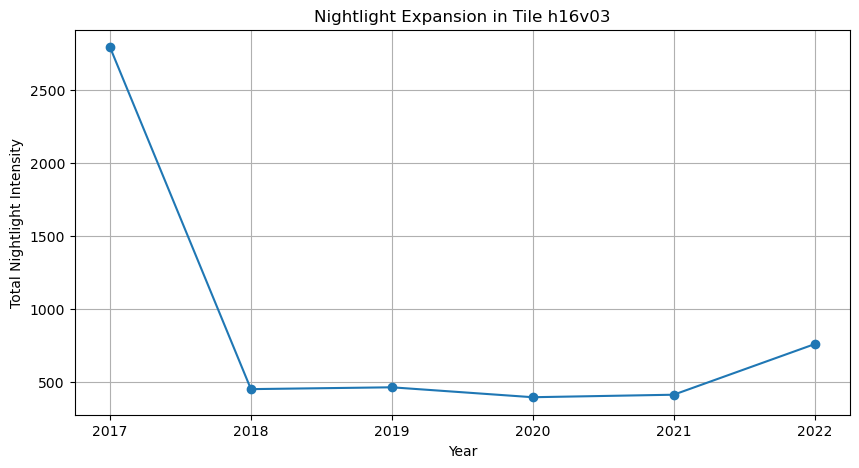

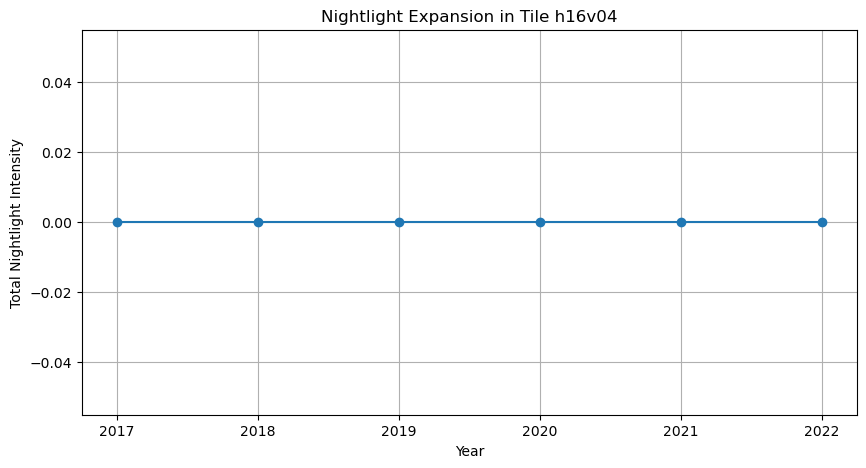

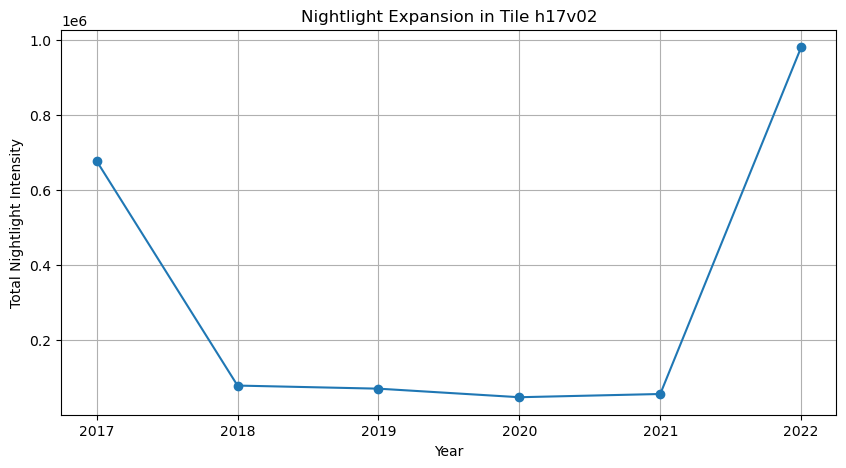

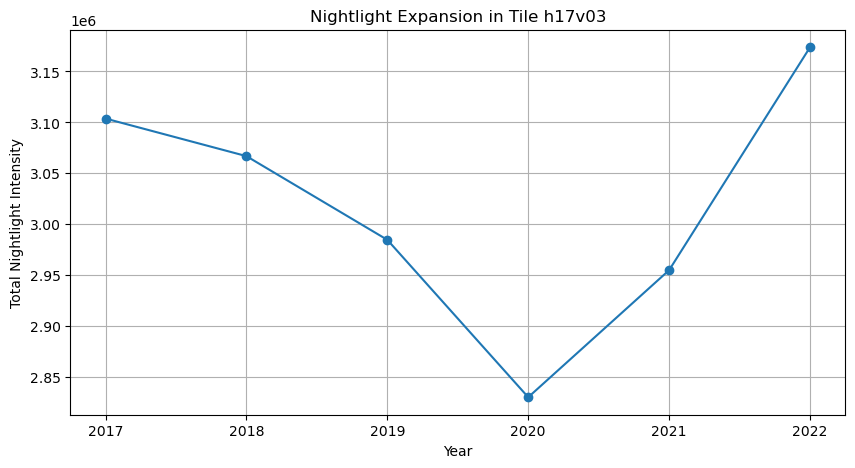

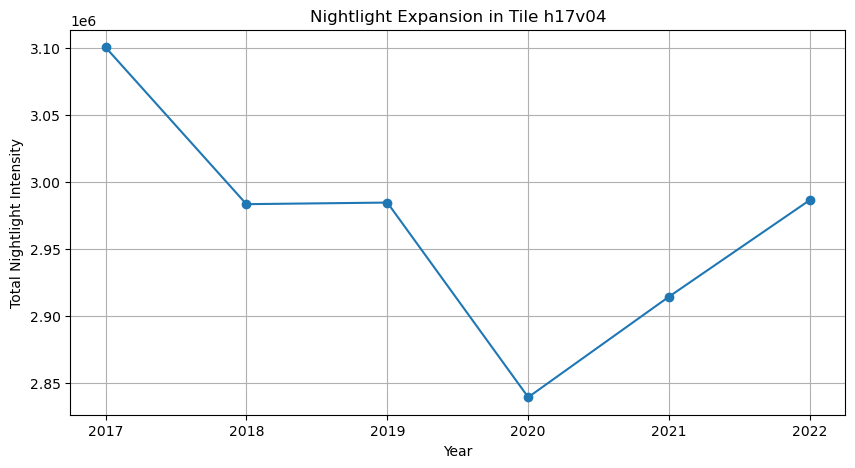

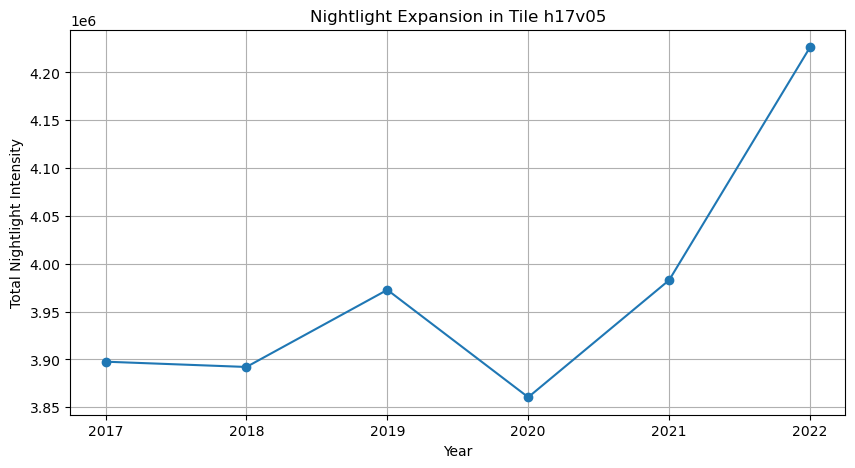

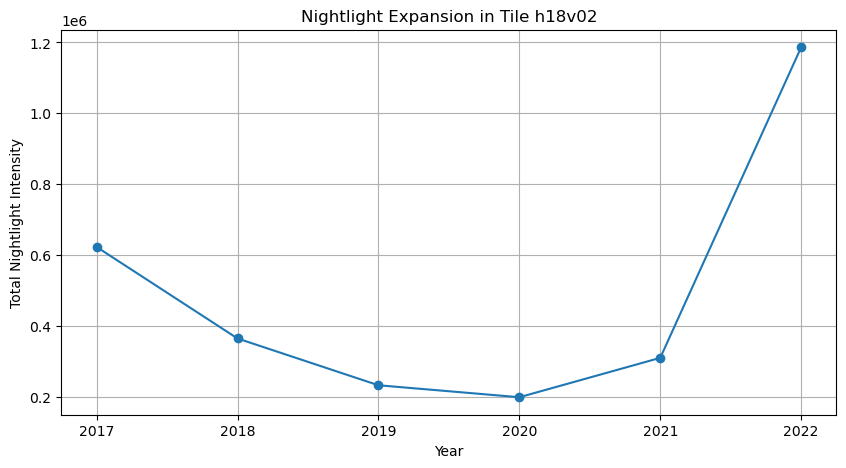

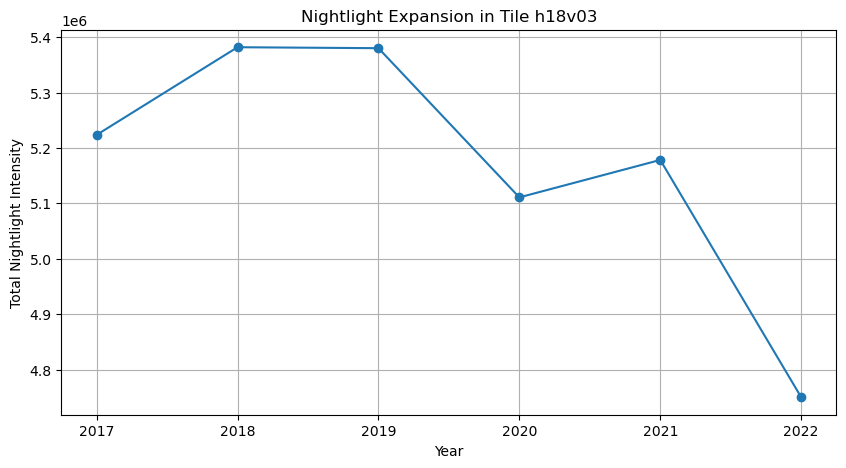

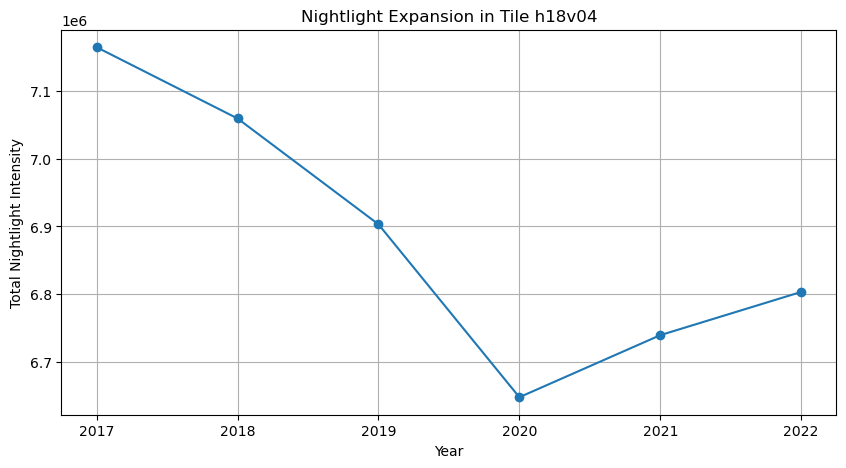

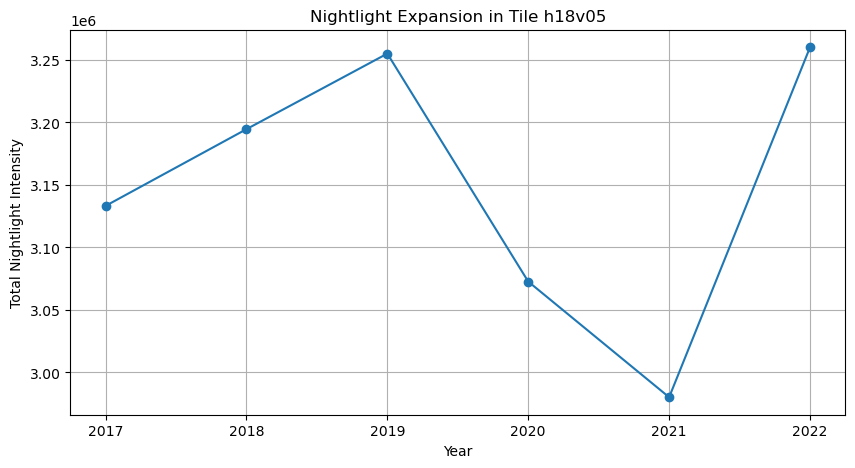

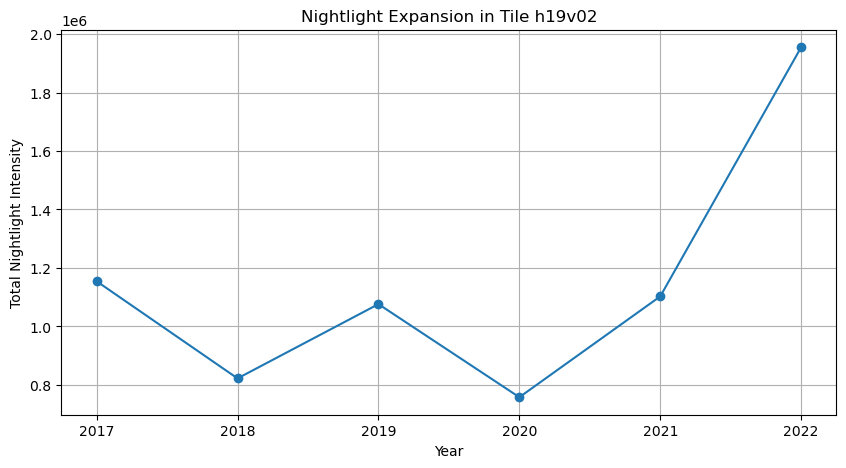

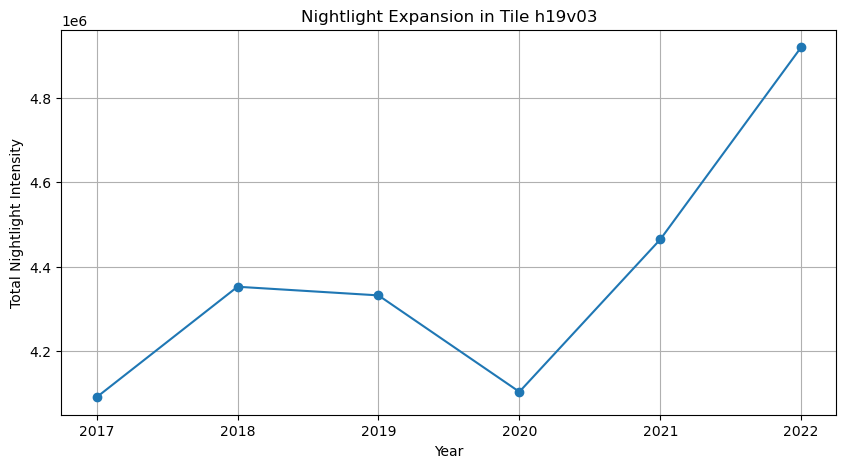

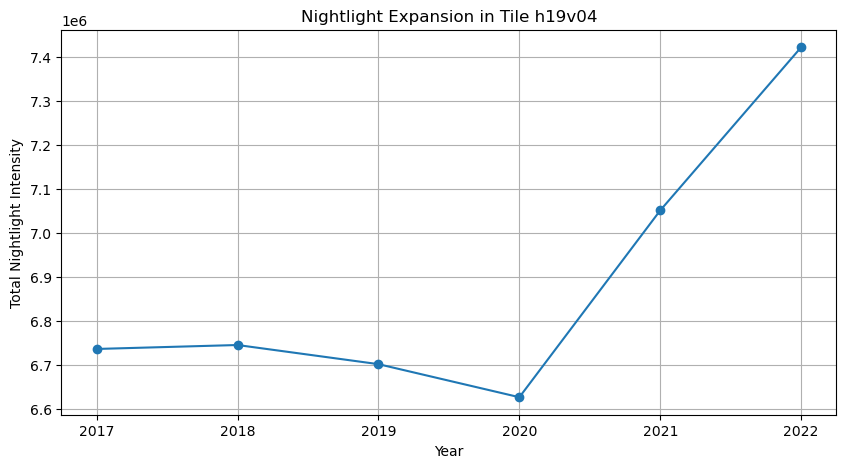

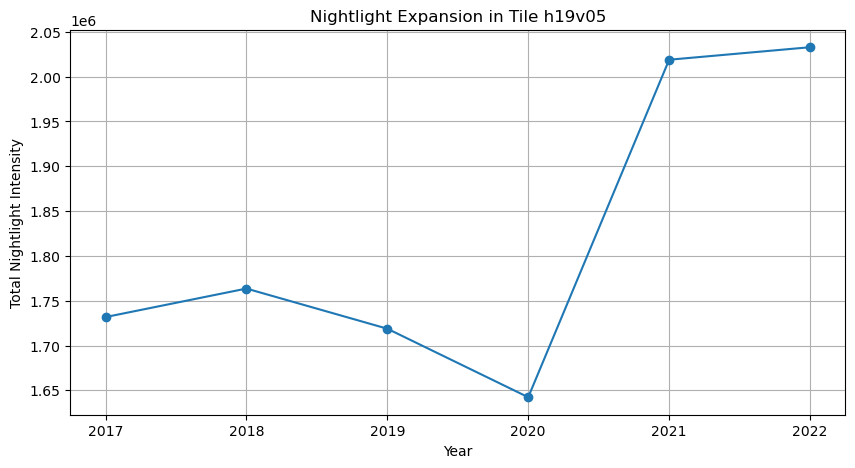

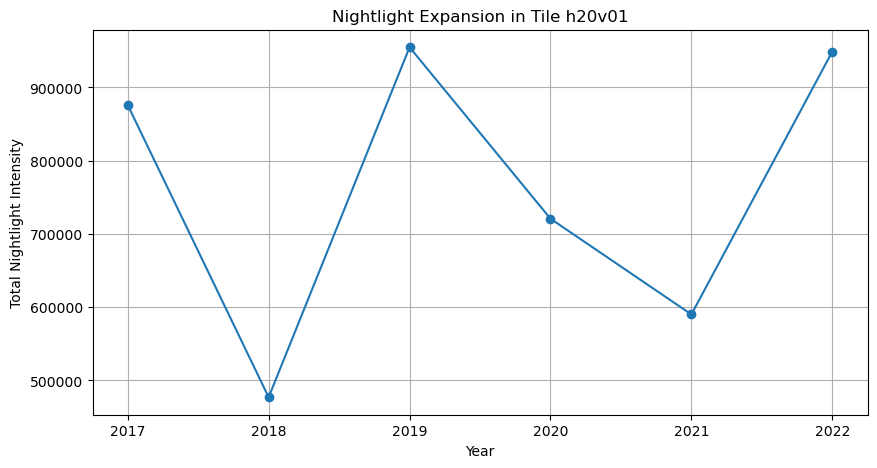

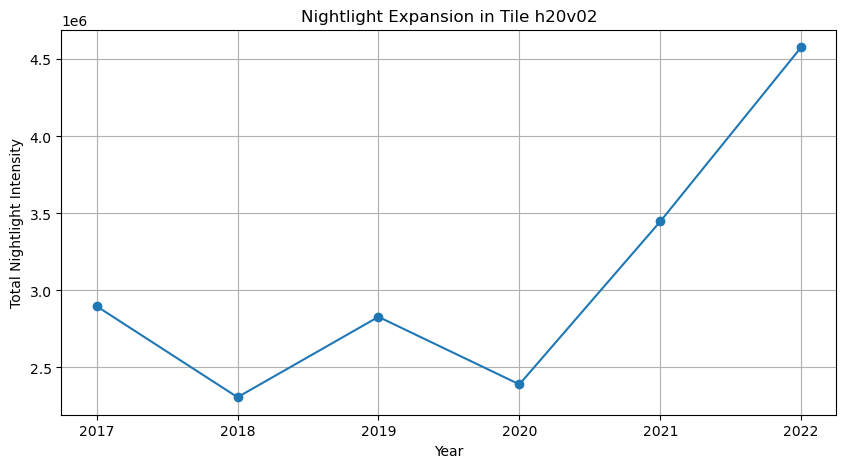

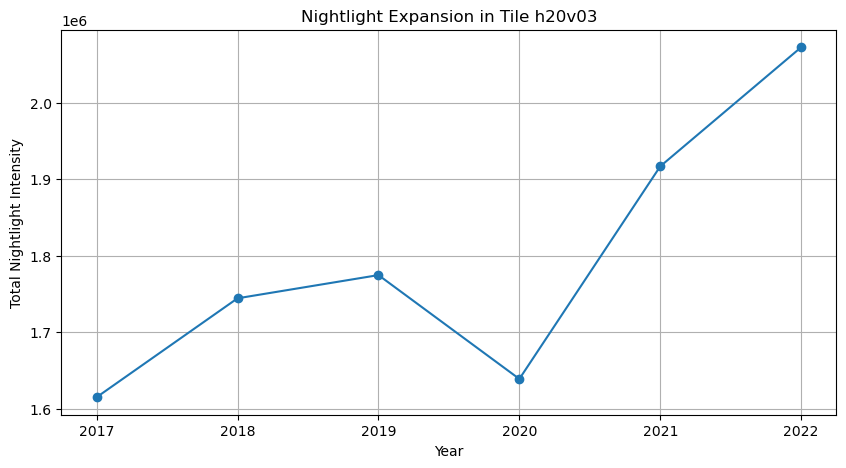

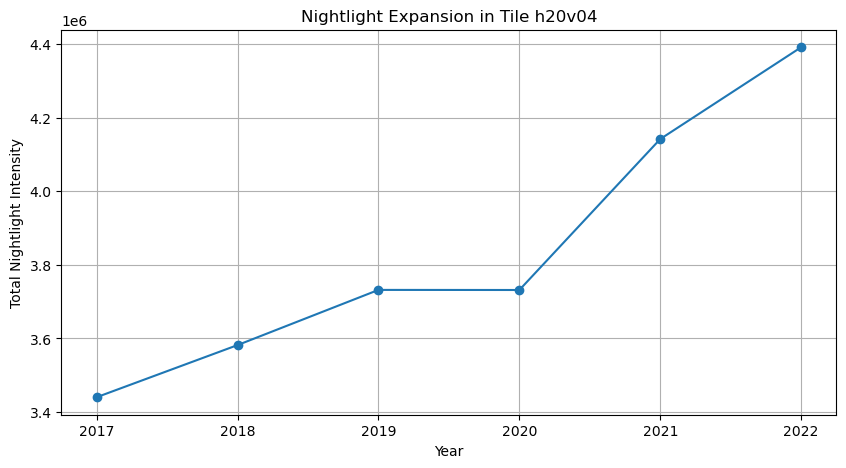

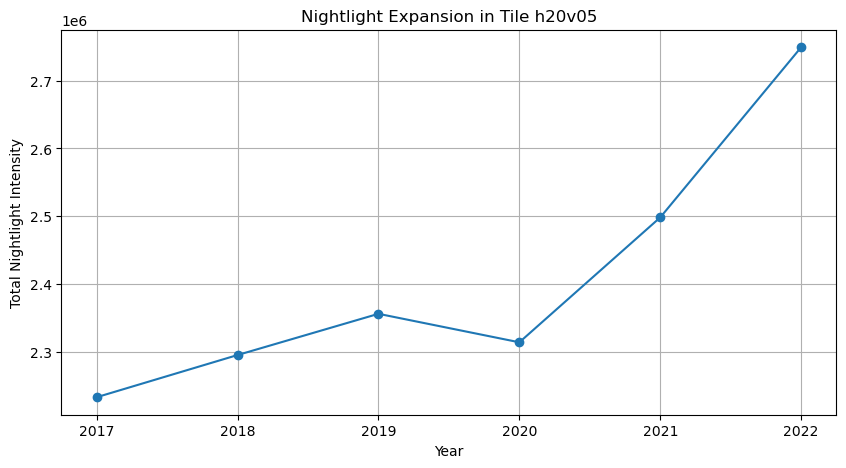

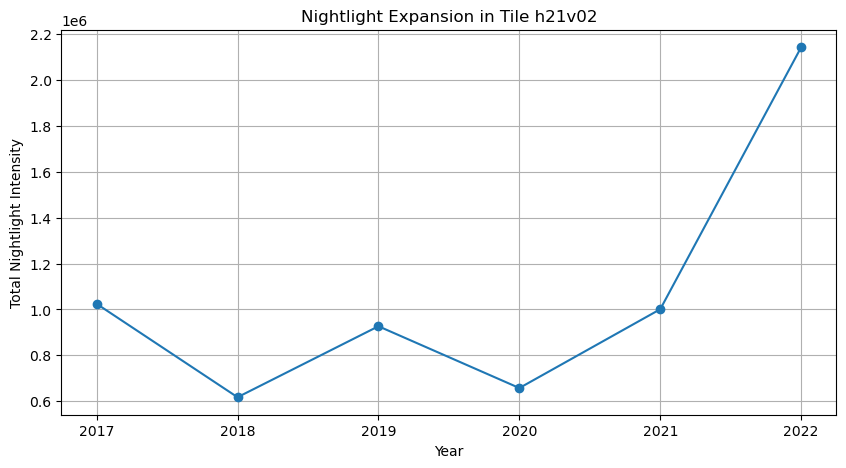

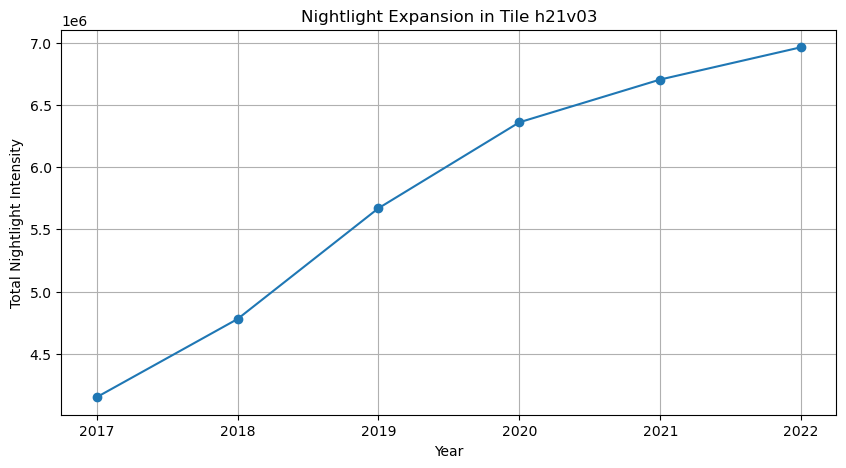

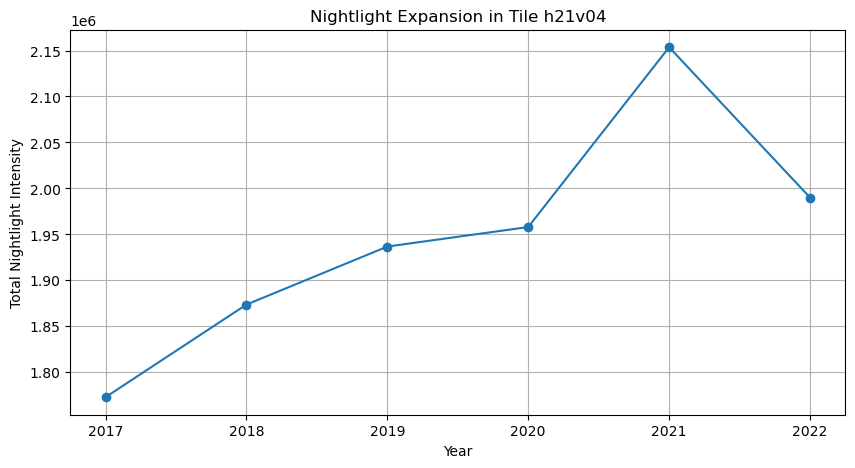

Tile h16v03: 6 files analyzed
Tile h16v04: 6 files analyzed
Tile h17v02: 6 files analyzed
Tile h17v03: 6 files analyzed
Tile h17v04: 6 files analyzed
Tile h17v05: 6 files analyzed
Tile h18v02: 6 files analyzed
Tile h18v03: 6 files analyzed
Tile h18v04: 6 files analyzed
Tile h18v05: 6 files analyzed
Tile h19v02: 6 files analyzed
Tile h19v03: 6 files analyzed
Tile h19v04: 6 files analyzed
Tile h19v05: 6 files analyzed
Tile h20v01: 6 files analyzed
Tile h20v02: 6 files analyzed
Tile h20v03: 6 files analyzed
Tile h20v04: 6 files analyzed
Tile h20v05: 6 files analyzed
Tile h21v02: 6 files analyzed
Tile h21v03: 6 files analyzed
Tile h21v04: 6 files analyzed


In [51]:
# get all HDF5 files in the folder
h5_files = sorted([f for f in os.listdir(folder_path_h5) if f.endswith(".h5")])

# identify all unique tiles from filenames
tiles = sorted({f.split(".")[2] for f in h5_files})

# store results
results = {tile: {"years": [], "ntl_sums": []} for tile in tiles}

# loop over files
for h5_file in h5_files:
    file_path = os.path.join(folder_path_h5, h5_file)
    
    # extract tile and year from filename
    tile = h5_file.split(".")[2]
    year = int(h5_file.split(".")[1][1:5])
    
    with h5py.File(file_path, 'r') as f:
        ds = f["HDFEOS/GRIDS/VIIRS_Grid_DNB_2d/Data Fields/AllAngle_Composite_Snow_Free"]
        ntl = ds[:].astype(float)
        scale = float(np.atleast_1d(ds.attrs.get('scale_factor', 1))[0])
        offset = float(np.atleast_1d(ds.attrs.get('add_offset', 0))[0])
        fill = ds.attrs.get('_FillValue')

        if fill is not None:
            fill = float(np.atleast_1d(fill)[0])
            ntl[np.isclose(ntl, fill)] = np.nan   
        ntl = ntl * scale + offset                
        
        # sum all valid nightlight values
        ntl_sum = np.nansum(ntl)
        
        # append to results for this tile
        results[tile]["years"].append(year)
        results[tile]["ntl_sums"].append(ntl_sum)

# create separate plots per tile
for tile, data in results.items():
    plt.figure(figsize=(10, 5))
    plt.plot(data["years"], data["ntl_sums"], marker='o')
    plt.xlabel("Year")
    plt.ylabel("Total Nightlight Intensity")
    plt.title(f"Nightlight Expansion in Tile {tile}")
    plt.grid(True)
    plt.show()  # display the plot
    plt.close()

for tile, data in results.items():
    print(f"Tile {tile}: {len(data['years'])} files analyzed")

#### Area coordinates

In [52]:
def tile_bounds(tile_hv):
    """
    returns approximate lat/lon bounds (degrees) for a MODIS tile
    """
    h = int(tile_hv[1:3])
    v = int(tile_hv[4:6])
    
    tile_size_km = 1200  # MODIS sinusoidal tile (1200 km)
    earth_radius_km = 6371
    km_per_deg_lat = 2 * np.pi * earth_radius_km / 360
    km_per_deg_lon = km_per_deg_lat  # approximation
    
    lon_min = -180 + h * tile_size_km / km_per_deg_lon
    lon_max = lon_min + tile_size_km / km_per_deg_lon
    lat_max = 90 - v * tile_size_km / km_per_deg_lat
    lat_min = lat_max - tile_size_km / km_per_deg_lat
    
    return lon_min, lon_max, lat_min, lat_max

# example
tiles = ["h18v04"]
for tile in tiles:
    lon_min, lon_max, lat_min, lat_max = tile_bounds(tile)
    print(f"Tile {tile} bounds:")
    print(f"Longitude: {lon_min:.2f} -> {lon_max:.2f}")
    print(f"Latitude: {lat_min:.2f} -> {lat_max:.2f}\n")

Tile h18v04 bounds:
Longitude: 14.25 -> 25.05
Latitude: 36.04 -> 46.83



#### Visualization

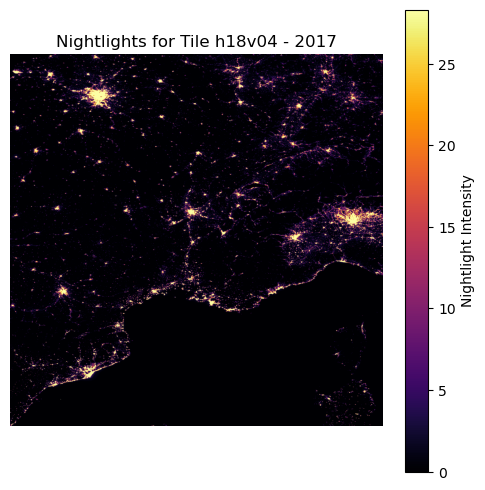

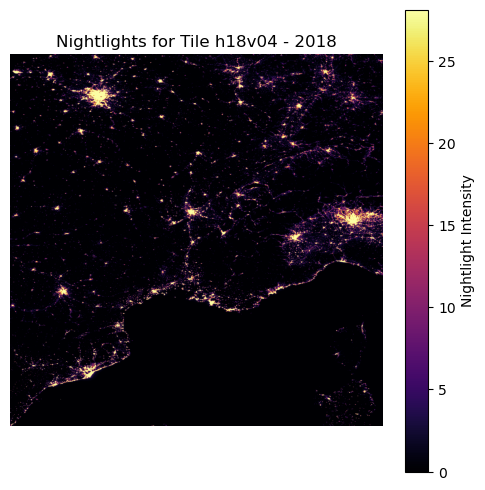

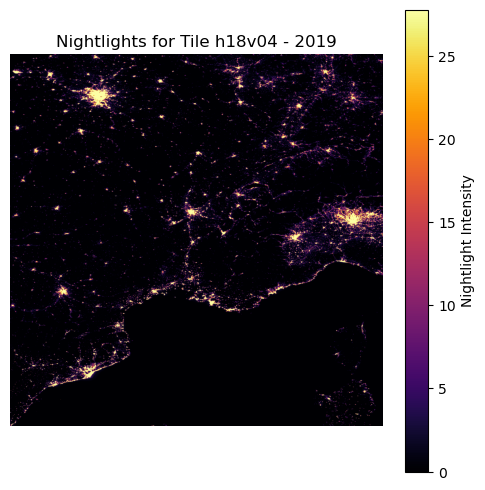

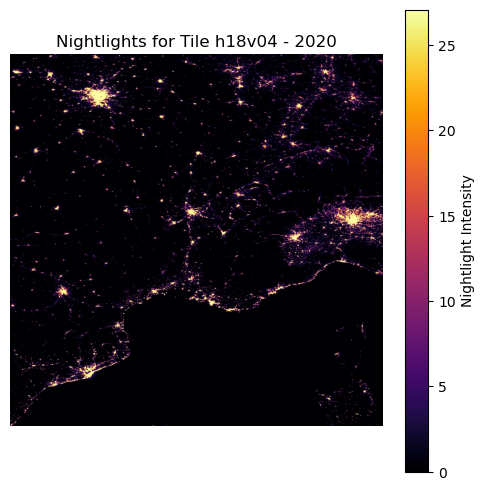

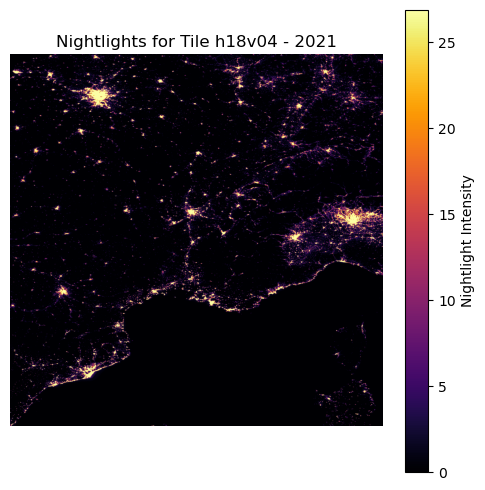

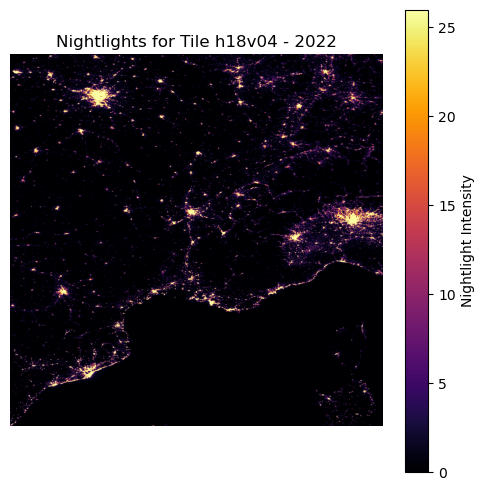

In [53]:
tile_code = "h18v04"

h5_files = sorted([f for f in os.listdir(folder_path_h5) if f.endswith(".h5") and tile_code in f])

for h5_file in h5_files:
    file_path = os.path.join(folder_path_h5, h5_file)
    year = int(h5_file.split(".")[1][1:5])
    
    with h5py.File(file_path, 'r') as f:
        ds = f["HDFEOS/GRIDS/VIIRS_Grid_DNB_2d/Data Fields/AllAngle_Composite_Snow_Free"]
        ntl = ds[:].astype(float)
        
        scale = ds.attrs.get('scale_factor', 1)
        offset = ds.attrs.get('add_offset', 0)
        fill = ds.attrs.get('_FillValue')
        
        ntl = ntl * scale + offset
        if fill is not None:
            ntl[ntl == fill] = np.nan
    
    vmax = np.nanpercentile(ntl, 99)  # 99th percentile
    vmin = np.nanmin(ntl)
    
    plt.figure(figsize=(6,6))
    plt.imshow(ntl, cmap='inferno', origin='upper', vmin=vmin, vmax=vmax)
    plt.colorbar(label='Nightlight Intensity')
    plt.title(f'Nightlights for Tile {tile_code} - {year}')
    plt.axis('off')
    plt.show()

#### Difference over years

Min diff: -5211.884902954102
Max diff: 1168.650405883789
Mean diff: -0.06275131239227841


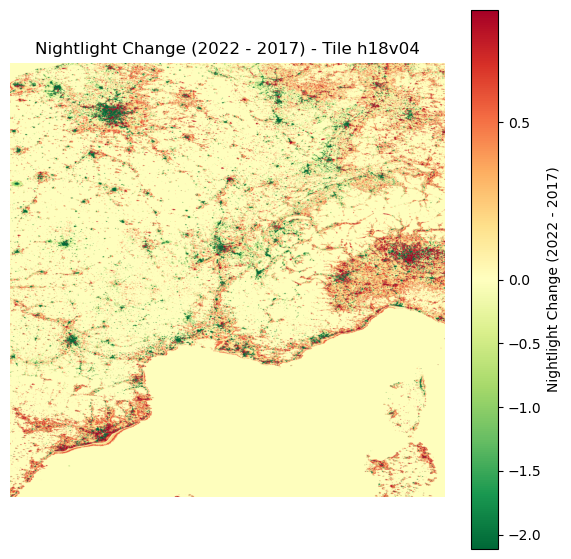

In [54]:
def load_year(year):
    # find file for specified year
    file = [f for f in os.listdir(folder_path_h5)
            if f.endswith(".h5") and tile_code in f and f"A{year}" in f][0]
    
    file_path = os.path.join(folder_path_h5, file)
    
    with h5py.File(file_path, 'r') as f:
        ds = f["HDFEOS/GRIDS/VIIRS_Grid_DNB_2d/Data Fields/AllAngle_Composite_Snow_Free"]
        ntl = ds[:].astype(float)
        
        scale = ds.attrs.get('scale_factor', 1)
        offset = ds.attrs.get('add_offset', 0)
        fill = ds.attrs.get('_FillValue')
        
        ntl = ntl * scale + offset
        if fill is not None:
            ntl[ntl == fill] = np.nan
    
    return ntl

# both years
ntl_2017 = load_year(2017)
ntl_2022 = load_year(2022)

# compute difference
diff = ntl_2022 - ntl_2017

print("Min diff:", np.nanmin(diff))
print("Max diff:", np.nanmax(diff))
print("Mean diff:", np.nanmean(diff))

# outliers
low = np.nanpercentile(diff, 2)
high = np.nanpercentile(diff, 98)

norm = TwoSlopeNorm(vmin=low, vcenter=0, vmax=high)

plt.figure(figsize=(7,7))
plt.imshow(diff, cmap='RdYlGn_r', norm=norm)
plt.colorbar(label='Nightlight Change (2022 - 2017)')
plt.title(f'Nightlight Change (2022 - 2017) - Tile {tile_code}')
plt.axis('off')
plt.show()

#### Example of tile with not cleaned image

Tile h18v02 bounds:
Longitude: 14.25 -> 25.05
Latitude: 57.62 -> 68.42



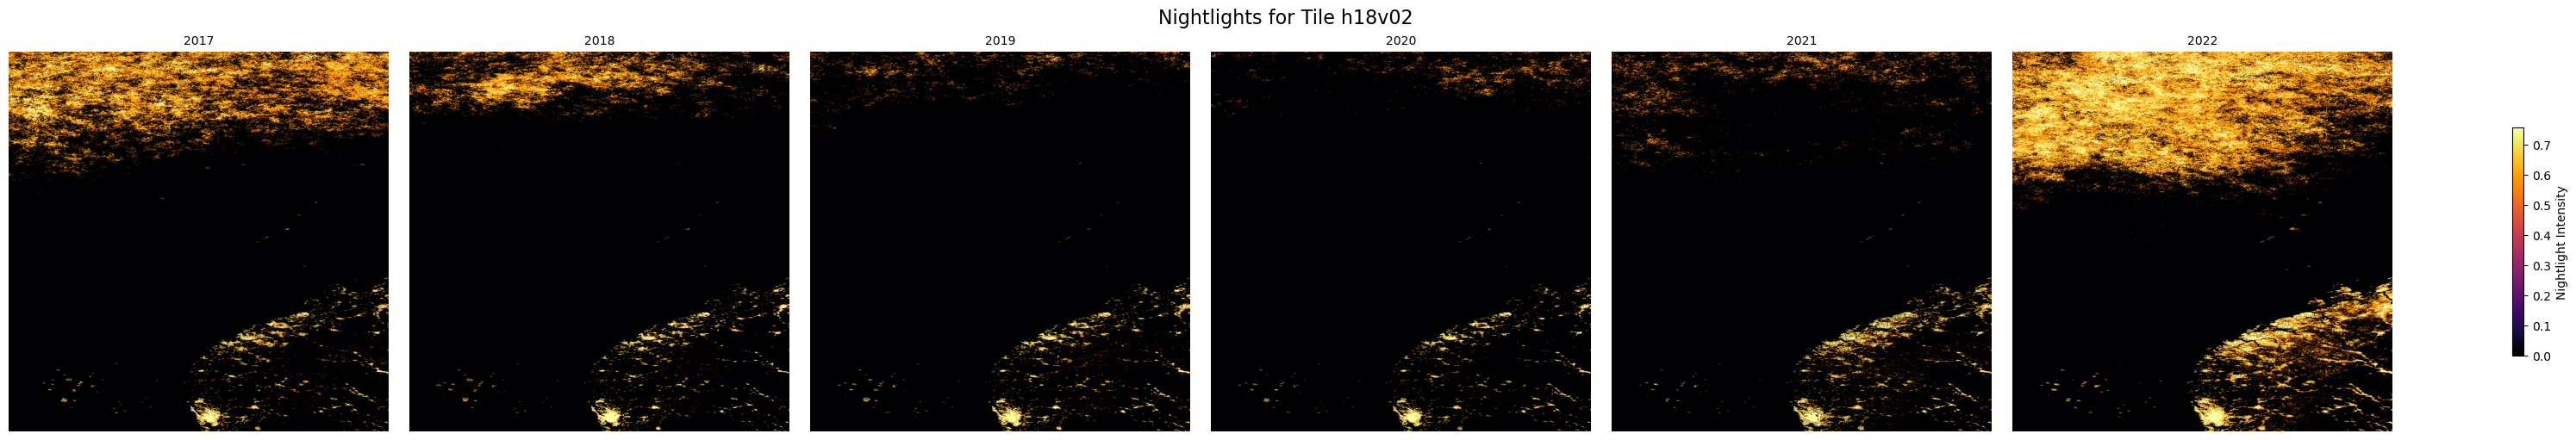

In [55]:
tiles = ["h18v02"]
for tile in tiles:
    lon_min, lon_max, lat_min, lat_max = tile_bounds(tile)
    print(f"Tile {tile} bounds:")
    print(f"Longitude: {lon_min:.2f} -> {lon_max:.2f}")
    print(f"Latitude: {lat_min:.2f} -> {lat_max:.2f}\n")
    
tile_code = "h18v02"

h5_files = sorted([f for f in os.listdir(folder_path_h5) 
                   if f.endswith(".h5") and tile_code in f])
n = len(h5_files)

# Automatic grid size
cols = 6
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 5*rows), constrained_layout=True)
axes = axes.flatten()

# Optional: compute a global vmax for all images for consistent color scale
all_ntl_values = []

for h5_file in h5_files:
    file_path = os.path.join(folder_path_h5, h5_file)
    with h5py.File(file_path, 'r') as f:
        ds = f["HDFEOS/GRIDS/VIIRS_Grid_DNB_2d/Data Fields/AllAngle_Composite_Snow_Free"]
        ntl = ds[:].astype(float)
        scale = ds.attrs.get('scale_factor', 1)
        offset = ds.attrs.get('add_offset', 0)
        fill = ds.attrs.get('_FillValue')
        ntl = ntl * scale + offset
        if fill is not None:
            ntl[ntl == fill] = np.nan
        all_ntl_values.append(ntl)

# Determine global color scale
all_ntl_concat = np.concatenate([arr.flatten() for arr in all_ntl_values])
vmin = np.nanpercentile(all_ntl_concat, 1)   # avoid extreme low outliers
vmax = np.nanpercentile(all_ntl_concat, 99)  # avoid extreme high outliers
norm = Normalize(vmin=vmin, vmax=vmax)

# Plot images
for i, ntl in enumerate(all_ntl_values):
    year = int(h5_files[i].split(".")[1][1:5])
    im = axes[i].imshow(ntl, cmap='inferno', origin='upper', norm=norm)
    axes[i].set_title(f'{year}', fontsize=10)
    axes[i].axis('off')

# Remove empty subplots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

# Shared colorbar
cbar = fig.colorbar(im, ax=axes.tolist(), shrink=0.6, label='Nightlight Intensity')

plt.suptitle(f'Nightlights for Tile {tile_code}', fontsize=16)
plt.show()

**Stray light contamination**

Sunlight scattering during:
- twilight
- low sun angles
- polar night transitions

Even though VNP46A4 applies correction, problems and residuals still remain

#### One method to clean the image

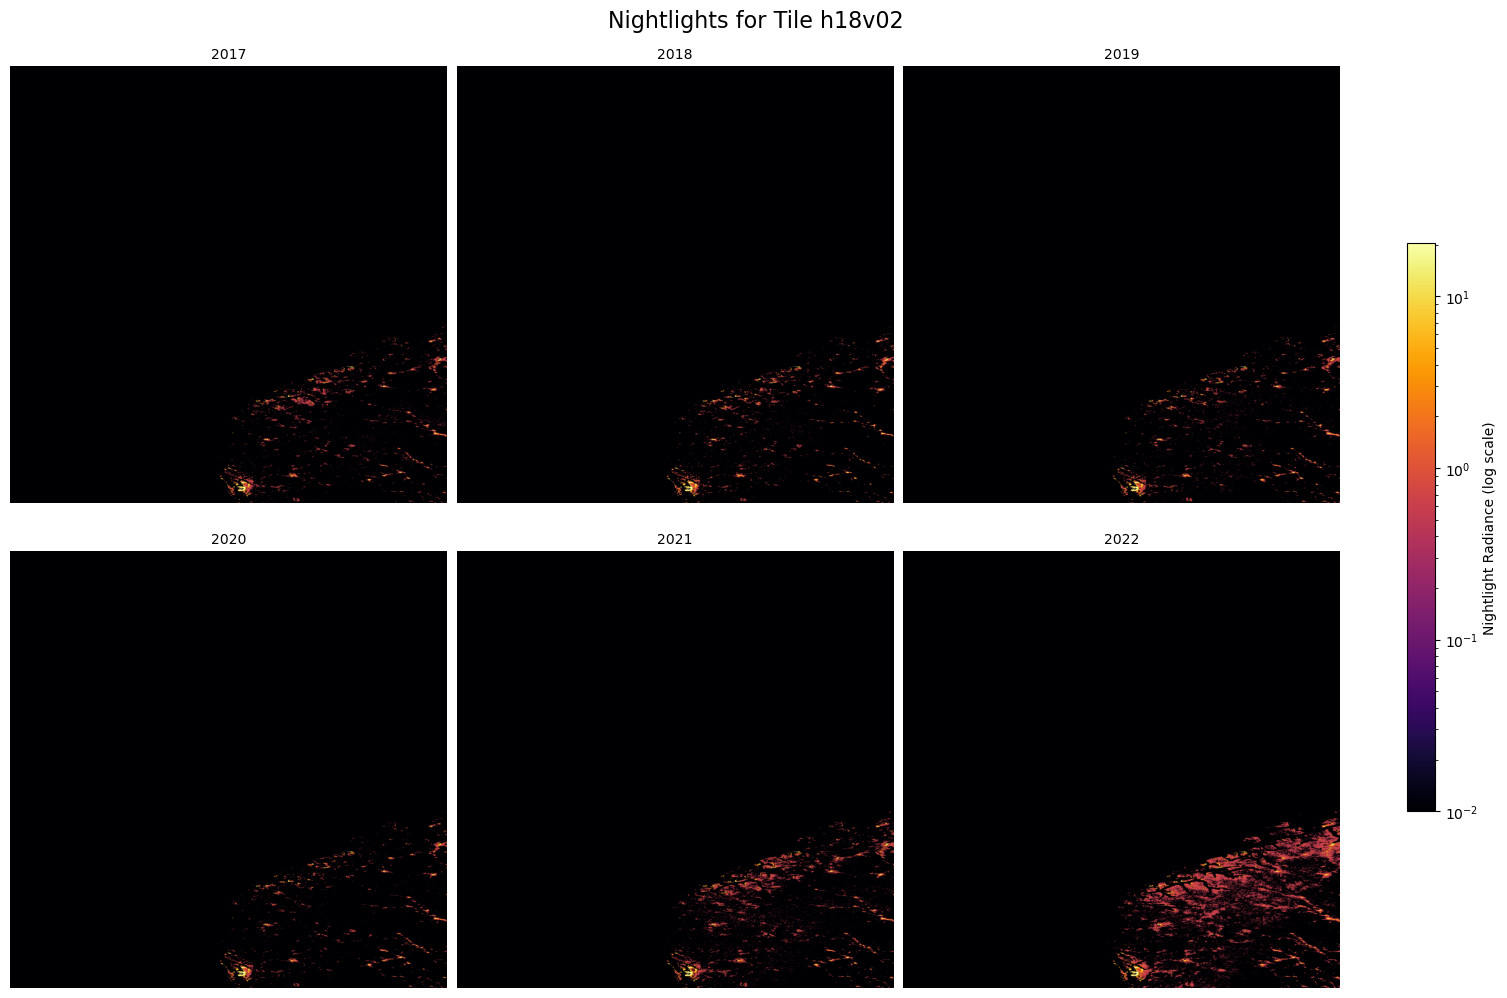

In [56]:
all_ntl_values_masked = []
all_valid_pixels = []

# loop through files
for h5_file in h5_files:
    file_path = os.path.join(folder_path_h5, h5_file)
    with h5py.File(file_path, 'r') as f:
        # load datasets
        ds_ntl = f["HDFEOS/GRIDS/VIIRS_Grid_DNB_2d/Data Fields/AllAngle_Composite_Snow_Free"]
        ds_num = f["HDFEOS/GRIDS/VIIRS_Grid_DNB_2d/Data Fields/AllAngle_Composite_Snow_Free_Num"]
        ds_lw = f["HDFEOS/GRIDS/VIIRS_Grid_DNB_2d/Data Fields/Land_Water_Mask"]

        ntl = ds_ntl[:].astype(float)
        num = ds_num[:].astype(float)
        lw = ds_lw[:]

        # apply scale, offset, and fill
        scale = ds_ntl.attrs.get('scale_factor', 1)
        offset = ds_ntl.attrs.get('add_offset', 0)
        fill = ds_ntl.attrs.get('_FillValue')

        ntl = ntl * scale + offset
        if fill is not None:
            ntl[ntl == fill] = np.nan

        # mask low observations and water
        ntl[num < 5] = np.nan
        ntl[lw != 1] = np.nan  # land = 1

        # remove zeros/negatives
        ntl[ntl <= 0] = np.nan

        # prepare masked version for log scale plotting
        ntl_masked = ntl.copy()
        ntl_masked[np.isnan(ntl_masked)] = 0.01  # avoid zeros
        ntl_masked[ntl_masked < 0.01] = 0.01

        all_ntl_values_masked.append(ntl_masked)
        all_valid_pixels.append(ntl.flatten())

# compute global log scale limits
all_concat = np.concatenate(all_valid_pixels)
all_concat = all_concat[~np.isnan(all_concat)]
vmin = 0.01
vmax = np.nanpercentile(all_concat, 99)
norm = LogNorm(vmin=vmin, vmax=vmax)

rows, cols = 2, int(np.ceil(len(h5_files)/2))  # adjust rows/cols
fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 5*rows), constrained_layout=True)
axes = axes.flatten()

for i, ntl in enumerate(all_ntl_values_masked):
    year = int(h5_files[i].split(".")[1][1:5])
    im = axes[i].imshow(ntl, cmap='inferno', origin='upper', norm=norm)
    axes[i].set_title(f'{year}', fontsize=10)
    axes[i].axis('off')

for j in range(i+1, len(axes)): # remove empty axes
    fig.delaxes(axes[j])

valid_axes = [ax for ax in axes if ax in fig.axes]
cbar = fig.colorbar(im, ax=valid_axes, shrink=0.6)
cbar.set_label("Nightlight Radiance (log scale)")

plt.suptitle(f'Nightlights for Tile {tile_code}', fontsize=16)
plt.show()

### Birds dataset

eBird is a citizen science platform run by the Cornell Lab of Ornithology. Observers submit checklists of bird sightings including species, count, location (lat/lon), and date. We downloaded species-level observation records for Europe (2017–2022) for a selection of native resident and migratory species.

**Native species:** permanent European residents (e.g. Great Tit, Robin, Great Spotted Woodpecker)  
**Migratory species:** species that seasonally move through Europe (e.g. Green Sandpiper)  

Raw files are tab-separated `.txt` files. We filter to European country codes, select relevant columns, replace `X` counts with `1`, and drop observations with more than 100 birds per entry (to remove flock outliers).

- eBird data requires free registration at https://ebird.org/data/download and cannot be redistributed directly. Pre-processed CSVs are available in the project repository.

#### More analysis in the **eBird data section**

#### Datasets overview

In [16]:
df_migra = pd.read_csv("migra_species_europe_only.csv")
df_native = pd.read_csv("native_species_europe_only.csv")

# add a column specifying migratory/native
df_migra['species_type'] = 'migratory'
df_native['species_type'] = 'native'

# both datasets should have the same columns
common_cols = list(set(df_migra.columns) & set(df_native.columns))
df_migra_aligned = df_migra[common_cols]
df_native_aligned = df_native[common_cols]

# concatenate the datasets
df_all = pd.concat([df_migra_aligned, df_native_aligned], ignore_index=True)

print(df_all.head())
print(df_all['species_type'].value_counts())
df_native['year'] = pd.to_datetime(df_native['OBSERVATION DATE']).dt.year
df_all['year'] = pd.to_datetime(df_all['OBSERVATION DATE']).dt.year
df_migra['year'] = pd.to_datetime(df_migra['OBSERVATION DATE']).dt.year

     SCIENTIFIC NAME species_type SAMPLING EVENT IDENTIFIER   LATITUDE  \
0  Numenius phaeopus    migratory                 S33804365  36.001314   
1  Numenius phaeopus    migratory                 S33940654  37.189895   
2  Numenius phaeopus    migratory                 S33751745  37.189895   
3  Numenius phaeopus    migratory                 S34018122  37.189895   
4  Numenius phaeopus    migratory                 S33908528  28.367192   

  COUNTRY CODE                                           LOCALITY  \
0           ES  Isla Tarifa.ES-Tarifa - 36.001x-5.611 - 20 Jan...   
1           ES            Marismas del Odiel PNat--Isla de Saltes   
2           ES            Marismas del Odiel PNat--Isla de Saltes   
3           ES            Marismas del Odiel PNat--Isla de Saltes   
4           ES                                 Salinas del Carmen   

  OBSERVATION TYPE OBSERVATION DATE  LONGITUDE  OBSERVATION COUNT  
0        Traveling       2017-01-20  -5.610797                2.0  
1   

#### Tiles boundaries

In [58]:
tiles = pd.read_csv("../nightlight_tile_year_bounds.csv")
print(tiles.tail())

print("-"*80)

df_nightlight_city = pd.read_csv("../nightlight_tile_year_bounds_with_urban_clusters.csv")
print(df_nightlight_city.tail())

       tile  year    lon_min    lon_max    lat_min    lat_max
127  h21v04  2018  46.629045  57.420904  36.040704  46.832563
128  h21v04  2019  46.629045  57.420904  36.040704  46.832563
129  h21v04  2020  46.629045  57.420904  36.040704  46.832563
130  h21v04  2021  46.629045  57.420904  36.040704  46.832563
131  h21v04  2022  46.629045  57.420904  36.040704  46.832563
--------------------------------------------------------------------------------
       tile  year    lon_min    lon_max    lat_min    lat_max  city_lat_1  \
127  h21v04  2018  46.629045  57.420904  36.040704  46.832563   36.860951   
128  h21v04  2019  46.629045  57.420904  36.040704  46.832563   36.861567   
129  h21v04  2020  46.629045  57.420904  36.040704  46.832563   45.156133   
130  h21v04  2021  46.629045  57.420904  36.040704  46.832563   45.156273   
131  h21v04  2022  46.629045  57.420904  36.040704  46.832563   36.860453   

     city_lon_1  city_lat_2  city_lon_2  city_lat_3  city_lon_3  city_lat_4  \
127  

#### Assign birds to tiles

In [59]:
df_native["tile"] = None

tiles = df_nightlight_city[["tile","year","lat_min","lat_max","lon_min","lon_max"]].drop_duplicates()

total = len(tiles)

for i, row in tiles.iterrows():

    tile = row["tile"]
    year = row["year"]

    lat_min = row["lat_min"]
    lat_max = row["lat_max"]
    lon_min = row["lon_min"]
    lon_max = row["lon_max"]

    mask = (
        (df_native["year"] == year) &
        (df_native["LATITUDE"] >= lat_min) &
        (df_native["LATITUDE"] <= lat_max) &
        (df_native["LONGITUDE"] >= lon_min) &
        (df_native["LONGITUDE"] <= lon_max)
    )

    df_native.loc[mask, "tile"] = tile

    print(f"Processed {i+1}/{total} tiles ({tile}, {year})")

Processed 1/132 tiles (h16v03, 2017)
Processed 2/132 tiles (h16v03, 2018)
Processed 3/132 tiles (h16v03, 2019)
Processed 4/132 tiles (h16v03, 2020)
Processed 5/132 tiles (h16v03, 2021)
Processed 6/132 tiles (h16v03, 2022)
Processed 7/132 tiles (h16v04, 2017)
Processed 8/132 tiles (h16v04, 2018)
Processed 9/132 tiles (h16v04, 2019)
Processed 10/132 tiles (h16v04, 2020)
Processed 11/132 tiles (h16v04, 2021)
Processed 12/132 tiles (h16v04, 2022)
Processed 13/132 tiles (h17v02, 2017)
Processed 14/132 tiles (h17v02, 2018)
Processed 15/132 tiles (h17v02, 2019)
Processed 16/132 tiles (h17v02, 2020)
Processed 17/132 tiles (h17v02, 2021)
Processed 18/132 tiles (h17v02, 2022)
Processed 19/132 tiles (h17v03, 2017)
Processed 20/132 tiles (h17v03, 2018)
Processed 21/132 tiles (h17v03, 2019)
Processed 22/132 tiles (h17v03, 2020)
Processed 23/132 tiles (h17v03, 2021)
Processed 24/132 tiles (h17v03, 2022)
Processed 25/132 tiles (h17v04, 2017)
Processed 26/132 tiles (h17v04, 2018)
Processed 27/132 tile

### European cities

To assign each bird observation to a city, we use a KD-Tree (via `scipy.spatial.cKDTree`). Coordinates are converted to radians before building the tree, and the returned angular distances are multiplied by Earth's radius (6371 km) to obtain approximate distances in kilometres.

- we use the 10m resolution NaturalEarth populated places dataset $\Rightarrow$ 1,148 cities across Europe

In [ ]:
# load European cities
url = "https://naturalearth.s3.amazonaws.com/10m_cultural/ne_10m_populated_places.zip"
world = gpd.read_file(url)
europe = world[world.geometry.x.between(-25, 45) & world.geometry.y.between(34, 72)]
cities = europe[['NAME', 'ADM0NAME', 'geometry']].copy()
cities['lon'] = cities.geometry.x
cities['lat'] = cities.geometry.y
cities = cities.drop(columns='geometry').reset_index(drop=True)


In [61]:
cities

,NAME,ADM0NAME,lon,lat
0,L'Ariana,Tunisia,10.199998,36.866673
1,Jendouba,Tunisia,8.749999,36.500004
2,Kasserine,Tunisia,8.716698,35.216703
3,Sdid Bouzid,Tunisia,9.500004,35.016696
4,Siliana,Tunisia,9.383302,36.083304
...,...,...,...,...
1143,London,United Kingdom,-0.118668,51.501941
1144,Istanbul,Turkey,28.974277,41.017602
1145,Moscow,Russia,37.613577,55.754110
1146,Rome,Italy,12.481313,41.897902


In [62]:
# build KD-Tree
cities_rad = np.radians(cities[['lat', 'lon']].values)
tree = cKDTree(cities_rad)

# find nearest city
birds_rad = np.radians(df_all[['LATITUDE', 'LONGITUDE']].values)
distances, indices = tree.query(birds_rad, k=1)

# results
df_all['closest_city'] = cities['NAME'].iloc[indices].values
df_all['closest_city_country'] = cities['ADM0NAME'].iloc[indices].values
df_all['distance_km'] = np.round(distances * 6371, 2)

df_all["city_lat"] = cities["lat"].iloc[indices].values
df_all["city_lon"] = cities["lon"].iloc[indices].values

df_all

,OBSERVATION COUNT,LATITUDE,LONGITUDE,OBSERVATION TYPE,COUNTRY CODE,LOCALITY,OBSERVATION DATE,SAMPLING EVENT IDENTIFIER,SCIENTIFIC NAME,species_type,year,closest_city,closest_city_country,distance_km,city_lat,city_lon
0,2.0,36.001314,-5.610797,Traveling,ES,Isla Tarifa.ES-Tarifa - 36.001x-5.611 - 20 Jan...,2017-01-20,S33804365,Numenius phaeopus,migratory,2017,Algeciras,Spain,22.80,36.131882,-5.452660
1,2.0,37.189895,-6.943853,Traveling,ES,Marismas del Odiel PNat--Isla de Saltes,2017-01-16,S33940654,Numenius phaeopus,migratory,2017,Huelva,Spain,6.90,37.250374,-6.929949
2,2.0,37.189895,-6.943853,Traveling,ES,Marismas del Odiel PNat--Isla de Saltes,2017-01-16,S33751745,Numenius phaeopus,migratory,2017,Huelva,Spain,6.90,37.250374,-6.929949
3,2.0,37.189895,-6.943853,Traveling,ES,Marismas del Odiel PNat--Isla de Saltes,2017-01-16,S34018122,Numenius phaeopus,migratory,2017,Huelva,Spain,6.90,37.250374,-6.929949
4,3.0,28.367192,-13.869656,Traveling,ES,Salinas del Carmen,2017-01-21,S33908528,Numenius phaeopus,migratory,2017,Rabat,Morocco,1003.72,34.025307,-6.836408
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995443,1.0,41.903587,12.450144,Stationary,VA,Gardens of Vatican City,2022-04-09,S106631527,Erithacus rubecula,native,2022,Vatican City,Vatican,0.36,41.903282,12.453387
4995444,1.0,41.903587,12.450144,Traveling,VA,Gardens of Vatican City,2022-05-05,S108980796,Erithacus rubecula,native,2022,Vatican City,Vatican,0.36,41.903282,12.453387
4995445,1.0,41.903587,12.450144,Incidental,VA,Gardens of Vatican City,2022-10-07,S120180143,Erithacus rubecula,native,2022,Vatican City,Vatican,0.36,41.903282,12.453387
4995446,1.0,41.903587,12.450144,Stationary,VA,Gardens of Vatican City,2022-12-12,S123861665,Erithacus rubecula,native,2022,Vatican City,Vatican,0.36,41.903282,12.453387


In [63]:
# assign results
birds_rad_n = np.radians(df_native[['LATITUDE', 'LONGITUDE']].values)
distances, indices = tree.query(birds_rad_n, k=1)
df_native['closest_city'] = cities['NAME'].iloc[indices].values
df_native['closest_city_country'] = cities['ADM0NAME'].iloc[indices].values
df_native['distance_km'] = np.round(distances * 6371, 2)

df_native["city_lat"] = cities["lat"].iloc[indices].values
df_native["city_lon"] = cities["lon"].iloc[indices].values

print(df_native.tail(5))

print("-"*80)

birds_rad_m = np.radians(df_migra[['LATITUDE', 'LONGITUDE']].values)
distances, indices = tree.query(birds_rad_m, k=1)
df_migra['closest_city'] = cities['NAME'].iloc[indices].values
df_migra['closest_city_country'] = cities['ADM0NAME'].iloc[indices].values
df_migra['distance_km'] = np.round(distances * 6371, 2)

df_migra["city_lat"] = cities["lat"].iloc[indices].values
df_migra["city_lon"] = cities["lon"].iloc[indices].values

print(df_migra.tail(5))

            SCIENTIFIC NAME  OBSERVATION COUNT COUNTRY CODE  \
4039471  Erithacus rubecula                1.0           VA   
4039472  Erithacus rubecula                1.0           VA   
4039473  Erithacus rubecula                1.0           VA   
4039474  Erithacus rubecula                1.0           VA   
4039475  Erithacus rubecula                1.0           VA   

                        LOCALITY   LATITUDE  LONGITUDE OBSERVATION DATE  \
4039471  Gardens of Vatican City  41.903587  12.450144       2022-04-09   
4039472  Gardens of Vatican City  41.903587  12.450144       2022-05-05   
4039473  Gardens of Vatican City  41.903587  12.450144       2022-10-07   
4039474  Gardens of Vatican City  41.903587  12.450144       2022-12-12   
4039475  Gardens of Vatican City  41.903587  12.450144       2022-12-12   

        SAMPLING EVENT IDENTIFIER OBSERVATION TYPE species_type  year    tile  \
4039471                S106631527       Stationary       native  2022  h17v04   
4039472 

In [64]:
print(df_all['distance_km'].describe()) 
print(f"\nMedian:  {df_all['distance_km'].median():.2f} km")
print(f"Skewness: {df_all['distance_km'].skew():.2f}")
print(f"% within 10km:  {(df_all['distance_km'] <= 10).mean()*100:.1f}%")
print(f"% within 50km:  {(df_all['distance_km'] <= 50).mean()*100:.1f}%")
print(f"% within 100km: {(df_all['distance_km'] <= 100).mean()*100:.1f}%")
df_all['is_remote'] = (df_all['distance_km'] > 100).astype(int)
df_native['is_remote'] = (df_native['distance_km'] > 100).astype(int)
df_migra['is_remote'] = (df_migra['distance_km'] > 100).astype(int)
df_all.to_csv("all_birds_city.csv", index=False)
df_native.to_csv("native_birds_city.csv", index=False)
df_migra.to_csv("migra_birds_city.csv", index=False)

count    4.995448e+06
mean     4.759190e+01
std      1.445540e+02
min      2.000000e-02
25%      1.435000e+01
50%      2.977000e+01
75%      5.057000e+01
max      2.460870e+03
Name: distance_km, dtype: float64

Median:  29.77 km
Skewness: 12.28
% within 10km:  16.3%
% within 50km:  74.2%
% within 100km: 95.4%


### Nightlights intensity calculation & analysis

For each unique city and each year, we decided to follow the following workflow:
- scan all available HDF5 files to find which tile covers the city's coordinates (using the embedded `lat`/`lon` arrays in each file, not the approximate tile bounds)
- apply fill value masking before scaling to avoid treating sentinel values as real radiance
- extract the mean radiance within a 20-pixel radius ( this means 10 km) circle centred on the city's pixel coordinates
- where a city falls on a tile boundary and appears in two adjacent tiles, we keep the maximum intensity value

Cities in tiles not downloaded (Cyprus, Iceland, Antalya) receive `NaN` intensity $\Rightarrow$ 3,653 rows out of 3.6 million (0.1%), which are dropped before modelling.

In [65]:
# for each unique city, find which tile it falls in (per year)
def assign_tile_to_cities(cities_df, boundaries_df):
    results = []
    
    for year, year_tiles in boundaries_df.groupby('year'):
        year_cities = cities_df.copy()
        year_cities['year'] = year
        
        merged = year_cities.merge(
            year_tiles[['tile', 'year', 'lon_min', 'lon_max', 'lat_min', 'lat_max']],
            on='year', how='left'
        )
        
        in_tile = (
            (merged['city_lon'] >= merged['lon_min']) &
            (merged['city_lon'] <= merged['lon_max']) &
            (merged['city_lat'] >= merged['lat_min']) &
            (merged['city_lat'] <= merged['lat_max'])
        )
        
        matched = merged[in_tile].drop_duplicates(subset='closest_city')
        results.append(matched[['closest_city', 'year', 'tile']])
    
    return pd.concat(results).reset_index(drop=True)

df_boundaries_night_lights = pd.read_csv("../nightlight_tile_year_bounds_with_urban_clusters.csv")
# get unique cities with their coordinates
unique_cities = df_native[['closest_city', 'city_lat', 'city_lon']].drop_duplicates()
print(f"Unique cities: {len(unique_cities)}")

city_tile_mapping = assign_tile_to_cities(unique_cities, df_boundaries_night_lights)
print(city_tile_mapping.head(10))
print(f"\nCities matched to a tile: {city_tile_mapping['closest_city'].nunique()}")

# change native, migratory or all
df_native_city = df_all.merge(          
    city_tile_mapping,
    on=['closest_city', 'year'],
    how='left'
)

print(f"\nTile coverage: {df_native_city['tile'].notna().mean()*100:.1f}%")
print(df_native_city[['closest_city', 'city_lat', 'city_lon', 'year', 'tile']].head(10))

city_tile_mapping = city_tile_mapping.merge(
    unique_cities[['closest_city', 'city_lat', 'city_lon']],
    on='closest_city',
    how='left'
)
city_tile_mapping
city_tile_mapping_copy = city_tile_mapping.copy()

Unique cities: 817
    closest_city  year    tile
0     Kremenchuk  2017  h19v03
1         Madrid  2017  h16v04
2         Zagreb  2017  h18v04
3         Dundee  2017  h16v03
4     Manchester  2017  h16v03
5            Ełk  2017  h18v03
6      Kemijärvi  2017  h19v02
7        Utrecht  2017  h17v03
8         Arnhem  2017  h17v03
9  San Sebastián  2017  h16v04

Cities matched to a tile: 759

Tile coverage: 78.2%
  closest_city   city_lat  city_lon  year    tile
0    Algeciras  36.131882 -5.452660  2017  h16v04
1       Huelva  37.250374 -6.929949  2017  h16v04
2       Huelva  37.250374 -6.929949  2017  h16v04
3       Huelva  37.250374 -6.929949  2017  h16v04
4        Rabat  34.025307 -6.836408  2017     NaN
5        Rabat  34.025307 -6.836408  2017     NaN
6         Cork  51.892838 -8.465110  2017     NaN
7         Faro  37.017080 -7.933273  2017     NaN
8         Faro  37.017080 -7.933273  2017     NaN
9         Faro  37.017080 -7.933273  2017     NaN


In [66]:
def tile_bounds(tile_code):
    """Convert VIIRS tile code to lat/lon bounds"""
    h = int(tile_code[1:3])
    v = int(tile_code[4:6])
    lon_min = h * 10 - 180
    lon_max = lon_min + 10
    lat_max = 90 - v * 10
    lat_min = lat_max - 10
    return lon_min, lon_max, lat_min, lat_max

def latlon_to_pixel(lat, lon, lon_min, lon_max, lat_min, lat_max, img_shape):
    """Convert lat/lon to pixel coordinates in the image"""
    rows, cols = img_shape
    col = int((lon - lon_min) / (lon_max - lon_min) * cols)
    row = int((lat_max - lat) / (lat_max - lat_min) * rows)
    return row, col

def extract_circle_intensity(ntl, center_row, center_col, radius_px):
    """Extract mean intensity within a circle of radius_px pixels"""
    rows, cols = ntl.shape
    rr, cc = np.ogrid[:rows, :cols]
    mask = (rr - center_row)**2 + (cc - center_col)**2 <= radius_px**2
    values = ntl[mask]
    values = values[~np.isnan(values)]
    if len(values) == 0:
        return np.nan
    return np.mean(values)



radius_km = 20  # radius around each city in km
# 1 pixel = 10km/1000px per tile = 0.01 degrees, approx 1km per pixel and we adjusted radius_px based on your image resolution
radius_px = 20  # 10 pixels = 10km

# unique cities for the corresponding tile
# we need city_tile_mapping with closest_city, city_lat, city_lon, tile, year
city_results = []

for (tile_code, year), group in city_tile_mapping.groupby(['tile', 'year']):
    
    # find the h5 file for this tile and year
    h5_files = [f for f in os.listdir(folder_path_h5) 
                if f.endswith(".h5") and tile_code in f and f".A{year}" in f]
    
    if not h5_files:
        print(f"No file found for tile {tile_code}, year {year}")
        continue
    
    file_path = os.path.join(folder_path_h5, h5_files[0])
    lon_min, lon_max, lat_min, lat_max = tile_bounds(tile_code)
    
    # load again nightlight image
    with h5py.File(file_path, 'r') as f:
        ds = f["HDFEOS/GRIDS/VIIRS_Grid_DNB_2d/Data Fields/AllAngle_Composite_Snow_Free"]
        ntl = ds[:].astype(float)
        scale = ds.attrs.get('scale_factor', 1)
        offset = ds.attrs.get('add_offset', 0)
        fill = ds.attrs.get('_FillValue')
        ntl = ntl * scale + offset
        if fill is not None:
            ntl[ntl == fill * scale + offset] = np.nan
    
    # for each city in this tile/year group
    for _, row in group.iterrows():
        px_row, px_col = latlon_to_pixel(
            row['city_lat'], row['city_lon'],
            lon_min, lon_max, lat_min, lat_max,
            ntl.shape
        )
        
        # check pixel is within image bounds
        if 0 <= px_row < ntl.shape[0] and 0 <= px_col < ntl.shape[1]:
            intensity = extract_circle_intensity(ntl, px_row, px_col, radius_px)
        else:
            intensity = np.nan
        
        city_results.append({
            'closest_city': row['closest_city'],
            'year': year,
            'tile': tile_code,
            'city_lat': row['city_lat'],
            'city_lon': row['city_lon'],
            'ntl_intensity': intensity
        })
    
    print(f"Processed tile {tile_code}, year {year} — {len(group)} cities")

# dataframe
city_intensity_df = pd.DataFrame(city_results)
print(city_intensity_df.head(10))
print(f"\nNaN coverage: {city_intensity_df['ntl_intensity'].isna().mean()*100:.1f}%")

# check for duplicates in city_intensity_df
print(f"Rows in city_intensity_df: {len(city_intensity_df)}")
print(f"Unique city-year pairs: {city_intensity_df.groupby(['closest_city','year']).ngroups}")

# remove duplicates before merging
city_intensity_df = city_intensity_df.drop_duplicates(subset=['closest_city', 'year'])
print(f"After dedup: {len(city_intensity_df)}")

# merging again with df_native to get the ntl_intensity for each bird observation
df_native_city = df_native_city.merge(
    city_intensity_df[['closest_city', 'year', 'ntl_intensity']],
    on=['closest_city', 'year'],
    how='left'
)

print(f"Rows after merge: {len(df_native_city)}")
print(df_native_city[['closest_city', 'year', 'ntl_intensity']].head(10))

Processed tile h16v03, year 2017 — 83 cities
Processed tile h16v03, year 2018 — 83 cities
Processed tile h16v03, year 2019 — 83 cities
Processed tile h16v03, year 2020 — 83 cities
Processed tile h16v03, year 2021 — 83 cities
Processed tile h16v03, year 2022 — 83 cities
Processed tile h16v04, year 2017 — 57 cities
Processed tile h16v04, year 2018 — 57 cities
Processed tile h16v04, year 2019 — 57 cities
Processed tile h16v04, year 2020 — 57 cities
Processed tile h16v04, year 2021 — 57 cities
Processed tile h16v04, year 2022 — 57 cities
Processed tile h17v02, year 2017 — 31 cities
Processed tile h17v02, year 2018 — 31 cities
Processed tile h17v02, year 2019 — 31 cities
Processed tile h17v02, year 2020 — 31 cities
Processed tile h17v02, year 2021 — 31 cities
Processed tile h17v02, year 2022 — 31 cities
Processed tile h17v03, year 2017 — 136 cities
Processed tile h17v03, year 2018 — 136 cities
Processed tile h17v03, year 2019 — 136 cities
Processed tile h17v03, year 2020 — 136 cities
Proces

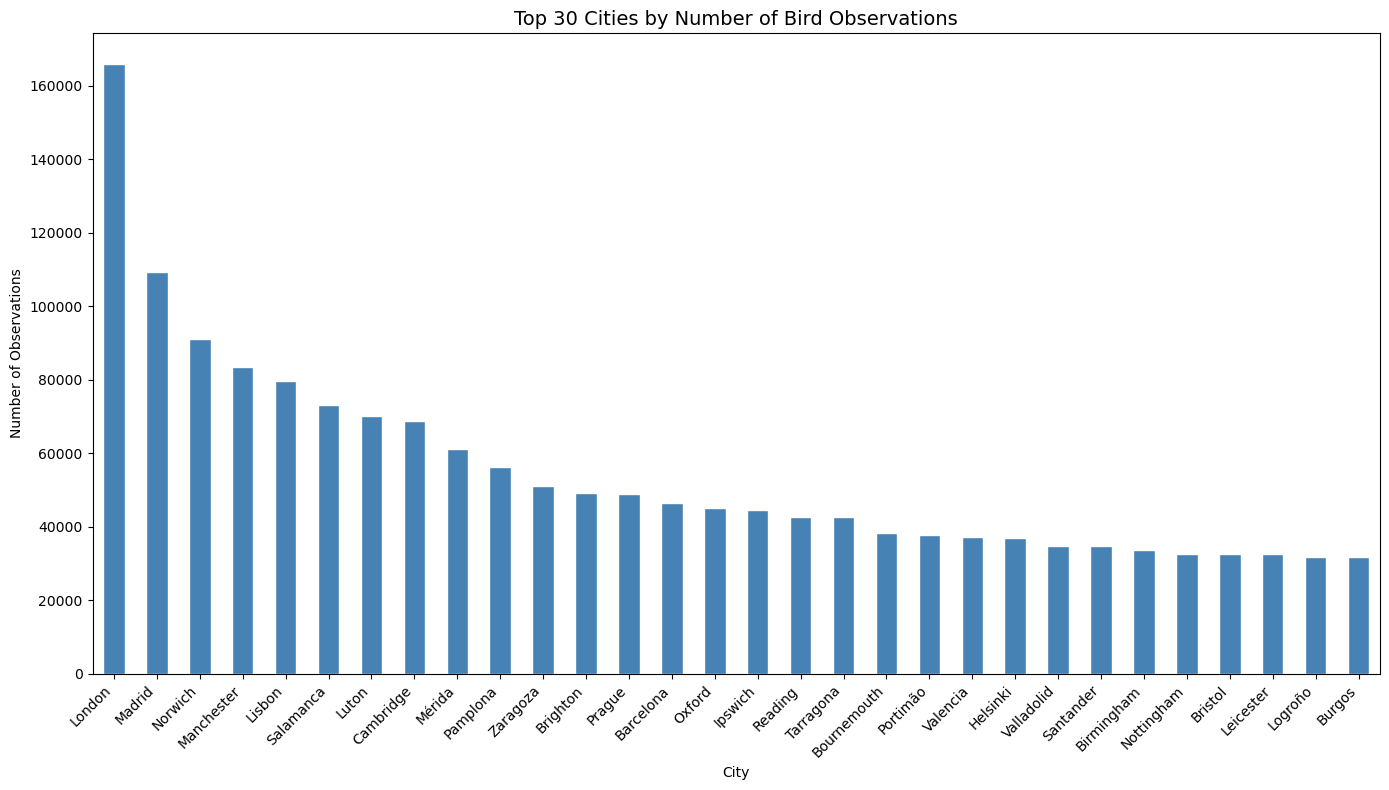

In [67]:
# top 30 cities by observation count
top30 = df_native_city['closest_city'].value_counts().head(30)
# plot
fig, ax = plt.subplots(figsize=(14, 8))
top30.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Top 30 Cities by Number of Bird Observations', fontsize=14)
ax.set_xlabel('City')
ax.set_ylabel('Number of Observations')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [68]:
print("Cities lat range:", unique_cities['city_lat'].min(), unique_cities['city_lat'].max())
print("Cities lon range:", unique_cities['city_lon'].min(), unique_cities['city_lon'].max())
print()
print("Tiles lat range:", df_boundaries_night_lights['lat_min'].min(), df_boundaries_night_lights['lat_max'].max())
print("Tiles lon range:", df_boundaries_night_lights['lon_min'].min(), df_boundaries_night_lights['lon_max'].max())
print("Bird years:", df_native_city['year'].unique())
print("Tile years:", df_boundaries_night_lights['year'].unique())

Cities lat range: 34.0253073 70.6612799
Cities lon range: -22.5665918 38.4273596

Tiles lat range: 25.2488443738514 79.20814072897524
Tiles lon range: -7.330251663603747 57.42090396254487
Bird years: [2017 2018 2019 2020 2021 2022 1995 1993 1988 1985 1996 1991 1990 1998
 1997 1974 1994 1978 1983 1971 1981 1992 1984 1982 1966 1987 1999 1972
 1986 1961 1989 1967 1979 1970 1977 1975 1968 1969 1958 1973 1980 1965
 1976 1962 1964 1963 1947 1957 1960 1954 1952 1953 1934 1955 1948 1903
 1935 1959 1941 1956 1950 1937 1938 1951 1946 1940 2000 2001 2002 2003
 2004 2005 2006 2007 2008 2009 2010 2011 2012 2013 2014 2015 2016 2023
 2024 2025 2026]
Tile years: [2017 2018 2019 2020 2021 2022]


In [69]:
# rebuild unique cities from the full birds dataset
unique_cities_list = df_native[['closest_city', 'city_lat', 'city_lon']]\
    .drop_duplicates(subset='closest_city')\
    .reset_index(drop=True)

print(f"Unique cities: {len(unique_cities_list)}")

# get all HDF5 files grouped by year
all_h5_files = sorted([f for f in os.listdir(folder_path_h5) if f.endswith(".h5")])

files_by_year = defaultdict(list)
for f in all_h5_files:
    year = int(f.split(".")[1][1:5])
    files_by_year[year].append(f)

print(f"Years available: {sorted(files_by_year.keys())}")

city_results = []

for year, year_files in sorted(files_by_year.items()):
    print(f"Processing year {year}...")
    
    for h5_file in year_files:
        file_path = os.path.join(folder_path_h5, h5_file)
        
        with h5py.File(file_path, 'r') as f:
            lats = f["HDFEOS/GRIDS/VIIRS_Grid_DNB_2d/Data Fields/lat"][:]
            lons = f["HDFEOS/GRIDS/VIIRS_Grid_DNB_2d/Data Fields/lon"][:]
            
            cities_in_file = unique_cities_list[
                (unique_cities_list['city_lon'] >= lons.min() - 0.01) &
                (unique_cities_list['city_lon'] <= lons.max() + 0.01) &
                (unique_cities_list['city_lat'] >= lats.min() - 0.01) &
                (unique_cities_list['city_lat'] <= lats.max() + 0.01)
            ]
            
            if len(cities_in_file) == 0:
                continue
            
            ds = f["HDFEOS/GRIDS/VIIRS_Grid_DNB_2d/Data Fields/AllAngle_Composite_Snow_Free"]
            ntl = ds[:].astype(float)
            scale = float(np.atleast_1d(ds.attrs.get('scale_factor', 1))[0])
            offset = float(np.atleast_1d(ds.attrs.get('add_offset', 0))[0])
            fill = float(np.atleast_1d(ds.attrs.get('_FillValue', -999.9))[0])
            ntl[np.isclose(ntl, fill)] = np.nan # mask fill values
            ntl = ntl * scale + offset # scale
        
        for _, city_row in cities_in_file.iterrows():
            lat_idx = int(np.clip(np.argmin(np.abs(lats - city_row['city_lat'])), 0, len(lats)-1))
            lon_idx = int(np.clip(np.argmin(np.abs(lons - city_row['city_lon'])), 0, len(lons)-1))
            intensity = extract_circle_intensity(ntl, lat_idx, lon_idx, radius_px)
            city_results.append({
                'closest_city': city_row['closest_city'],
                'year': year,
                'ntl_intensity': intensity
            })

# dataframe
city_intensity_df = pd.DataFrame(city_results)
# keep max intensity if a city appeared in two adjacent tiles
city_intensity_df = city_intensity_df.groupby(['closest_city', 'year'])['ntl_intensity'].max().reset_index()

print(f"Total city-year pairs: {len(city_intensity_df)}")
print(f"NaN: {city_intensity_df['ntl_intensity'].isna().mean()*100:.1f}%")

# map back to birds datasets
intensity_map = city_intensity_df.set_index(['closest_city', 'year'])['ntl_intensity'].to_dict()

for df, name in [(df_native, 'df_native'), (df_migra, 'df_migra'), (df_all, 'df_all')]:
    df['ntl_intensity'] = [
        intensity_map.get((city, year), np.nan)
        for city, year in zip(df['closest_city'], df['year'])
    ]
    print(f"{name} — NaN intensity: {df['ntl_intensity'].isna().mean()*100:.1f}%")

Unique cities: 816
Years available: [2017, 2018, 2019, 2020, 2021, 2022]
Processing year 2017...
Processing year 2018...
Processing year 2019...
Processing year 2020...
Processing year 2021...
Processing year 2022...
Total city-year pairs: 4806
NaN: 0.0%
df_native — NaN intensity: 10.0%
df_migra — NaN intensity: 28.9%
df_all — NaN intensity: 13.7%


In [70]:
# map back to birds dataset
intensity_map = city_intensity_df.set_index(['closest_city', 'year'])['ntl_intensity'].to_dict()

df_native_city['ntl_intensity'] = [
    intensity_map.get((city, year), np.nan)
    for city, year in zip(df_native_city['closest_city'], df_native_city['year'])
]

print(f"Rows: {len(df_native_city)}")
print(f"NaN intensity: {df_native_city['ntl_intensity'].isna().mean()*100:.1f}%")
print(df_native_city[['closest_city', 'year', 'ntl_intensity']].head(10))

# Quick sanity check
print("\nTop 10 brightest cities:")
print(city_intensity_df.groupby('closest_city')['ntl_intensity'].mean()
      .sort_values(ascending=False).head(10))

Rows: 4995448
NaN intensity: 13.7%
  closest_city  year  ntl_intensity
0    Algeciras  2017      22.134319
1       Huelva  2017      21.194133
2       Huelva  2017      21.194133
3       Huelva  2017      21.194133
4        Rabat  2017      34.112597
5        Rabat  2017      34.112597
6         Cork  2017      10.103357
7         Faro  2017       8.751531
8         Faro  2017       8.751531
9         Faro  2017       8.751531

Top 10 brightest cities:
closest_city
Athens       77.937740
Paris        76.056285
The Hague    71.922409
Piraeus      69.422812
Lisbon       66.264342
Barcelona    65.289153
London       65.028975
Brovary      63.616967
Madrid       63.335175
Warsaw       59.908612
Name: ntl_intensity, dtype: float64


In [71]:
# check what years are in the birds dataset vs what we extracted
print("Years in birds dataset:", sorted(df_native_city['year'].unique()))
print("Years in city_intensity_df:", sorted(city_intensity_df['year'].unique()))

# check London specifically (since there were some problems with some cities at the limit of the tile)
print("\nLondon in city_intensity_df:")
print(city_intensity_df[city_intensity_df['closest_city'] == 'London'])

print("\nLondon in birds dataset (year counts):")
print(df_native_city[df_native_city['closest_city'] == 'London']['year'].value_counts().sort_index())

print("\nLondon ntl_intensity values:")
print(df_native_city[df_native_city['closest_city'] == 'London']['ntl_intensity'].value_counts(dropna=False))

Years in birds dataset: [np.int32(1903), np.int32(1934), np.int32(1935), np.int32(1937), np.int32(1938), np.int32(1940), np.int32(1941), np.int32(1946), np.int32(1947), np.int32(1948), np.int32(1950), np.int32(1951), np.int32(1952), np.int32(1953), np.int32(1954), np.int32(1955), np.int32(1956), np.int32(1957), np.int32(1958), np.int32(1959), np.int32(1960), np.int32(1961), np.int32(1962), np.int32(1963), np.int32(1964), np.int32(1965), np.int32(1966), np.int32(1967), np.int32(1968), np.int32(1969), np.int32(1970), np.int32(1971), np.int32(1972), np.int32(1973), np.int32(1974), np.int32(1975), np.int32(1976), np.int32(1977), np.int32(1978), np.int32(1979), np.int32(1980), np.int32(1981), np.int32(1982), np.int32(1983), np.int32(1984), np.int32(1985), np.int32(1986), np.int32(1987), np.int32(1988), np.int32(1989), np.int32(1990), np.int32(1991), np.int32(1992), np.int32(1993), np.int32(1994), np.int32(1995), np.int32(1996), np.int32(1997), np.int32(1998), np.int32(1999), np.int32(2000),

In [72]:
# check if all missing cities only have NaNs in years 2023-2026
missing_cities = df_native_city[df_native_city['ntl_intensity'].isna()]

print("NaN rows by year:")
print(missing_cities['year'].value_counts().sort_index())

# check if any city has NaNs in 2017-2022
nan_2017_2022 = df_native_city[
    (df_native_city['ntl_intensity'].isna()) & 
    (df_native_city['year'].between(2017, 2022))
]['closest_city'].unique()

print(f"\nCities with NaN in 2017-2022: {len(nan_2017_2022)}")
print(nan_2017_2022[:20])

NaN rows by year:
year
1903         2
1934         2
1935         5
1937         1
1938         1
         ...  
2022      3530
2023    165164
2024    183939
2025    221924
2026     18875
Name: count, Length: 87, dtype: int64

Cities with NaN in 2017-2022: 17
['Famagusta' 'Paphos' 'Keflavík' 'Akureyri' 'Selfoss' 'Reykjavík'
 'Ísafjörður' 'Egilsstaðir' 'Höfn' 'Borgarnes' 'Sauðárkrókur' 'Lemosos'
 'Larnaka' 'Nicosia' 'Kyrenia' 'Pukë' 'Antalya']


In [73]:
print(f"Final NaN summary:")
print(f"  2017-2022 NaNs (genuine gaps): {df_native_city[df_native_city['ntl_intensity'].isna() & df_native_city['year'].between(2017,2022)].shape[0]:,}")
print(f"  2023-2026 NaNs (no data): {df_native_city[df_native_city['ntl_intensity'].isna() & (df_native_city['year'] > 2022)].shape[0]:,}")
print(f"  Total rows with intensity (2017-2022): {df_native_city[df_native_city['year'].between(2017,2022) & df_native_city['ntl_intensity'].notna()].shape[0]:,}")

Final NaN summary:
  2017-2022 NaNs (genuine gaps): 14,887
  2023-2026 NaNs (no data): 589,902
  Total rows with intensity (2017-2022): 4,312,876


In [74]:
# filter to 2017-2022 only (drop years with no nightlight data)
df_clean = df_native_city[df_native_city['year'].between(2017, 2022)].copy()
print(f"After year filter: {len(df_clean):,} rows")

# drop columns not useful for analysis
df_clean = df_clean.drop(columns=[ 'LOCALITY'])

# drop the 3,653 rows with NaN ntl_intensity (Cyprus/Iceland/Antalya)
df_clean = df_clean.dropna(subset=['ntl_intensity'])
print(f"After dropping NaN intensity: {len(df_clean):,} rows")

# check OBSERVATION COUNT for weird values
print(f"\nOBSERVATION COUNT stats:")
print(df_clean['OBSERVATION COUNT'].describe())
print(f"Non-integer values: {(df_clean['OBSERVATION COUNT'] % 1 != 0)}")

After year filter: 4,327,763 rows
After dropping NaN intensity: 4,312,876 rows

OBSERVATION COUNT stats:
count    4.312876e+06
mean     5.792653e+00
std      2.967585e+02
min      1.000000e+00
25%      1.000000e+00
50%      2.000000e+00
75%      3.000000e+00
max      1.400000e+05
Name: OBSERVATION COUNT, dtype: float64
Non-integer values: 0          False
1          False
2          False
3          False
4          False
           ...  
4995443    False
4995444    False
4995445    False
4995446    False
4995447    False
Name: OBSERVATION COUNT, Length: 4312876, dtype: bool


In [75]:
# work only with the duplicates subset
dups = df_clean[df_clean.duplicated(keep=False)].copy()
print(f"Total duplicate rows: {len(dups)}")

# group by all columns except observation_count and also we will sum the counts
cols_to_group = [c for c in dups.columns if c != 'OBSERVATION COUNT']

dups_fixed = dups.groupby(cols_to_group, as_index=False)['OBSERVATION COUNT'].sum()
print(f"\nBefore: {len(dups)} rows")
print(f"After aggregation: {len(dups_fixed)} rows")
print(dups_fixed.head(10).to_string())

Total duplicate rows: 976

Before: 976 rows
After aggregation: 474 rows
    LATITUDE  LONGITUDE OBSERVATION TYPE COUNTRY CODE OBSERVATION DATE SAMPLING EVENT IDENTIFIER SCIENTIFIC NAME species_type  year closest_city closest_city_country  distance_km   city_lat  city_lon  is_remote    tile  ntl_intensity  OBSERVATION COUNT
0  36.586781  -6.245166       Stationary           ES       2020-11-10                 S76082838     Parus major       native  2020        Cádiz                Spain         8.26  36.524829 -6.286141          0  h16v04      13.626558                2.0
1  36.702342  -3.410335       Incidental           ES       2022-05-10                S109531143     Parus major       native  2022     Granada‎                Spain        54.99  37.164978 -3.585011          0  h16v04      22.724341                2.0
2  36.927619  -4.786369        Traveling           ES       2021-07-31                 S92571152     Parus major       native  2021       Málaga                Spain    

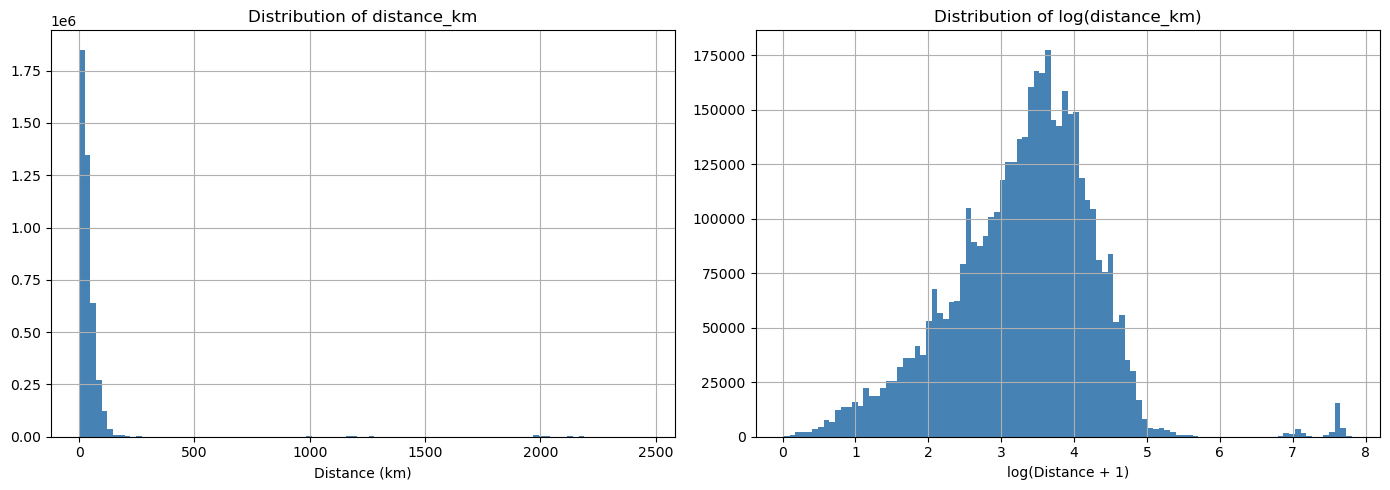

count    4.312876e+06
mean     4.831201e+01
std      1.535289e+02
min      2.000000e-02
25%      1.388000e+01
50%      2.920000e+01
75%      5.023000e+01
max      2.460870e+03
Name: distance_km, dtype: float64


In [76]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# distribution of distance_km
df_clean['distance_km'].hist(bins=100, ax=axes[0], color='steelblue')
axes[0].set_title('Distribution of distance_km')
axes[0].set_xlabel('Distance (km)')

# log distribution
np.log1p(df_clean['distance_km']).hist(bins=100, ax=axes[1], color='steelblue')
axes[1].set_title('Distribution of log(distance_km)')
axes[1].set_xlabel('log(Distance + 1)')

plt.tight_layout()
plt.show()

print(df_clean['distance_km'].describe())

In [77]:
# prepare data
df_model = df_clean.copy()

# target variable
df_model['log_distance'] = np.log1p(df_model['distance_km'])

# encode observation_type as dummies
obs_dummies = pd.get_dummies(df_model['OBSERVATION TYPE'], drop_first=True)
df_model['species_type_encoded'] = df_model['species_type'].map({'native': 0, 'migratory': 1})

# build feature matrix
X = pd.concat([
    df_model[['ntl_intensity', 'year', 'city_lat', 'OBSERVATION COUNT', 'species_type_encoded']],
    obs_dummies
], axis=1)

y = df_model['log_distance']

print(f"Features: {X.columns.tolist()}")
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

# train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# fit model
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# evaluate
y_pred = model.predict(X_test_scaled)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"\nR²: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")

# coefficients
coef_df = pd.DataFrame({
    'feature': X.columns,
    'coefficient': model.coef_
}).sort_values('coefficient', ascending=False)

print(f"\nCoefficients:")
print(coef_df.to_string())
print(f"\nIntercept: {model.intercept_:.4f}")

Features: ['ntl_intensity', 'year', 'city_lat', 'OBSERVATION COUNT', 'species_type_encoded', 'Banding', 'Historical', 'Incidental', 'Nocturnal Flight Call Count', 'Stationary', 'Traveling', 'eBird Pelagic Protocol']
X shape: (4312876, 12)
y shape: (4312876,)

R²: 0.0371
RMSE: 0.9584

Coefficients:
                        feature  coefficient
4          species_type_encoded     0.128243
5                       Banding     0.010278
3             OBSERVATION COUNT     0.004232
11       eBird Pelagic Protocol     0.001037
8   Nocturnal Flight Call Count    -0.006399
1                          year    -0.008988
6                    Historical    -0.019342
7                    Incidental    -0.033150
9                    Stationary    -0.036164
10                    Traveling    -0.062042
2                      city_lat    -0.084178
0                 ntl_intensity    -0.107769

Intercept: 3.2891


C:\Users\Radu\AppData\Local\Temp\ipykernel_17140\2095979547.py:18: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  corr_by_year = df_clean.groupby('year').apply(


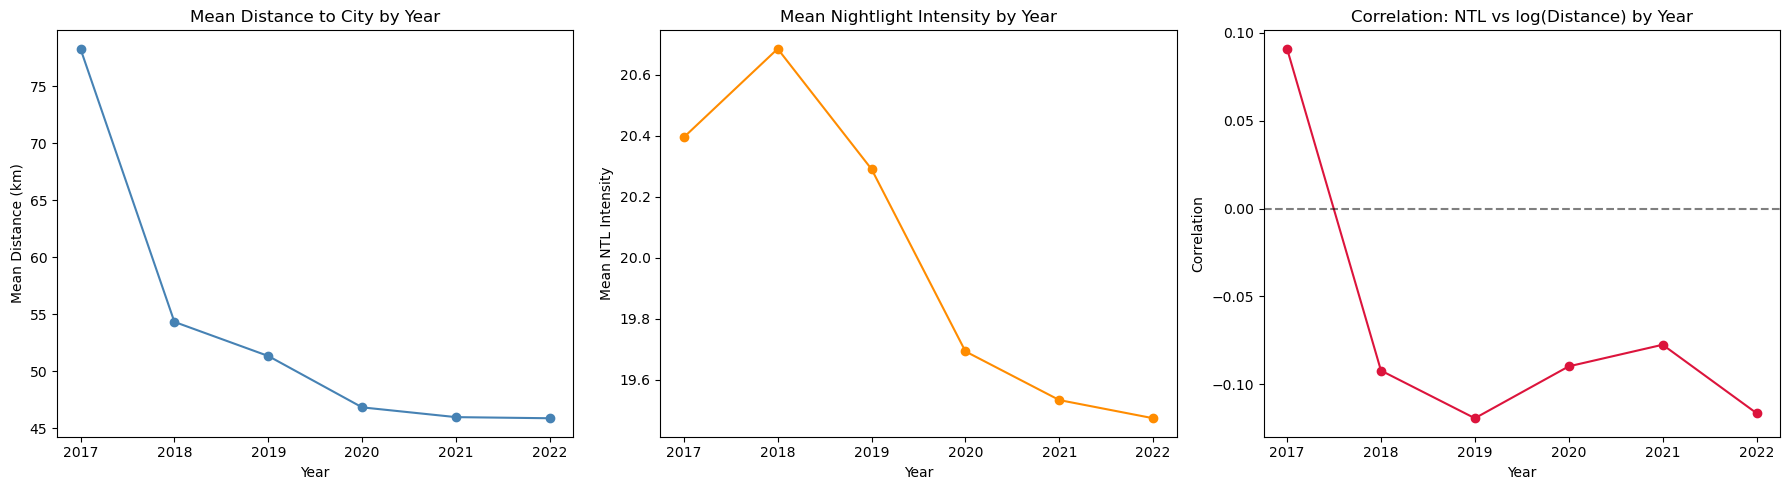

Mean distance by year:
year
2017    78.285924
2018    54.334845
2019    51.342417
2020    46.837341
2021    45.981114
2022    45.882864
Name: distance_km, dtype: float64

Mean NTL intensity by year:
year
2017    20.394375
2018    20.684586
2019    20.289916
2020    19.692273
2021    19.532717
2022    19.473115
Name: ntl_intensity, dtype: float64

Correlation NTL vs log(distance) by year:
year
2017    0.090943
2018   -0.092194
2019   -0.119328
2020   -0.089795
2021   -0.077492
2022   -0.116423
dtype: float64


In [78]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# mean distance by year
df_clean.groupby('year')['distance_km'].mean().plot(
    ax=axes[0], marker='o', color='steelblue')
axes[0].set_title('Mean Distance to City by Year')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Mean Distance (km)')

# mean ntl_intensity by year
df_clean.groupby('year')['ntl_intensity'].mean().plot(
    ax=axes[1], marker='o', color='darkorange')
axes[1].set_title('Mean Nightlight Intensity by Year')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Mean NTL Intensity')

# correlation between ntl_intensity and distance by year
corr_by_year = df_clean.groupby('year').apply(
    lambda x: x['ntl_intensity'].corr(np.log1p(x['distance_km']))
)
corr_by_year.plot(ax=axes[2], marker='o', color='crimson')
axes[2].set_title('Correlation: NTL vs log(Distance) by Year')
axes[2].set_xlabel('Year')
axes[2].set_ylabel('Correlation')
axes[2].axhline(y=0, color='black', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print("Mean distance by year:")
print(df_clean.groupby('year')['distance_km'].mean())
print("\nMean NTL intensity by year:")
print(df_clean.groupby('year')['ntl_intensity'].mean())
print("\nCorrelation NTL vs log(distance) by year:")
print(corr_by_year)

In [79]:
city_year = df_clean.groupby(['closest_city', 'year']).agg(
    mean_distance=('distance_km', 'mean'),
    log_distance=('distance_km', lambda x: np.log1p(x).mean()),
    ntl_intensity=('ntl_intensity', 'mean'),
    city_lat=('city_lat', 'first'),
    city_lon=('city_lon', 'first'),
    n_observations=('distance_km', 'count'),
    mean_obs_count=('OBSERVATION COUNT', 'mean')
).reset_index()

print(f"Shape: {city_year.shape}")
print(f"Rows per city: min={city_year.groupby('closest_city').size().min()}, max={city_year.groupby('closest_city').size().max()}")
print(city_year.head(10))

# correlation at aggregated level
corr = city_year[['mean_distance', 'log_distance', 'ntl_intensity', 
                   'city_lat', 'n_observations']].corr()
print(f"\nCorrelations with mean_distance:")
print(corr['mean_distance'].sort_values())

Shape: (4580, 9)
Rows per city: min=1, max=6
       closest_city  year  mean_distance  log_distance  ntl_intensity  \
0  's-Hertogenbosch  2017      25.291690      3.135284       8.795999   
1  's-Hertogenbosch  2018      23.304305      3.026567       8.955939   
2  's-Hertogenbosch  2019      26.561667      3.167688       9.067542   
3  's-Hertogenbosch  2020      28.777013      3.239358       9.109884   
4  's-Hertogenbosch  2021      28.581379      3.229800       9.275812   
5  's-Hertogenbosch  2022      30.028863      3.256967       9.358513   
6           Aalborg  2017      42.673889      3.735121       7.376499   
7           Aalborg  2018      39.548909      3.590691       7.671043   
8           Aalborg  2019      38.588571      3.593163       7.850015   
9           Aalborg  2020      36.784508      3.551059       8.107994   

    city_lat  city_lon  n_observations  mean_obs_count  
0  51.683337  5.316661              71        1.690141  
1  51.683337  5.316661             59

C:\Users\Radu\AppData\Local\Temp\ipykernel_17140\3247791122.py:70: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  city_trend = city_year.groupby('closest_city').apply(lambda x: pd.Series({


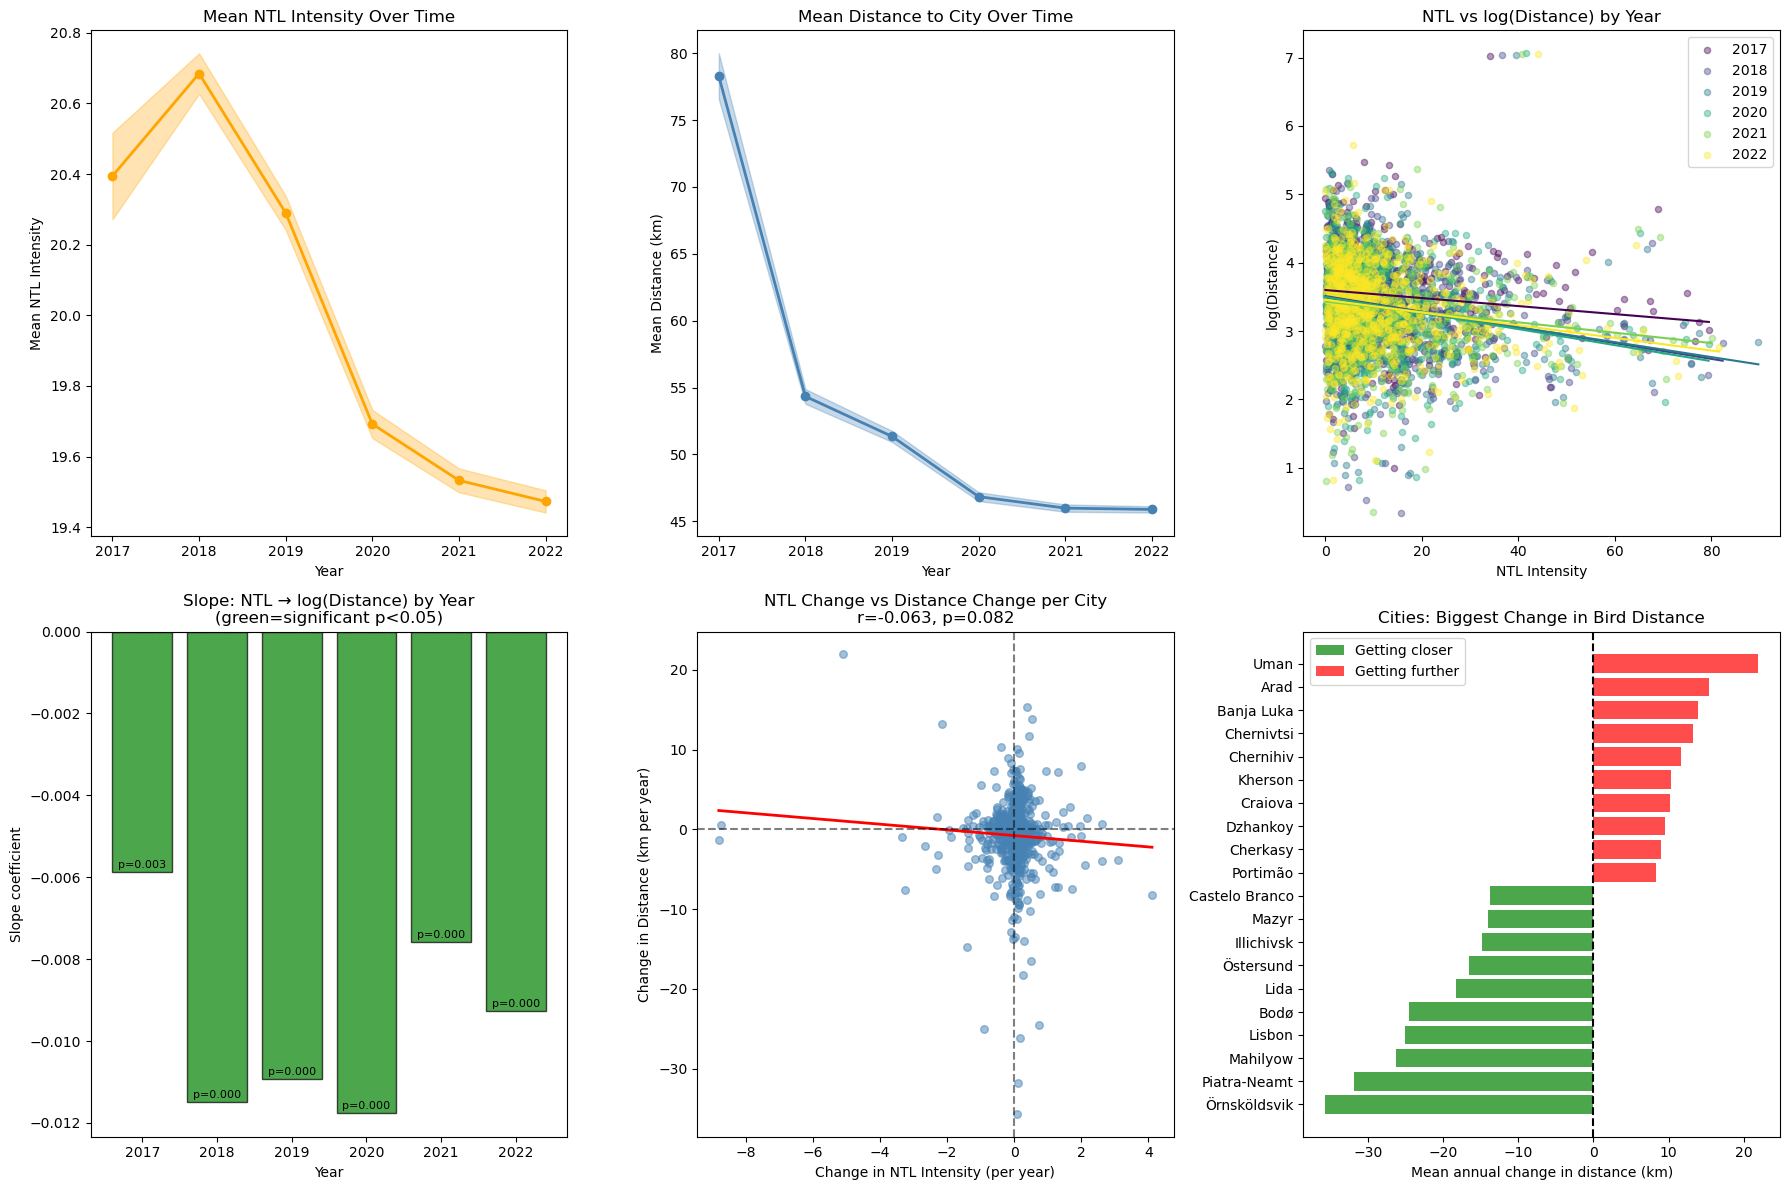

NTL Trend (linear regression over years):
NTL slope: -0.2474 per year, r=-0.908, p=0.012

 Distance Trend (linear regression over years): 
Distance slope: -5.4738 km per year, r=-0.821, p=0.045

 Slope by year (NTL & distance):
2017: slope=-0.0059, p=0.0029 significant
2018: slope=-0.0115, p=0.0000 significant
2019: slope=-0.0109, p=0.0000 significant
2020: slope=-0.0117, p=0.0000 significant
2021: slope=-0.0076, p=0.0001 significant
2022: slope=-0.0093, p=0.0000 significant


In [80]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# NTL intensity trend over time with confidence interval
yearly_ntl = df_clean.groupby('year')['ntl_intensity'].agg(['mean', 'std', 'count'])
yearly_ntl['se'] = yearly_ntl['std'] / np.sqrt(yearly_ntl['count'])
yearly_ntl['ci'] = 1.96 * yearly_ntl['se']

axes[0,0].plot(yearly_ntl.index, yearly_ntl['mean'], marker='o', color='orange', linewidth=2)
axes[0,0].fill_between(yearly_ntl.index, 
                        yearly_ntl['mean'] - yearly_ntl['ci'],
                        yearly_ntl['mean'] + yearly_ntl['ci'],
                        alpha=0.3, color='orange')
axes[0,0].set_title('Mean NTL Intensity Over Time')
axes[0,0].set_xlabel('Year')
axes[0,0].set_ylabel('Mean NTL Intensity')

# Mean distance trend over time
yearly_dist = df_clean.groupby('year')['distance_km'].agg(['mean', 'std', 'count'])
yearly_dist['ci'] = 1.96 * yearly_dist['std'] / np.sqrt(yearly_dist['count'])

axes[0,1].plot(yearly_dist.index, yearly_dist['mean'], marker='o', color='steelblue', linewidth=2)
axes[0,1].fill_between(yearly_dist.index,
                        yearly_dist['mean'] - yearly_dist['ci'],
                        yearly_dist['mean'] + yearly_dist['ci'],
                        alpha=0.3, color='steelblue')
axes[0,1].set_title('Mean Distance to City Over Time')
axes[0,1].set_xlabel('Year')
axes[0,1].set_ylabel('Mean Distance (km)')

# NTL vs distance scatter by year with regression line
colors = plt.cm.viridis(np.linspace(0, 1, 6))
for i, year in enumerate(range(2017, 2023)):
    year_data = city_year[city_year['year'] == year]
    axes[0,2].scatter(year_data['ntl_intensity'], year_data['log_distance'],
                      alpha=0.4, s=20, color=colors[i], label=str(year))
    # adds the regression line
    slope, intercept, r, p, se = stats.linregress(year_data['ntl_intensity'], 
                                                    year_data['log_distance'])
    x_line = np.linspace(year_data['ntl_intensity'].min(), 
                          year_data['ntl_intensity'].max(), 100)
    axes[0,2].plot(x_line, intercept + slope * x_line, color=colors[i], linewidth=1.5)

axes[0,2].set_title('NTL vs log(Distance) by Year')
axes[0,2].set_xlabel('NTL Intensity')
axes[0,2].set_ylabel('log(Distance)')
axes[0,2].legend()

# slope of NTL distance relationship by year
slopes = []
pvalues = []
for year in range(2017, 2023):
    year_data = city_year[city_year['year'] == year]
    slope, intercept, r, p, se = stats.linregress(year_data['ntl_intensity'],
                                                    year_data['log_distance'])
    slopes.append(slope)
    pvalues.append(p)

years = list(range(2017, 2023))
colors_sig = ['green' if p < 0.05 else 'red' for p in pvalues]
axes[1,0].bar(years, slopes, color=colors_sig, alpha=0.7, edgecolor='black')
axes[1,0].axhline(y=0, color='black', linestyle='--')
axes[1,0].set_title('Slope: NTL → log(Distance) by Year\n(green=significant p<0.05)')
axes[1,0].set_xlabel('Year')
axes[1,0].set_ylabel('Slope coefficient')

for year, slope, p in zip(years, slopes, pvalues):
    axes[1,0].text(year, slope + 0.0001, f'p={p:.3f}', ha='center', fontsize=8)

# cities getting brighter vs distance change
city_trend = city_year.groupby('closest_city').apply(lambda x: pd.Series({
    'ntl_change': x.set_index('year')['ntl_intensity'].reindex(range(2017,2023)).diff().mean(),
    'distance_change': x.set_index('year')['mean_distance'].reindex(range(2017,2023)).diff().mean(),
    'mean_ntl': x['ntl_intensity'].mean(),
    'n_years': len(x)
})).dropna().reset_index()

city_trend = city_trend[city_trend['n_years'] >= 4]

axes[1,1].scatter(city_trend['ntl_change'], city_trend['distance_change'],
                   alpha=0.5, s=30, color='steelblue')
slope, intercept, r, p, se = stats.linregress(city_trend['ntl_change'], 
                                                city_trend['distance_change'])
x_line = np.linspace(city_trend['ntl_change'].min(), city_trend['ntl_change'].max(), 100)
axes[1,1].plot(x_line, intercept + slope * x_line, color='red', linewidth=2)
axes[1,1].axhline(y=0, color='black', linestyle='--', alpha=0.5)
axes[1,1].axvline(x=0, color='black', linestyle='--', alpha=0.5)
axes[1,1].set_title(f'NTL Change vs Distance Change per City\nr={r:.3f}, p={p:.3f}')
axes[1,1].set_xlabel('Change in NTL Intensity (per year)')
axes[1,1].set_ylabel('Change in Distance (km per year)')

# top cities where birds getting closer vs brighter
city_trend_sorted = city_trend.sort_values('distance_change')
top_closer = city_trend_sorted.head(10)
top_further = city_trend_sorted.tail(10)

ax = axes[1,2]
ax.barh(top_closer['closest_city'], top_closer['distance_change'], 
        color='green', alpha=0.7, label='Getting closer')
ax.barh(top_further['closest_city'], top_further['distance_change'],
        color='red', alpha=0.7, label='Getting further')
ax.axvline(x=0, color='black', linestyle='--')
ax.set_title('Cities: Biggest Change in Bird Distance')
ax.set_xlabel('Mean annual change in distance (km)')
ax.legend()

plt.tight_layout()
plt.show()

# summary of the results we got
print("NTL Trend (linear regression over years):")
slope_ntl, _, r_ntl, p_ntl, _ = stats.linregress(
    list(range(2017,2023)), yearly_ntl['mean'].values)
print(f"NTL slope: {slope_ntl:.4f} per year, r={r_ntl:.3f}, p={p_ntl:.3f}")

print("\n Distance Trend (linear regression over years): ")
slope_dist, _, r_dist, p_dist, _ = stats.linregress(
    list(range(2017,2023)), yearly_dist['mean'].values)
print(f"Distance slope: {slope_dist:.4f} km per year, r={r_dist:.3f}, p={p_dist:.3f}")

print("\n Slope by year (NTL & distance):")
for year, slope, p in zip(years, slopes, pvalues):
    sig = "significant" if p < 0.05 else " not significant"
    print(f"{year}: slope={slope:.4f}, p={p:.4f} {sig}")

### Statistical Approach

We test three hypotheses:

1. **Is distance to city decreasing over time?** — Weighted linear regression (WLS) on annual mean distances, weighted by observation count per year
2. **Is the trend monotonic?** — Exact permutation Mann-Kendall test (6 years = 720 permutations)
3. **Did COVID lockdowns differentially affect resident vs migratory birds?** — Difference-in-Differences (DiD) with city fixed effects

We use **weighted** regression rather than OLS because earlier years have far fewer observations (e.g. 4,583 in 2017 vs 185,151 in 2022), making unweighted means unreliable. The Mann-Kendall test uses exact permutation p-values rather than the normal approximation, which is more accurate with only 6 data points.

### DiD

Median NTL intensity (2019 baseline): 7.43
High NTL cities (treatment): 379
Low NTL cities (control): 379


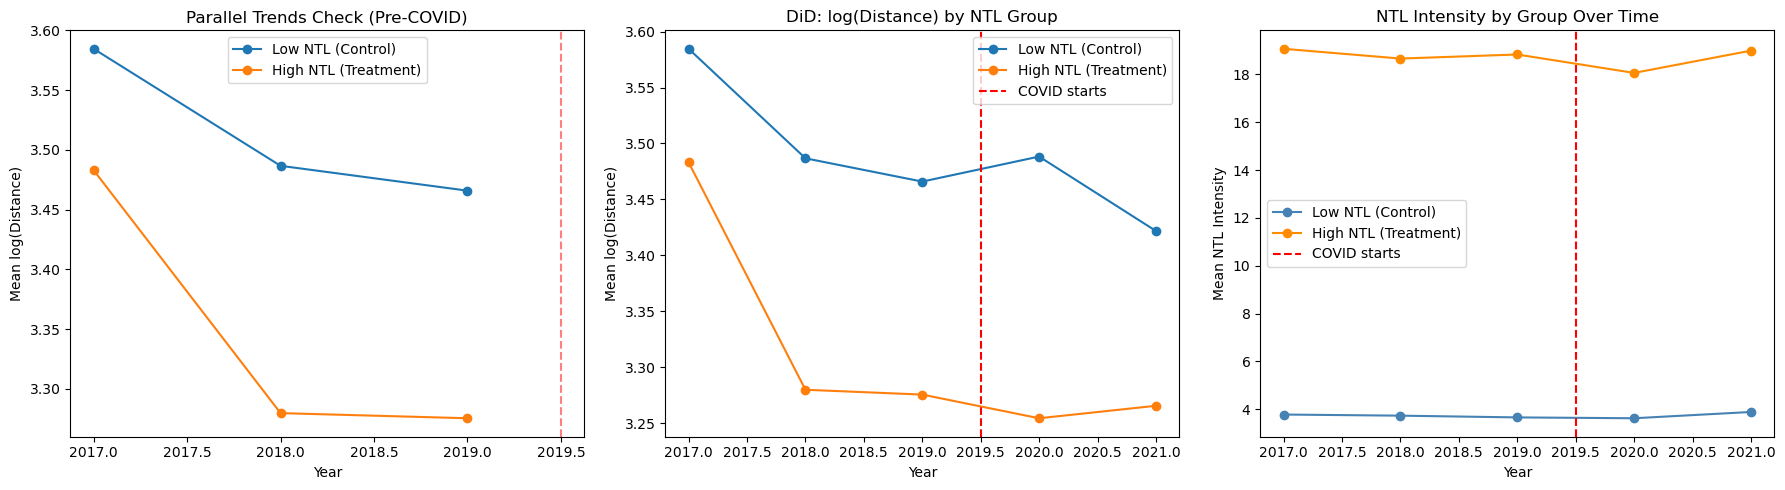


 DiD Regression Results:
high_ntl coefficient:    -0.0907
covid coefficient:       -0.0131
interaction (DiD) coef:  -0.0129

 Manual DiD Calculation:
          Pre-COVID  During COVID
Low NTL    3.508965      3.454838
High NTL   3.343883      3.259938

DiD Estimate: -0.0298
In km: -0.0294 km

High NTL change (pre -> covid): -0.0839
Low NTL change (pre -> covid):  -0.0541
DiD statistic: -0.0298
T-statistic: -0.8847, p-value: 0.3765


In [84]:
# create pre and post COVID indicator
city_year['covid'] = city_year['year'].isin([2020, 2021]).astype(int)
city_year['pre_covid'] = city_year['year'].isin([2017, 2018, 2019]).astype(int)

# filter to pre + during COVID only (drop 2022)
did_df = city_year[city_year['year'] != 2022].copy()

# define "high NTL" cities as treatment group
# cities above median NTL intensity in 2019 (pre-COVID baseline)
baseline_ntl = city_year[city_year['year'] == 2019].set_index('closest_city')['ntl_intensity']
median_ntl = baseline_ntl.median()
print(f"Median NTL intensity (2019 baseline): {median_ntl:.2f}")

# assign treatment group based on pre-COVID NTL
high_ntl_cities = baseline_ntl[baseline_ntl >= median_ntl].index
did_df['high_ntl'] = did_df['closest_city'].isin(high_ntl_cities).astype(int)

print(f"High NTL cities (treatment): {did_df['high_ntl'].sum() // 5}")
print(f"Low NTL cities (control): {(1-did_df['high_ntl']).sum() // 5}")

# parallel trends check
# must verify that treatment and control groups had similar trends pre-COVID
pre_covid = did_df[did_df['pre_covid'] == 1]
trends = pre_covid.groupby(['year', 'high_ntl'])['log_distance'].mean().unstack()
trends.columns = ['Low NTL (Control)', 'High NTL (Treatment)']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

trends.plot(ax=axes[0], marker='o')
axes[0].set_title('Parallel Trends Check (Pre-COVID)')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Mean log(Distance)')
axes[0].axvline(x=2019.5, color='red', linestyle='--', alpha=0.5)

# DiD plot
full_trends = did_df.groupby(['year', 'high_ntl'])['log_distance'].mean().unstack()
full_trends.columns = ['Low NTL (Control)', 'High NTL (Treatment)']
full_trends.plot(ax=axes[1], marker='o')
axes[1].axvline(x=2019.5, color='red', linestyle='--', label='COVID starts')
axes[1].set_title('DiD: log(Distance) by NTL Group')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Mean log(Distance)')
axes[1].legend()

# NTL change during COVID
ntl_trends = did_df.groupby(['year', 'high_ntl'])['ntl_intensity'].mean().unstack()
ntl_trends.columns = ['Low NTL (Control)', 'High NTL (Treatment)']
ntl_trends.plot(ax=axes[2], marker='o', color=['steelblue', 'darkorange'])
axes[2].axvline(x=2019.5, color='red', linestyle='--', label='COVID starts')
axes[2].set_title('NTL Intensity by Group Over Time')
axes[2].set_xlabel('Year')
axes[2].set_ylabel('Mean NTL Intensity')
axes[2].legend()

plt.tight_layout()
plt.show()

# DiD Regression
# DiD model: log_distance = α + β1*high_ntl + β2*covid + β3*(high_ntl × covid) + controls
did_df['interaction'] = did_df['high_ntl'] * did_df['covid']

# encode city fixed effects
city_fe = pd.get_dummies(did_df['closest_city'], drop_first=True)

X_did = pd.concat([
    did_df[['high_ntl', 'covid', 'interaction', 'city_lat', 'city_lon', 'n_observations']],
    city_fe
], axis=1)

y_did = did_df['log_distance']

scaler = StandardScaler()
X_did_scaled = scaler.fit_transform(X_did)

model_did = Ridge(alpha=1.0)
model_did.fit(X_did_scaled, y_did)

# extract key coefficients
feature_names = X_did.columns.tolist()
coef_dict = dict(zip(feature_names, model_did.coef_))

print("\n DiD Regression Results:")
print(f"high_ntl coefficient:    {coef_dict['high_ntl']:.4f}")
print(f"covid coefficient:       {coef_dict['covid']:.4f}")
print(f"interaction (DiD) coef:  {coef_dict['interaction']:.4f}")

# manual DiD calculation
print("\n Manual DiD Calculation:")
means = did_df.groupby(['high_ntl', 'covid'])['log_distance'].mean().unstack()
means.index = ['Low NTL', 'High NTL']
means.columns = ['Pre-COVID', 'During COVID']
print(means)

did_estimate = ((means.loc['High NTL', 'During COVID'] - means.loc['High NTL', 'Pre-COVID']) - 
                (means.loc['Low NTL', 'During COVID'] - means.loc['Low NTL', 'Pre-COVID']))
print(f"\nDiD Estimate: {did_estimate:.4f}")
print(f"In km: {np.expm1(did_estimate):.4f} km")

# statistical test
high_pre = did_df[(did_df['high_ntl']==1) & (did_df['pre_covid']==1)]['log_distance']
high_post = did_df[(did_df['high_ntl']==1) & (did_df['covid']==1)]['log_distance']
low_pre = did_df[(did_df['high_ntl']==0) & (did_df['pre_covid']==1)]['log_distance']
low_post = did_df[(did_df['high_ntl']==0) & (did_df['covid']==1)]['log_distance']

diff_high = high_post.mean() - high_pre.mean()
diff_low = low_post.mean() - low_pre.mean()
did_stat = diff_high - diff_low

print(f"\nHigh NTL change (pre -> covid): {diff_high:.4f}")
print(f"Low NTL change (pre -> covid):  {diff_low:.4f}")
print(f"DiD statistic: {did_stat:.4f}")

# T-test on interaction
t_stat, p_val = stats.ttest_ind(
    high_post - high_pre.mean(),
    low_post - low_pre.mean()
)
print(f"T-statistic: {t_stat:.4f}, p-value: {p_val:.4f}")

In [85]:
# classify species
print("Observations by species type:")
print(df_clean['species_type'].value_counts())
print(f"\nMigratory: {df_clean[df_clean['species_type']=='migratory']['SCIENTIFIC NAME'].unique()}")
print(f"\nResident: {df_clean[df_clean['species_type']=='native']['SCIENTIFIC NAME'].unique()}")

df_clean['month'] = pd.to_datetime(
    df_clean['OBSERVATION DATE'], 
    format='mixed', 
    errors='coerce' # to avoid crashes, just in case
).dt.month

# check seasonal pattern of migratory species
# df_clean['month'] = pd.to_datetime(df_clean['OBSERVATION DATE']).dt.month
print("\nGreen Sandpiper observations by month:")
print(df_clean[df_clean['SCIENTIFIC NAME']=='Tringa ochropus']['month'].value_counts().sort_index())

Observations by species type:
species_type
native       3633584
migratory     679292
Name: count, dtype: int64

Migratory: ['Numenius phaeopus' 'Calidris ferruginea' 'Calidris alba'
 'Calidris minuta' 'Calidris canutus' 'Calidris pugnax' 'Tringa ochropus'
 'Tringa glareola' 'Spatula querquedula' 'Pernis apivorus'
 'Chlidonias niger']

Resident: ['Dendrocopos major' 'Strix aluco' 'Parus major' 'Tringa ochropus'
 'Pyrrhula pyrrhula' 'Erithacus rubecula']

Green Sandpiper observations by month:
month
1     23100
2     18826
3     31974
4     37786
5      8400
6     14248
7     35322
8     57554
9     45786
10    28928
11    21526
12    22628
Name: count, dtype: int64


Dataset shape: (8743, 11)
year              2017      2018      2019      2020      2021      2022
species_type                                                            
migratory     3.559929  3.552112  3.554287  3.546474  3.522181  3.530295
native        3.496360  3.347944  3.342866  3.339215  3.313208  3.326568


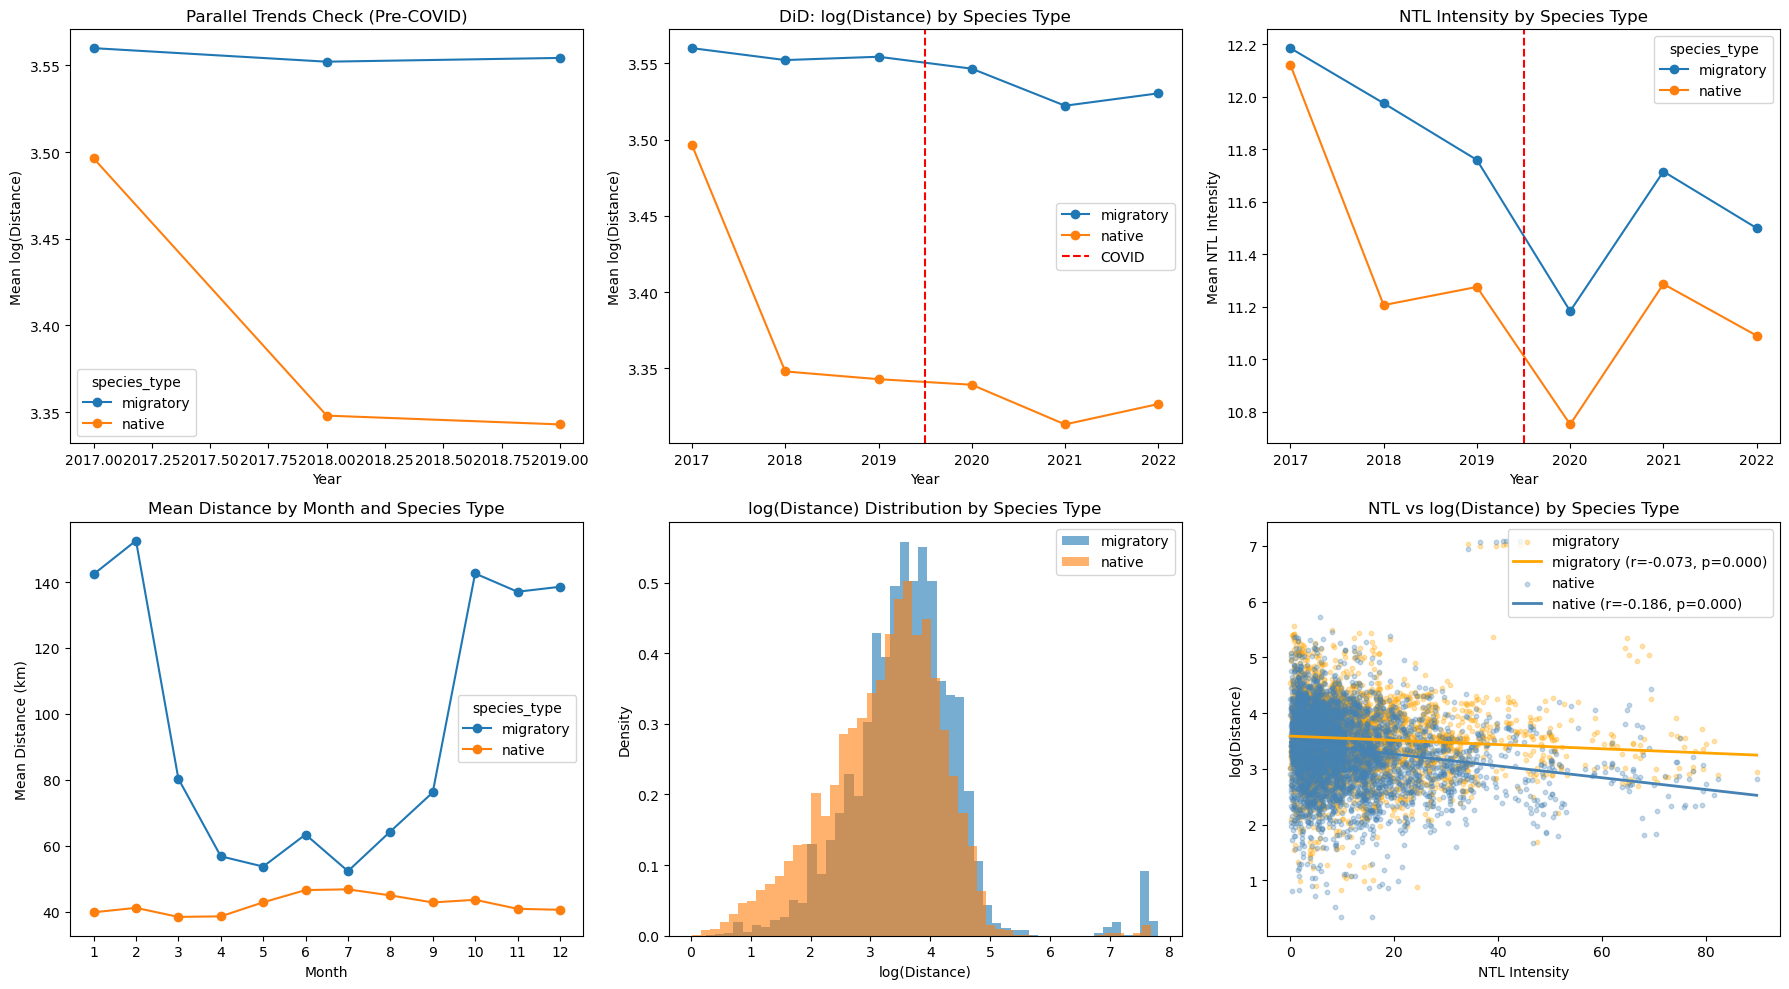


Cities with both species types: 782

DiD Regression Results
migratory coefficient:  0.0785
post (COVID) coef:      -0.0258
DiD (interaction) coef: 0.0165
ntl_intensity coef:     0.0406
R²: 0.7216

Manual DiD
              Pre-COVID  During/Post COVID
species_type                              
migratory      3.555376           3.532829
native         3.393883           3.337241

DiD Estimate: 0.0341 log units
In km change: 0.0347 km

Migratory change (pre -> post): -0.0225
Resident change (pre -> post):  -0.0566
DiD: 0.0341
T-statistic: 1.7883, p-value: 0.0738


In [86]:
# aggregate by species_type, city, year
species_city_year = df_clean.groupby(['species_type', 'closest_city', 'year']).agg(
    mean_distance=('distance_km', 'mean'),
    log_distance=('distance_km', lambda x: np.log1p(x).mean()),
    ntl_intensity=('ntl_intensity', 'mean'),
    n_obs=('distance_km', 'count')
).reset_index()

# COVID indicator
species_city_year['covid'] = species_city_year['year'].isin([2020, 2021]).astype(int)
species_city_year['post'] = (species_city_year['year'] >= 2020).astype(int)
species_city_year['migratory'] = (species_city_year['species_type'] == 'migratory').astype(int)
species_city_year['did'] = species_city_year['migratory'] * species_city_year['post']

print(f"Dataset shape: {species_city_year.shape}")
print(species_city_year.groupby(['species_type', 'year'])['log_distance'].mean().unstack())

# parallel trends check
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

pre_covid = species_city_year[species_city_year['year'] < 2020]
trends_pre = pre_covid.groupby(['year', 'species_type'])['log_distance'].mean().unstack()

trends_pre.plot(ax=axes[0,0], marker='o')
axes[0,0].set_title('Parallel Trends Check (Pre-COVID)')
axes[0,0].set_xlabel('Year')
axes[0,0].set_ylabel('Mean log(Distance)')

# DiD plot
trends_full = species_city_year.groupby(['year', 'species_type'])['log_distance'].mean().unstack()
trends_full.plot(ax=axes[0,1], marker='o')
axes[0,1].axvline(x=2019.5, color='red', linestyle='--', label='COVID')
axes[0,1].set_title('DiD: log(Distance) by Species Type')
axes[0,1].set_xlabel('Year')
axes[0,1].set_ylabel('Mean log(Distance)')
axes[0,1].legend()

# NTL by species type
ntl_trends = species_city_year.groupby(['year', 'species_type'])['ntl_intensity'].mean().unstack()
ntl_trends.plot(ax=axes[0,2], marker='o')
axes[0,2].axvline(x=2019.5, color='red', linestyle='--')
axes[0,2].set_title('NTL Intensity by Species Type')
axes[0,2].set_xlabel('Year')
axes[0,2].set_ylabel('Mean NTL Intensity')

# seasonal pattern
monthly = df_clean.groupby(['month', 'species_type'])['distance_km'].mean().unstack()
monthly.plot(ax=axes[1,0], marker='o')
axes[1,0].set_title('Mean Distance by Month and Species Type')
axes[1,0].set_xlabel('Month')
axes[1,0].set_ylabel('Mean Distance (km)')
axes[1,0].set_xticks(range(1,13))

# distance distribution by species
for species in df_clean['species_type'].unique():
    data = np.log1p(df_clean[df_clean['species_type']==species]['distance_km'])
    axes[1,1].hist(data, bins=50, alpha=0.6, label=species, density=True)
axes[1,1].set_title('log(Distance) Distribution by Species Type')
axes[1,1].set_xlabel('log(Distance)')
axes[1,1].set_ylabel('Density')
axes[1,1].legend()

# NTL vs Distance by species
for species, color in zip(['migratory', 'native'], ['orange', 'steelblue']):
    data = species_city_year[species_city_year['species_type']==species]
    axes[1,2].scatter(data['ntl_intensity'], data['log_distance'],
                      alpha=0.3, s=10, color=color, label=species)
    slope, intercept, r, p, _ = stats.linregress(data['ntl_intensity'], data['log_distance'])
    x_line = np.linspace(data['ntl_intensity'].min(), data['ntl_intensity'].max(), 100)
    axes[1,2].plot(x_line, intercept + slope*x_line, color=color, linewidth=2,
                   label=f'{species} (r={r:.3f}, p={p:.3f})')
axes[1,2].set_title('NTL vs log(Distance) by Species Type')
axes[1,2].set_xlabel('NTL Intensity')
axes[1,2].set_ylabel('log(Distance)')
axes[1,2].legend()

plt.tight_layout()
plt.show()

# DiD Regression
# only uses cities that have both species types
cities_both = species_city_year.groupby('closest_city')['species_type'].nunique()
cities_both = cities_both[cities_both == 2].index
did_df = species_city_year[species_city_year['closest_city'].isin(cities_both)].copy()
print(f"\nCities with both species types: {len(cities_both)}")

city_fe = pd.get_dummies(did_df['closest_city'], drop_first=True)
X_did = pd.concat([
    did_df[['migratory', 'post', 'did', 'ntl_intensity']],
    city_fe
], axis=1)
y_did = did_df['log_distance']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_did)
model = Ridge(alpha=1.0)
model.fit(X_scaled, y_did)

feature_names = X_did.columns.tolist()
coef_dict = dict(zip(feature_names, model.coef_))

print("\nDiD Regression Results")
print(f"migratory coefficient:  {coef_dict['migratory']:.4f}")
print(f"post (COVID) coef:      {coef_dict['post']:.4f}")
print(f"DiD (interaction) coef: {coef_dict['did']:.4f}")
print(f"ntl_intensity coef:     {coef_dict['ntl_intensity']:.4f}")
print(f"R²: {model.score(X_scaled, y_did):.4f}")

# manual DiD
print("\nManual DiD")
means = did_df.groupby(['species_type', 'post'])['log_distance'].mean().unstack()
means.columns = ['Pre-COVID', 'During/Post COVID']
print(means)

did_est = ((means.loc['migratory','During/Post COVID'] - means.loc['migratory','Pre-COVID']) -
           (means.loc['native','During/Post COVID'] - means.loc['native','Pre-COVID']))
print(f"\nDiD Estimate: {did_est:.4f} log units")
print(f"In km change: {np.expm1(abs(did_est)):.4f} km")

# T-test
mig_pre = did_df[(did_df['species_type']=='migratory') & (did_df['post']==0)]['log_distance']
mig_post = did_df[(did_df['species_type']=='migratory') & (did_df['post']==1)]['log_distance']
res_pre = did_df[(did_df['species_type']=='native') & (did_df['post']==0)]['log_distance']
res_post = did_df[(did_df['species_type']=='native') & (did_df['post']==1)]['log_distance']

diff_mig = mig_post.mean() - mig_pre.mean()
diff_res = res_post.mean() - res_pre.mean()
print(f"\nMigratory change (pre -> post): {diff_mig:.4f}")
print(f"Resident change (pre -> post):  {diff_res:.4f}")
print(f"DiD: {diff_mig - diff_res:.4f}")

t_stat, p_val = stats.ttest_ind(mig_post - mig_pre.mean(), res_post - res_pre.mean())
print(f"T-statistic: {t_stat:.4f}, p-value: {p_val:.4f}")

### eBird data

#### Data preprocessing

In [2]:
# path to the raw file obtained from ebird
path_to_folder = '/Users/dazedinthecity/Desktop/Data_sci_proj/raw_migra_species'
# choose the the bird species you want to clean
file_path = os.path.join(path_to_folder,'ebd_woosan_201701_202212_relJan-2026.txt' )

In [ ]:
# we use sep='\t' because eBird files are Tab-Separated
# we use nrows=5 to just grab a tiny sample
try:
    df = pd.read_csv(file_path, sep='\t', nrows=5)

    # this makes the output "beautiful" in the console
    pd.set_option('display.max_columns', None)  # show all columns
    pd.set_option('display.width', 1000)        # don't wrap lines
    
    print("---eBird Data Preview---")
    print(df.head(20))
    
    print("\n--- Column Names (So you know what you can filter by) ---")
    print(df.columns.tolist())

except FileNotFoundError:
    print("Error: The file wasn't found. Double-check the file path!")

Error: The file wasn't found. Double-check the file path!


In [4]:
def clean_bird_data(input_file, output_file=None, species_filter=None):
    """
    select specific cols
    """ 
    delimiter = '\t' if input_file.endswith('.txt') else ","
# columns you want to keep
# these were the ones i kept but not all of these were used
    keep_cols = [ "COMMON NAME", 
                 "SCIENTIFIC NAME", 
                 "OBSERVATION COUNT", 
                 "AGE/SEX", 
                 "COUNTRY", 
                 "COUNTRY CODE", 
                 "STATE", 
                 "STATE CODE", 
                 "COUNTY", 
                 "COUNTY CODE", 
                 "ATLAS BLOCK", 
                 "LOCALITY", 
                 "LOCALITY ID", 
                 "LOCALITY TYPE", 
                 "LATITUDE", 
                 "LONGITUDE", 
                 "OBSERVATION DATE",
                 'OBSERVER ID', 
                 "SAMPLING EVENT IDENTIFIER", 
                 "OBSERVATION TYPE" 
                ]
    
    print(f"Reading {input_file}...")
    # loadinig the data
    # usecols speed up the process by only reading what you need from the disk
    df = pd.read_csv(input_file, sep=delimiter, usecols=keep_cols, low_memory=False)
    # 1. filtering by species if we get form some otherr dataset
    if species_filter:
        df = df[df["SCIENTIFIC NAME"] == species_filter]
    
    # this is not used
    if not output_file:
        base = os.path.splitext(input_file)[0]
        output_file = f"{base}_cleaned.csv"

    # this df will be sent to the next func
    return df


In [5]:
def europe_only(df, output_file=None, OUTPUT_DIR="/Users/dazedinthecity/Desktop/nika_datasciproj/bird_test", file_name=''): 
    """
    takes df from clean_bird_data func, filters for European countries, and saves a smaller CSV.
    Changes X to 1 to turn the column numeric and processes the date into pandas datetime.
    output_file: the name of the cleaned data
    output_dir : where the new file will be saved
    """
    os.makedirs(OUTPUT_DIR, exist_ok=True)

    europe_codes = [
        'AT', 'BE', 'BG', 'HR', 'CY', 'CZ', 'DK', 'EE', 'FI', 'FR', 'DE', 'GR', 'EL',
        'HU', 'IE', 'IT', 'LV', 'LT', 'LU', 'MT', 'NL', 'PL', 'PT', 'RO', 'SK', 'SI', 
        'ES', 'SE', 'IS', 'LI', 'NO', 'CH', 'GB', 'UK', 'AD', 'AL', 'BA', 'BY', 'FO', 
        'GI', 'GG', 'IM', 'JE', 'MD', 'MC', 'ME', 'MK', 'RS', 'SM', 'UA', 'VA'
    ]

    initial_count = len(df)
    df = df[df['COUNTRY CODE'].isin(europe_codes)]
    filtered_count = len(df)

    df['OBSERVATION COUNT'] = df['OBSERVATION COUNT'].replace('X', '1').astype(float)
    df['OBSERVATION DATE'] = pd.to_datetime(df['OBSERVATION DATE'])

    if OUTPUT_DIR:
        output_file = os.path.join(OUTPUT_DIR, f"{file_name}_europe_only.csv")
        df.to_csv(output_file, index=False)

    print(f"Done! Reduced dataset from {initial_count} to {filtered_count} European records.")
    # if output_file:
    #     print(f"Saved to: {output_file}")

    return df

In [7]:
# perform these 2 funcs for all the bird species (each species is an individual file)
directory = Path("/Users/dazedinthecity/Desktop/nika_datasciproj/datasets/from ebird/raw_migra_species") #change here


# option 1 – simple list
files = [p for p in directory.iterdir() if p.is_file()]
for f in files:
    file_name = f.stem  # Extract the filename without extension
    input_f = str(f)
    cleaned_df = clean_bird_data(input_f)
    europe_only(cleaned_df, output_file=f"{file_name}_europe_only.csv", file_name=file_name)

Reading /Users/dazedinthecity/Desktop/nika_datasciproj/datasets/from ebird/raw_migra_species/ebd_cursan_201701_202212_relJan-2026.txt...


/var/folders/ty/1b7rrh3s0yx8wvyxm5v17jdw0000gp/T/ipykernel_90145/626930204.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['OBSERVATION COUNT'] = df['OBSERVATION COUNT'].replace('X', '1').astype(float)
/var/folders/ty/1b7rrh3s0yx8wvyxm5v17jdw0000gp/T/ipykernel_90145/626930204.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['OBSERVATION DATE'] = pd.to_datetime(df['OBSERVATION DATE'])


Done! Reduced dataset from 97936 to 36902 European records.
Reading /Users/dazedinthecity/Desktop/nika_datasciproj/datasets/from ebird/raw_migra_species/ebd_redkno_201701_202212_relJan-2026.txt...


/var/folders/ty/1b7rrh3s0yx8wvyxm5v17jdw0000gp/T/ipykernel_90145/626930204.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['OBSERVATION COUNT'] = df['OBSERVATION COUNT'].replace('X', '1').astype(float)
/var/folders/ty/1b7rrh3s0yx8wvyxm5v17jdw0000gp/T/ipykernel_90145/626930204.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['OBSERVATION DATE'] = pd.to_datetime(df['OBSERVATION DATE'])
/var/folders/ty/1b7rrh3s0yx8wvyxm5v17jdw0000gp/T/ipykernel_90145/626930204.py:21: SettingWithCopyWarning: 
A v

Done! Reduced dataset from 154954 to 42089 European records.
Reading /Users/dazedinthecity/Desktop/nika_datasciproj/datasets/from ebird/raw_migra_species/ebd_x00786_201701_202212_relJan-2026.txt...
Done! Reduced dataset from 80 to 0 European records.
Reading /Users/dazedinthecity/Desktop/nika_datasciproj/datasets/from ebird/raw_migra_species/ebd_blkter1_relJan-2026.txt...
Done! Reduced dataset from 2291 to 1783 European records.
Reading /Users/dazedinthecity/Desktop/nika_datasciproj/datasets/from ebird/raw_migra_species/ebd_euhbuz1_201701_202212_relJan-2026.txt...


...

Done! Reduced dataset from 794571 to 87824 European records.
Reading /Users/dazedinthecity/Desktop/nika_datasciproj/datasets/from ebird/raw_migra_species/ebd_gargan_201701_202212_relJan-2026.txt...


/var/folders/ty/1b7rrh3s0yx8wvyxm5v17jdw0000gp/T/ipykernel_90145/626930204.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['OBSERVATION COUNT'] = df['OBSERVATION COUNT'].replace('X', '1').astype(float)
/var/folders/ty/1b7rrh3s0yx8wvyxm5v17jdw0000gp/T/ipykernel_90145/626930204.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['OBSERVATION DATE'] = pd.to_datetime(df['OBSERVATION DATE'])


Done! Reduced dataset from 130356 to 52930 European records.
Reading /Users/dazedinthecity/Desktop/nika_datasciproj/datasets/from ebird/raw_migra_species/ebd_grnsan_relJan-2026.txt...


/var/folders/ty/1b7rrh3s0yx8wvyxm5v17jdw0000gp/T/ipykernel_90145/626930204.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['OBSERVATION COUNT'] = df['OBSERVATION COUNT'].replace('X', '1').astype(float)
/var/folders/ty/1b7rrh3s0yx8wvyxm5v17jdw0000gp/T/ipykernel_90145/626930204.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['OBSERVATION DATE'] = pd.to_datetime(df['OBSERVATION DATE'])


Done! Reduced dataset from 812034 to 437601 European records.


In [9]:
# combine all species into 1 csv

# Read the CSV
# this is where all the individual files were saved (same as in OUTPUT_DIR of the europe_only func)
directory = Path("/Users/dazedinthecity/Desktop/nika_datasciproj/bird_test") #change here

files = [p for p in directory.iterdir() if p.is_file() and p.suffix == '.csv']  # ← only CSVs
df_list = []

for f in files:
    df = pd.read_csv(f, encoding='latin-1')
    df['OBSERVATION DATE'] = pd.to_datetime(df['OBSERVATION DATE'])
    mask = (df['OBSERVATION DATE'].dt.year >= 2017) & (df['OBSERVATION DATE'].dt.year <= 2026)
    df_list.append(df[mask])

combined_df = pd.concat(df_list, ignore_index=True)

OUTPUT_DIR = '/Users/dazedinthecity/Desktop/nika_datasciproj/bird_test'
output_file = os.path.join(OUTPUT_DIR, 'migra_species_europe_only.csv') #change here
combined_df.to_csv(output_file, index=False)

print(f"Done! {combined_df.shape[0]} rows saved.")

/var/folders/ty/1b7rrh3s0yx8wvyxm5v17jdw0000gp/T/ipykernel_90145/1241829922.py:16: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  combined_df = pd.concat(df_list, ignore_index=True)


Done! 878189 rows saved.


#### Data cleaning

In [2]:
# read the clean csv
combined_df = pd.read_csv("/Users/dazedinthecity/Documents/GitHub/ceu-ds-project-groupB-2026/ebird/migra_species_europe_only.csv")
combined_df.shape

(878189, 20)

In [ ]:
# Convert date column to datetime
combined_df['obsDt'] = pd.to_datetime(combined_df['OBSERVATION DATE'], errors='coerce')

# Extract temporal features
combined_df['year'] = combined_df['obsDt'].dt.year
combined_df['month'] = combined_df['obsDt'].dt.month
combined_df['day_of_week'] = combined_df['obsDt'].dt.dayofweek
combined_df['day_of_year'] = combined_df['obsDt'].dt.dayofyear

# drop 2026 (it ruins the results)
combined_df = combined_df[combined_df['year'] < 2023]

# Convert count to numeric
combined_df['howMany'] = pd.to_numeric(combined_df['OBSERVATION COUNT'], errors='coerce')

print(" Data preprocessing complete!")
print(f"\nDate range: {combined_df['obsDt'].min()} to {combined_df['obsDt'].max()}")
print(f"Years covered: {sorted(combined_df['year'].dropna().unique().astype(int).tolist())}")

✓ Data preprocessing complete!

Date range: 2017-01-01 00:00:00 to 2022-12-31 00:00:00
Years covered: [2017, 2018, 2019, 2020, 2021, 2022]


#### Brief overview of data

In [4]:
# Overall statistics
print("="*80)
print("OVERALL DATASET STATISTICS")
print("="*80)
print(f"\nTotal observations: {len(combined_df):,}")
print(f"Number of countries: {combined_df['COUNTRY CODE'].nunique()}")
print(f"Number of states/regions: {combined_df['STATE CODE'].nunique()}")
print(f"Number of counties: {combined_df['COUNTY CODE'].nunique()}")
print(f"Number of unique species: {combined_df['SCIENTIFIC NAME'].nunique()}")
print(f"Number of locality types: {combined_df['LOCALITY TYPE'].nunique()}")
print(f"Number of observation types: {combined_df['OBSERVATION TYPE'].nunique()}")
print(f"Number of unique observers: {combined_df['OBSERVER ID'].nunique()}")

# Count data statistics
count_data = combined_df[combined_df['howMany'].notna()]
print(f"\nObservations with count data: {len(count_data):,} ({len(count_data)/len(combined_df)*100:.1f}%)")
if len(count_data) > 0:
    print(f"Total birds counted: {count_data['howMany'].sum():,.0f}")
    print(f"Average count per observation: {count_data['howMany'].mean():.2f}")
    print(f"Median count: {count_data['howMany'].median():.0f}")
    print(f"Maximum count in single observation: {count_data['howMany'].max():,.0f}")
    print(f"Minimum count: {count_data['howMany'].min():.0f}")

OVERALL DATASET STATISTICS

Total observations: 690,526
Number of countries: 46
Number of states/regions: 669
Number of counties: 1043
Number of unique species: 11
Number of locality types: 2
Number of observation types: 8
Number of unique observers: 19323

Observations with count data: 690,526 (100.0%)
Total birds counted: 15,355,201
Average count per observation: 22.24
Median count: 2
Maximum count in single observation: 140,000
Minimum count: 1


#### Outlier removal

In [5]:
# to see how it would be if i removed using IQR (i didn't end up using this method)
Q1 = combined_df['howMany'].quantile(0.25)
Q3 = combined_df['howMany'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = combined_df[(combined_df['howMany'] < lower_bound) | (combined_df['howMany'] > upper_bound)]

print("="*80)
print("OUTLIER ANALYSIS: howMany")
print("="*80)
print(f"\nQ1: {Q1}")
print(f"Q3: {Q3}")
print(f"IQR: {IQR}")
print(f"Lower bound: {lower_bound}")
print(f"Upper bound: {upper_bound}")
print(f"\nTotal outliers: {len(outliers):,} ({len(outliers)/len(combined_df)*100:.2f}% of data)")
print(f"\nOutlier summary:")
print(outliers['howMany'].describe())

print("="*80)
print("OUTLIER DISTRIBUTION: howMany")
print("="*80)

# Value counts for outliers
outlier_dist = outliers['howMany'].value_counts().sort_index()

print(f"\nTop 20 most frequent outlier values:")
print(outliers['howMany'].value_counts().head(20))

print(f"\nOutlier range distribution (binned):")
bins = [lower_bound, 50, 100, 500, 1000, 5000, float('inf')]
labels = [f'{int(lower_bound)}-50', '51-100', '101-500', '501-1000', '1001-5000', '5000+']
outlier_binned = pd.cut(outliers['howMany'], bins=bins, labels=labels)
print(outlier_binned.value_counts().sort_index())

print(f"\nKey outlier statistics:")
print(f"  Min outlier value:    {outliers['howMany'].min():,.0f}")
print(f"  Max outlier value:    {outliers['howMany'].max():,.0f}")
print(f"  Mean outlier value:   {outliers['howMany'].mean():,.2f}")
print(f"  Median outlier value: {outliers['howMany'].median():,.0f}")

OUTLIER ANALYSIS: howMany

Q1: 1.0
Q3: 5.0
IQR: 4.0
Lower bound: -5.0
Upper bound: 11.0

Total outliers: 90,888 (13.16% of data)

Outlier summary:
count     90888.000000
mean        152.053065
std        2037.232393
min          12.000000
25%          16.000000
50%          25.000000
75%          50.000000
max      140000.000000
Name: howMany, dtype: float64
OUTLIER DISTRIBUTION: howMany

Top 20 most frequent outlier values:
howMany
20.0     8475
15.0     7197
12.0     7191
30.0     5540
50.0     3810
25.0     3650
14.0     3413
40.0     3175
13.0     2833
16.0     2575
18.0     2289
100.0    2072
17.0     1911
60.0     1693
35.0     1576
22.0     1351
19.0     1310
80.0     1149
21.0     1143
200.0    1142
Name: count, dtype: int64

Outlier range distribution (binned):
howMany
-5-50        69064
51-100       11302
101-500       8563
501-1000       885
1001-5000      816
5000+          258
Name: count, dtype: int64

Key outlier statistics:
  Min outlier value:    12
  Max outlier value

In [6]:
# i decided to just drop rows that had >100 birds for an entry 

before = len(combined_df)
combined_df = combined_df[combined_df['howMany'] <= 100]
after = len(combined_df)

print("="*80)
print("AFTER DROPPING howMany > 100")
print("="*80)
print(f"\nRows before: {before:,}")
print(f"Rows after:  {after:,}")
print(f"Rows dropped: {before - after:,} ({(before - after)/before*100:.2f}% of data)")

AFTER DROPPING howMany > 100

Rows before: 690,526
Rows after:  680,004
Rows dropped: 10,522 (1.52% of data)


#### Country analysis

In [7]:
country_stats = combined_df.groupby(['COUNTRY CODE', 'COUNTRY']).agg(
    total_observations=('SAMPLING EVENT IDENTIFIER', 'count'),
    unique_species=('SCIENTIFIC NAME', 'nunique'),
    unique_states=('STATE', 'nunique'),
    unique_counties=('COUNTY', 'nunique'),
    total_birds=('howMany', lambda x: x.sum() if x.notna().any() else 0)
).reset_index()

country_stats.columns = ['Country Code', 'Country Name', 'Total Observations', 
                         'Unique Species', 'Unique States', 'Unique Counties', 
                         'Total Birds Counted']

country_stats = country_stats.sort_values('Total Observations', ascending=False)

print("\nSTATISTICS BY COUNTRY")
print("="*120)
print(country_stats.to_string(index=False))


STATISTICS BY COUNTRY
Country Code           Country Name  Total Observations  Unique Species  Unique States  Unique Counties  Total Birds Counted
          ES                  Spain              212295              11             19               48            1162672.0
          GB         United Kingdom              116040              11              4              103             632771.0
          PT               Portugal               76561              11             20              278             467789.0
          FR                 France               28733              11             13               96             160878.0
          DE                Germany               28532              11             16              327             156647.0
          PL                 Poland               21825              10             16                0             170154.0
          SE                 Sweden               21432              11             21                

#### Species analysis

In [8]:
# Species statistics
species_stats = combined_df.groupby(['COMMON NAME', 'SCIENTIFIC NAME']).agg({
    'SAMPLING EVENT IDENTIFIER': 'count',
    'COUNTRY CODE': 'nunique',
    'STATE CODE': 'nunique',
    'howMany': lambda x: x.sum() if x.notna().any() else 0
}).reset_index()

species_stats.columns = ['Common Name', 'Scientific Name', 
                        'Total Observations', 'Countries Found', 'States Found', 'Total Count']

species_stats = species_stats.sort_values('Total Observations', ascending=False)

print("\nTOP 30 MOST OBSERVED SPECIES")
print("="*120)
print(species_stats.head(30).to_string(index=False))


TOP 30 MOST OBSERVED SPECIES
           Common Name     Scientific Name  Total Observations  Countries Found  States Found  Total Count
       Green Sandpiper     Tringa ochropus              173660               44           557     413116.0
                  Ruff     Calidris pugnax              109964               42           491     951843.0
            Sanderling       Calidris alba               85484               42           305     984336.0
        Wood Sandpiper     Tringa glareola               74871               42           523     418857.0
              Garganey Spatula querquedula               52675               43           511     233464.0
          Little Stint     Calidris minuta               51689               43           383     286413.0
European Honey-buzzard     Pernis apivorus               44529               42           545     208528.0
              Red Knot    Calidris canutus               39126               40           273     316233.0
      C

#### Temporal analysis


TEMPORAL ANALYSIS

Observations by Year:
  2017: 61,361
  2018: 72,027
  2019: 93,957
  2020: 105,754
  2021: 149,076
  2022: 197,829

Observations by month of 2017
  January: 2,879
  February: 1,809
  March: 3,876
  April: 7,811
  May: 7,059
  June: 2,655
  July: 4,694
  August: 9,522
  September: 10,022
  October: 5,289
  November: 2,767
  December: 2,978
  → Peak migration month: September (10,022 observations)

Observations by month of 2018
  January: 3,580
  February: 2,813
  March: 4,391
  April: 8,318
  May: 10,164
  June: 3,551
  July: 6,526
  August: 10,991
  September: 10,790
  October: 4,735
  November: 2,869
  December: 3,299
  → Peak migration month: August (10,991 observations)

Observations by month of 2019
  January: 4,167
  February: 3,267
  March: 6,926
  April: 12,293
  May: 11,497
  June: 3,968
  July: 8,252
  August: 15,292
  September: 14,045
  October: 6,311
  November: 3,876
  December: 4,063
  → Peak migration month: August (15,292 observations)

Observations 

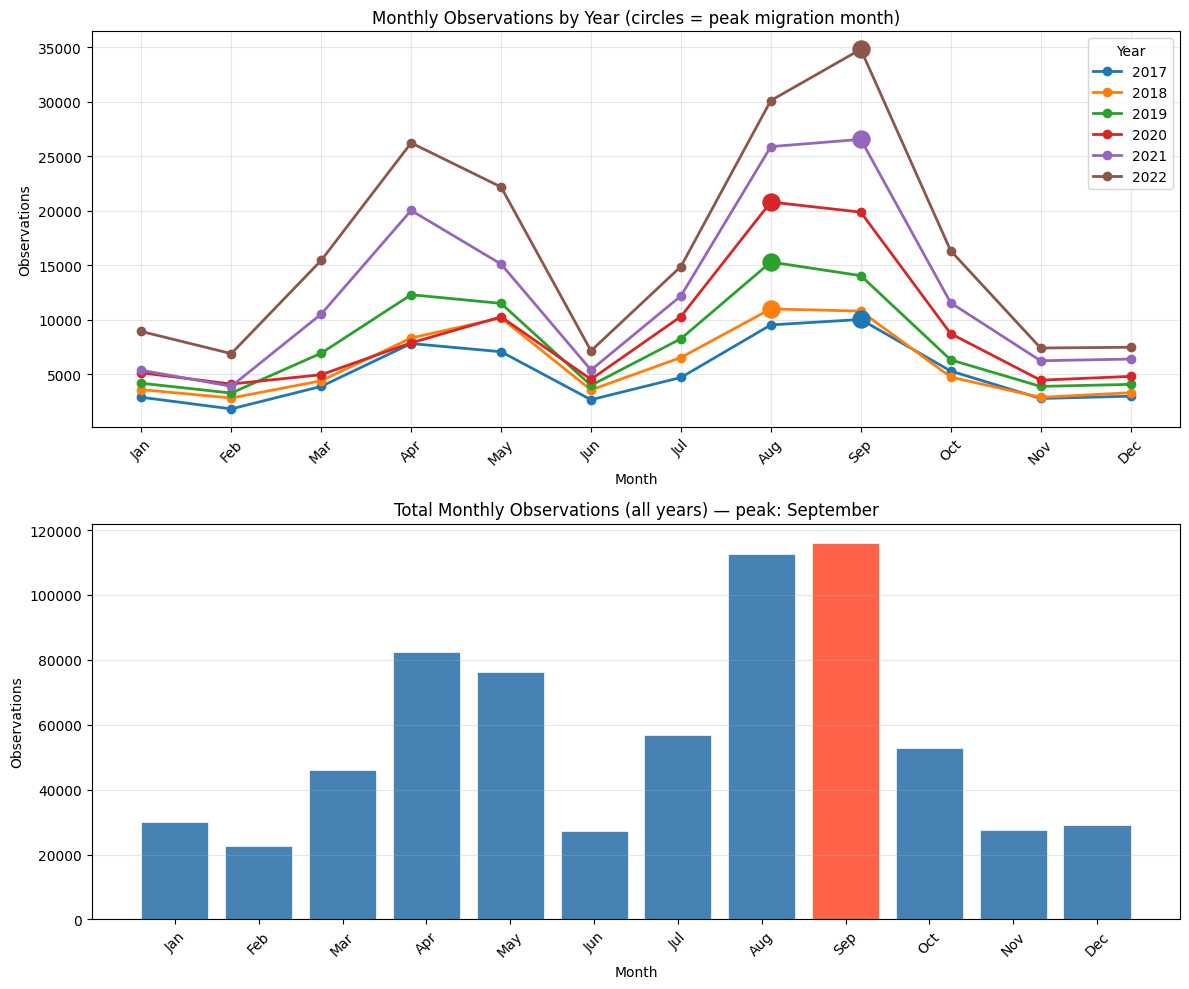

In [9]:
# Temporal distribution
print("\nTEMPORAL ANALYSIS")
print("="*60)

# By year
yearly_obs = combined_df.groupby('year').size().sort_index()
print("\nObservations by Year:")
for year, count in yearly_obs.items():
    if pd.notna(year):
        print(f"  {int(year)}: {count:,}")

# Month each year
month_names = {1: 'January', 2: 'February', 3: 'March', 4: 'April', 5: 'May', 6: 'June',
               7: 'July', 8: 'August', 9: 'September', 10: 'October', 11: 'November', 12: 'December'}

peak_months_by_year = {}  # store peak month per year

yearly_obs = combined_df.groupby('year').size().sort_index()
for year in yearly_obs.index:
    print("\nObservations by month of", int(year))
    monthly_obs = combined_df[combined_df['year'] == year].groupby('month').size().sort_index()
    for month, count in monthly_obs.items():
        if pd.notna(month):
            print(f"  {month_names[int(month)]}: {count:,}")
    
    # Save peak month for this year
    peak_month = monthly_obs.idxmax()
    if pd.notna(peak_month):
        peak_months_by_year[int(year)] = {
            'month': int(peak_month),
            'month_name': month_names[int(peak_month)],
            'count': monthly_obs.max()
        }
        print(f"  → Peak migration month: {month_names[int(peak_month)]} ({monthly_obs.max():,} observations)")

# By month (all years combined)
monthly_obs = combined_df.groupby('month').size().sort_index()
print("\nObservations by Month (all years):")
for month, count in monthly_obs.items():
    if pd.notna(month):
        print(f"  {month_names[int(month)]}: {count:,}")

# Peak observation period
peak_month = monthly_obs.idxmax()
if pd.notna(peak_month):
    print(f"\nPeak observation month: {month_names[int(peak_month)]} ({monthly_obs.max():,} observations)")

# Print summary of peak months
print("\nPeak Migration Month by Year:")
for year, info in peak_months_by_year.items():
    print(f"  {year}: {info['month_name']} ({info['count']:,} observations)")

# Plot
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# Plot 1: Monthly observations per year (lines)
ax1 = axes[0]
for year in yearly_obs.index:
    if pd.notna(year):
        monthly = combined_df[combined_df['year'] == year].groupby('month').size().reindex(range(1, 13), fill_value=0)
        ax1.plot(range(1, 13), monthly.values, marker='o', label=str(int(year)), linewidth=2)
        # Mark peak month
        if int(year) in peak_months_by_year:
            pm = peak_months_by_year[int(year)]['month']
            ax1.scatter(pm, monthly[pm], s=150, zorder=5)

ax1.set_xticks(range(1, 13))
ax1.set_xticklabels([month_names[m][:3] for m in range(1, 13)], rotation=45)
ax1.set_title('Monthly Observations by Year (circles = peak migration month)')
ax1.set_xlabel('Month')
ax1.set_ylabel('Observations')
ax1.legend(title='Year')
ax1.grid(True, alpha=0.3)

# Plot 2: Combined monthly observations (bar)
ax2 = axes[1]
colors = ['tomato' if m == int(peak_month) else 'steelblue' for m in range(1, 13)]
monthly_all = combined_df.groupby('month').size().reindex(range(1, 13), fill_value=0)
bars = ax2.bar(range(1, 13), monthly_all.values, color=colors, edgecolor='white', linewidth=0.5)
ax2.set_xticks(range(1, 13))
ax2.set_xticklabels([month_names[m][:3] for m in range(1, 13)], rotation=45)
ax2.set_title(f'Total Monthly Observations (all years) — peak: {month_names[int(peak_month)]}')
ax2.set_xlabel('Month')
ax2.set_ylabel('Observations')
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
#plt.savefig('temporal_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
#print("\nPlot saved as 'temporal_analysis.png'")

In [ ]:
# temporal distribution
print("\nTEMPORAL ANALYSIS")
print("="*60)

# by year
yearly_obs = combined_df.groupby('year').agg(
    observations=('OBSERVER ID', 'count'),
    number_of_birds=('howMany', lambda x: x.sum() if x.notna().any() else 0)
).sort_index()

print("\nObservations by Year:")
for year, row in yearly_obs.iterrows():
    if pd.notna(year):
        print(f"  {int(year)}: {row['observations']:,} observations | {row['number_of_birds']:,} number of birds counted")
        #print(f"    Avg obs per observer: {(row['observations'] / row['unique_observers']):.2f}")




TEMPORAL ANALYSIS

Observations by Year:
  2017: 61,361.0 observations | 360,097.0 number of birds counted
  2018: 72,027.0 observations | 435,842.0 number of birds counted
  2019: 93,957.0 observations | 557,127.0 number of birds counted
  2020: 105,754.0 observations | 635,032.0 number of birds counted
  2021: 149,076.0 observations | 889,602.0 number of birds counted
  2022: 197,829.0 observations | 1,165,601.0 number of birds counted


In [11]:
# temporal analysis relative to the number of observers
print("\nTEMPORAL ANALYSIS")
print("="*60)

# By year
yearly_obs = combined_df.groupby('year').agg(
    observations=('OBSERVER ID', 'count'),
    unique_observers=('OBSERVER ID', 'nunique'),
    number_of_birds=('howMany', lambda x: x.sum() if x.notna().any() else 0)
).sort_index()

print("\nObservations by Year:")
for year, row in yearly_obs.iterrows():
    if pd.notna(year):
        # print(f"  {int(year)}: {row['number_of_birds']:,} number of birds counted | {row['unique_observers']:,} unique observers")
        print(f"    Avg bird per observer: {(row['number_of_birds'] / row['unique_observers']):.2f}")
        # print(f"  {int(year)}: {row['observations']:,} observations | {row['unique_observers']:,} unique observers")
        print(f"    Avg obs per observer: {(row['observations'] / row['unique_observers']):.2f}")




TEMPORAL ANALYSIS

Observations by Year:
    Avg bird per observer: 85.21
    Avg obs per observer: 14.52
    Avg bird per observer: 82.59
    Avg obs per observer: 13.65
    Avg bird per observer: 86.73
    Avg obs per observer: 14.63
    Avg bird per observer: 102.54
    Avg obs per observer: 17.08
    Avg bird per observer: 106.41
    Avg obs per observer: 17.83
    Avg bird per observer: 103.06
    Avg obs per observer: 17.49


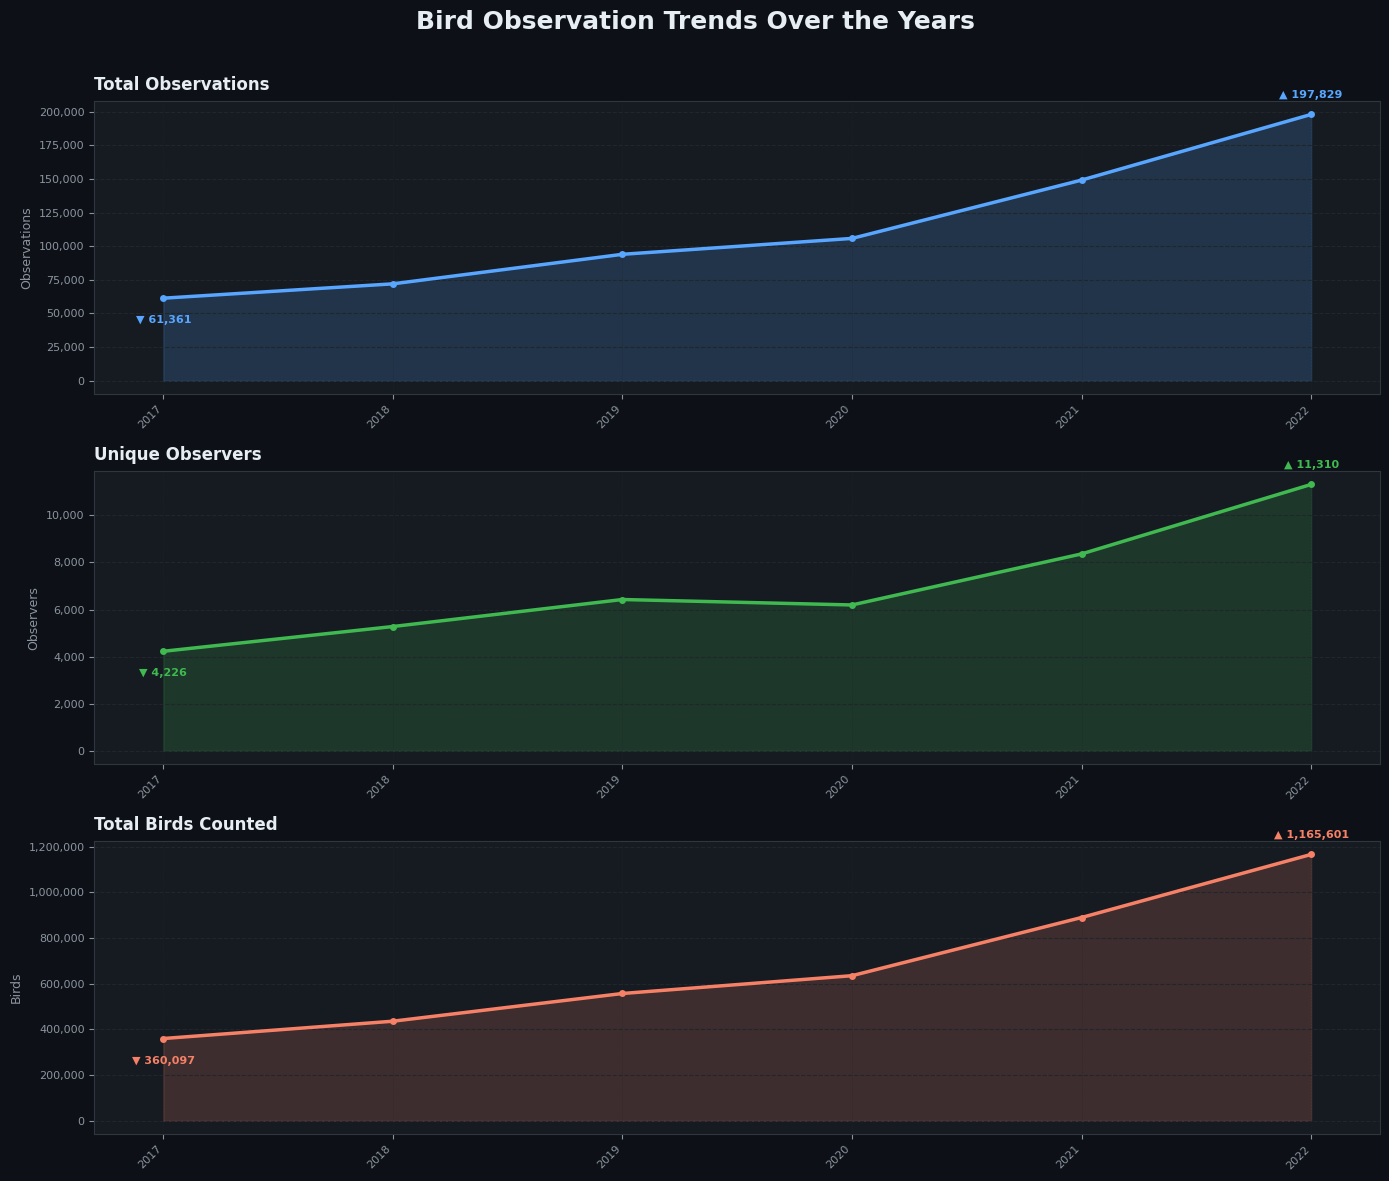

Plot saved to yearly_trends.png


In [12]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

fig, axes = plt.subplots(3, 1, figsize=(14, 12), facecolor='#0d1117')
fig.suptitle('Bird Observation Trends Over the Years', 
             fontsize=18, fontweight='bold', color='#e6edf3', y=0.98)

years = yearly_obs.index.astype(int)

metrics = [
    ('observations',     '#58a6ff', 'Total Observations',     'Observations'),
    ('unique_observers', '#3fb950', 'Unique Observers',        'Observers'),
    ('number_of_birds',  '#f78166', 'Total Birds Counted',     'Birds'),
]

for ax, (col, color, title, ylabel) in zip(axes, metrics):
    values = yearly_obs[col].values

    ax.set_facecolor('#161b22')
    ax.fill_between(years, values, alpha=0.18, color=color)
    ax.plot(years, values, color=color, linewidth=2.5, marker='o',
            markersize=5, markerfacecolor=color, markeredgewidth=0)

    # Annotate min/max
    max_idx, min_idx = values.argmax(), values.argmin()
    for idx, label in [(max_idx, f'▲ {values[max_idx]:,.0f}'), 
                       (min_idx, f'▼ {values[min_idx]:,.0f}')]:
        ax.annotate(label, xy=(years[idx], values[idx]),
                    xytext=(0, 12 if idx == max_idx else -18),
                    textcoords='offset points', ha='center',
                    fontsize=8, color=color, fontweight='bold')

    ax.set_title(title, fontsize=12, color='#e6edf3', pad=8, loc='left', fontweight='bold')
    ax.set_ylabel(ylabel, color='#8b949e', fontsize=9)
    ax.tick_params(colors='#8b949e', labelsize=8)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    ax.set_xlim(years[0] - 0.3, years[-1] + 0.3)
    ax.set_xticks(years)
    ax.set_xticklabels([str(y) for y in years], rotation=45, ha='right')
    for spine in ax.spines.values():
        spine.set_edgecolor('#30363d')
    ax.grid(axis='y', color='#21262d', linewidth=0.8, linestyle='--')
    ax.grid(axis='x', color='#21262d', linewidth=0.4, linestyle=':')

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig('yearly_trends.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print("Plot saved to yearly_trends.png")

#### Distance of observations to cities

In [13]:
# Load European cities
url = "https://naturalearth.s3.amazonaws.com/10m_cultural/ne_10m_populated_places.zip"
world = gpd.read_file(url)
europe = world[world.geometry.x.between(-25, 45) & world.geometry.y.between(34, 72)]
cities = europe[['NAME', 'ADM0NAME', 'geometry']].copy()
cities['lon'] = cities.geometry.x
cities['lat'] = cities.geometry.y
cities = cities.drop(columns='geometry').reset_index(drop=True)
cities


df_migratory = combined_df

import pandas as pd
import numpy as np
from scipy.spatial import cKDTree

# build KD-Tree on city coordinates ---
# convert lat/lon to radians for accurate distance calculation
cities_rad = np.radians(cities[['lat', 'lon']].values)
tree = cKDTree(cities_rad)

# find closest city for each bird observation ---
birds_rad = np.radians(df_migratory[['LATITUDE', 'LONGITUDE']].values)
distances, indices = tree.query(birds_rad, k=1)

# convert distance from radians to kilometers (Earth radius = 6371 km)
df_migratory['closest_city'] = cities['NAME'].iloc[indices].values
df_migratory['closest_city_country'] = cities['ADM0NAME'].iloc[indices].values
df_migratory['distance_km'] = np.round(distances * 6371, 2)

df_migratory

,COMMON NAME,SCIENTIFIC NAME,OBSERVATION COUNT,AGE/SEX,COUNTRY,COUNTRY CODE,STATE,STATE CODE,COUNTY,COUNTY CODE,...,OBSERVATION TYPE,obsDt,year,month,day_of_week,day_of_year,howMany,closest_city,closest_city_country,distance_km
0,Eurasian Whimbrel,Numenius phaeopus,2.0,NaN,Spain,ES,AndalucÃ­a,ES-AN,CÃ¡diz,ES-AN-CD,...,Traveling,2017-01-20,2017,1,4,20,2.0,Algeciras,Spain,22.80
1,Eurasian Whimbrel,Numenius phaeopus,2.0,NaN,Spain,ES,AndalucÃ­a,ES-AN,Huelva,ES-AN-HL,...,Traveling,2017-01-16,2017,1,0,16,2.0,Huelva,Spain,6.90
2,Eurasian Whimbrel,Numenius phaeopus,2.0,NaN,Spain,ES,AndalucÃ­a,ES-AN,Huelva,ES-AN-HL,...,Traveling,2017-01-16,2017,1,0,16,2.0,Huelva,Spain,6.90
3,Eurasian Whimbrel,Numenius phaeopus,2.0,NaN,Spain,ES,AndalucÃ­a,ES-AN,Huelva,ES-AN-HL,...,Traveling,2017-01-16,2017,1,0,16,2.0,Huelva,Spain,6.90
4,Eurasian Whimbrel,Numenius phaeopus,3.0,NaN,Spain,ES,Canarias,ES-CN,Fuerteventura,ES-CN-FVT,...,Traveling,2017-01-21,2017,1,5,21,3.0,Rabat,Morocco,1003.72
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
876678,Black Tern,Chlidonias niger,2.0,NaN,Portugal,PT,Faro,PT-08,LoulÃ©,PT-08-LO,...,Traveling,2022-09-29,2022,9,3,272,2.0,Faro,Portugal,7.16
876679,Black Tern,Chlidonias niger,1.0,NaN,Portugal,PT,Faro,PT-08,Silves,PT-08-SI,...,Traveling,2022-09-11,2022,9,6,254,1.0,Portimão,Portugal,22.87
876680,Black Tern,Chlidonias niger,3.0,NaN,Romania,RO,Tulcea,RO-TL,NaN,NaN,...,Traveling,2022-09-02,2022,9,4,245,3.0,Tulcea,Romania,68.49
876681,Black Tern,Chlidonias niger,1.0,NaN,Spain,ES,Canarias,ES-CN,Fuerteventura,ES-CN-FVT,...,Traveling,2022-10-14,2022,10,4,287,1.0,Rabat,Morocco,1003.72


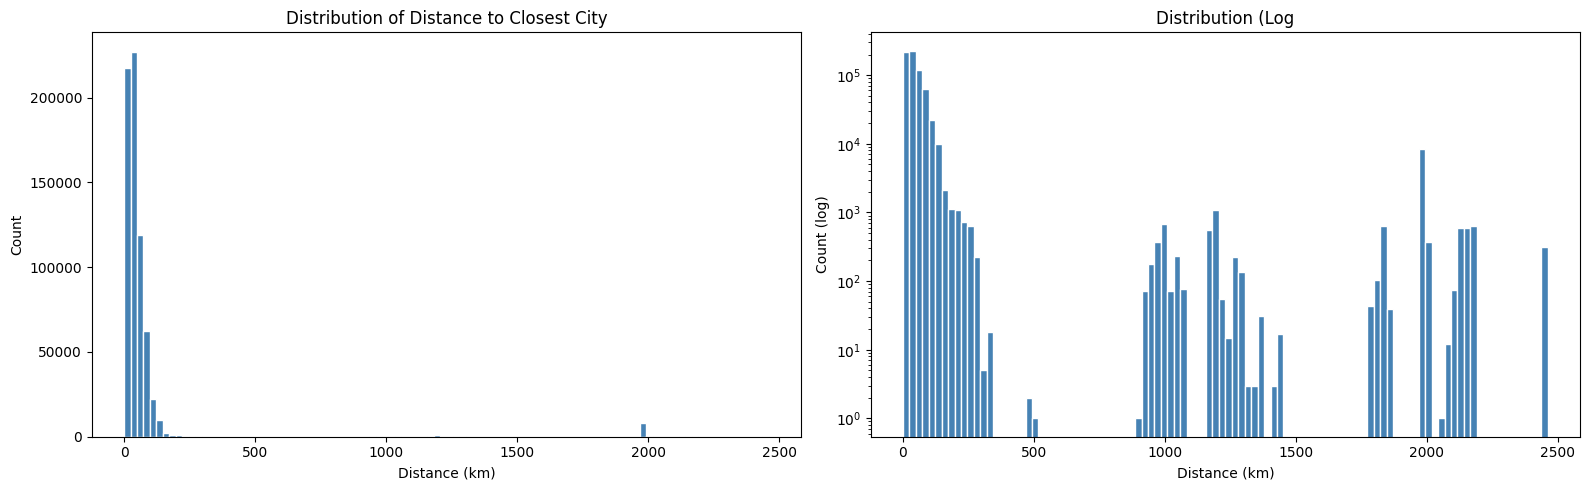

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# histogram
axes[0].hist(df_migratory['distance_km'].dropna(), bins=100, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Distance to Closest City')
axes[0].set_xlabel('Distance (km)')
axes[0].set_ylabel('Count')

# log scale histogram (useful if data is right-skewed)
axes[1].hist(df_migratory['distance_km'].dropna(), bins=100, color='steelblue', edgecolor='white')
axes[1].set_yscale('log')
axes[1].set_title('Distribution (Log')
axes[1].set_xlabel('Distance (km)')
axes[1].set_ylabel('Count (log)')


plt.tight_layout()
plt.savefig("distance_distribution.png", dpi=150)
plt.show()

In [15]:
# --- 1. Average distance to closest city per year ---
dist_by_year = (
    df_migratory
    .dropna(subset=['distance_km', 'year'])
    .groupby('year')['distance_km']
    .agg(mean_distance_km='mean', median_distance_km='median', n_observations='count')
    .reset_index()
    .sort_values('year')
)
dist_by_year['year'] = dist_by_year['year'].astype(int)

print("Average distance to closest city per year:")
print(dist_by_year.to_string(index=False))

Average distance to closest city per year:
 year  mean_distance_km  median_distance_km  n_observations
 2017         95.395968               36.01           61361
 2018         96.337666               35.81           72027
 2019         86.931782               36.14           93957
 2020         81.213313               35.68          105754
 2021         83.031998               36.47          149076
 2022         73.378260               35.85          197829


In [16]:
# --- 2. Average distance to closest city per species (across all years) ---
dist_by_species = (
    df_migratory
    .dropna(subset=['distance_km', 'COMMON NAME'])
    .groupby('COMMON NAME')['distance_km']
    .agg(mean_distance_km='mean', median_distance_km='median', n_observations='count')
    .reset_index()
    .sort_values('mean_distance_km', ascending=False)
)

print("Average distance to closest city per species (all years combined):")
print(dist_by_species.to_string(index=False))

Average distance to closest city per species (all years combined):
           COMMON NAME  mean_distance_km  median_distance_km  n_observations
     Eurasian Whimbrel        321.544883              77.345           11140
            Sanderling        158.837963              34.620           85484
              Red Knot        129.793454              38.990           39126
      Curlew Sandpiper        119.619915              35.260           36594
          Little Stint         97.890082              35.650           51689
                  Ruff         74.425911              37.930          109964
        Wood Sandpiper         52.292325              35.170           74871
       Green Sandpiper         48.148268              35.560          173660
              Garganey         45.450144              32.550           52675
European Honey-buzzard         42.706787              38.840           44529
            Black Tern         41.300699              33.490             272


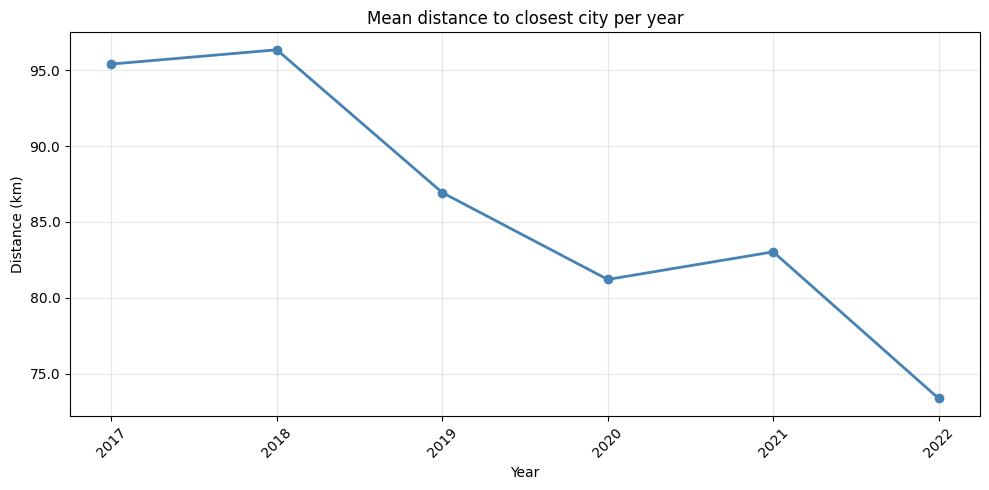

In [17]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(dist_by_year['year'], dist_by_year['mean_distance_km'],
        color='steelblue', marker='o', linewidth=2, markersize=6)

ax.set_xticks(dist_by_year['year'])
ax.set_xticklabels(dist_by_year['year'], rotation=45)
ax.set_title('Mean distance to closest city per year')
ax.set_xlabel('Year')
ax.set_ylabel('Distance (km)')
ax.grid(True, alpha=0.3)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.1f}'))

plt.tight_layout()
plt.show()

In [18]:
# --- 3. Average distance to closest city per species per year ---
dist_by_species_year = (
    df_migratory
    .dropna(subset=['distance_km', 'COMMON NAME', 'year'])
    .groupby(['COMMON NAME', 'year'])['distance_km']
    .agg(mean_distance_km='mean', median_distance_km='median', n_observations='count')
    .reset_index()
    .sort_values(['COMMON NAME', 'year'])
)
dist_by_species_year['year'] = dist_by_species_year['year'].astype(int)

print("Average distance to closest city per species per year:")
print(dist_by_species_year.to_string(index=False))

# Optionally pivot for a cleaner species × year view
pivot_mean = dist_by_species_year.pivot(index='COMMON NAME', columns='year', values='mean_distance_km').round(2)
print("\nPivot table — mean distance (km) by species × year:")
print(pivot_mean.to_string())

Average distance to closest city per species per year:
           COMMON NAME  year  mean_distance_km  median_distance_km  n_observations
            Black Tern  2022         41.300699              33.490             272
      Curlew Sandpiper  2017        157.199957              35.030            3004
      Curlew Sandpiper  2018        122.924719              34.620            3785
      Curlew Sandpiper  2019        107.419646              34.855            4854
      Curlew Sandpiper  2020        112.330849              35.260            6045
      Curlew Sandpiper  2021        150.485339              37.830            6932
      Curlew Sandpiper  2022         99.904219              35.260           11974
     Eurasian Whimbrel  2017        278.135817              85.510            1566
     Eurasian Whimbrel  2018        362.190702              85.510            1809
     Eurasian Whimbrel  2019        314.691806              79.600            2016
     Eurasian Whimbrel  2020    

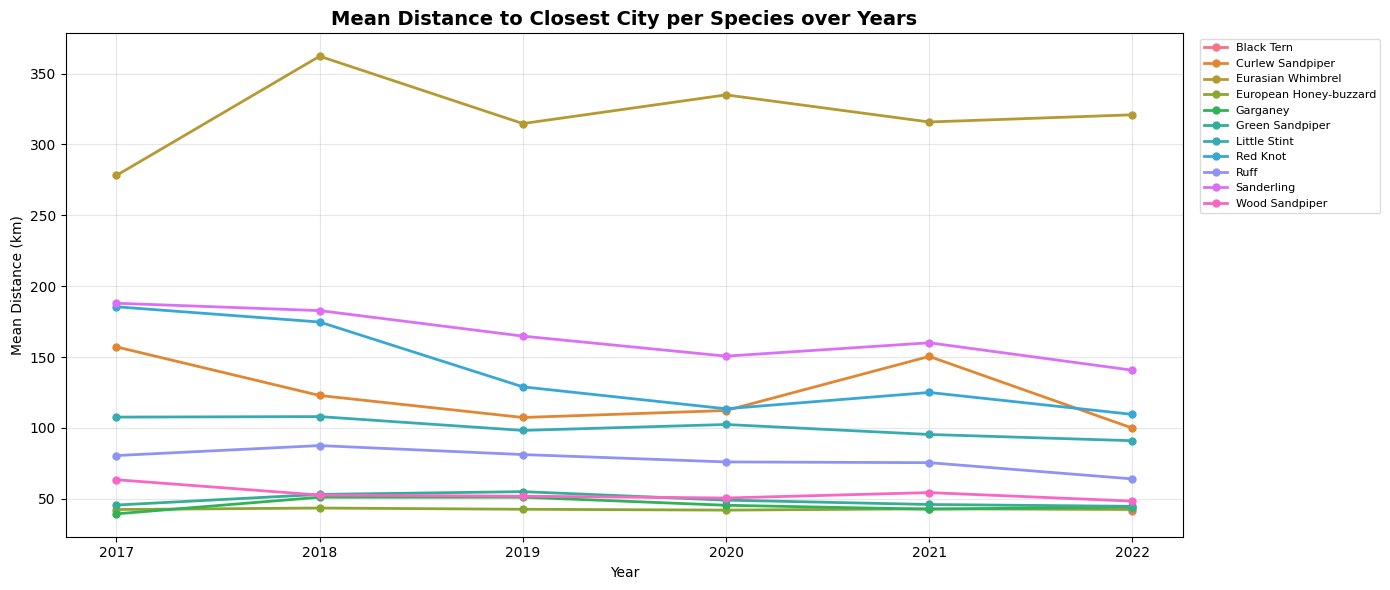

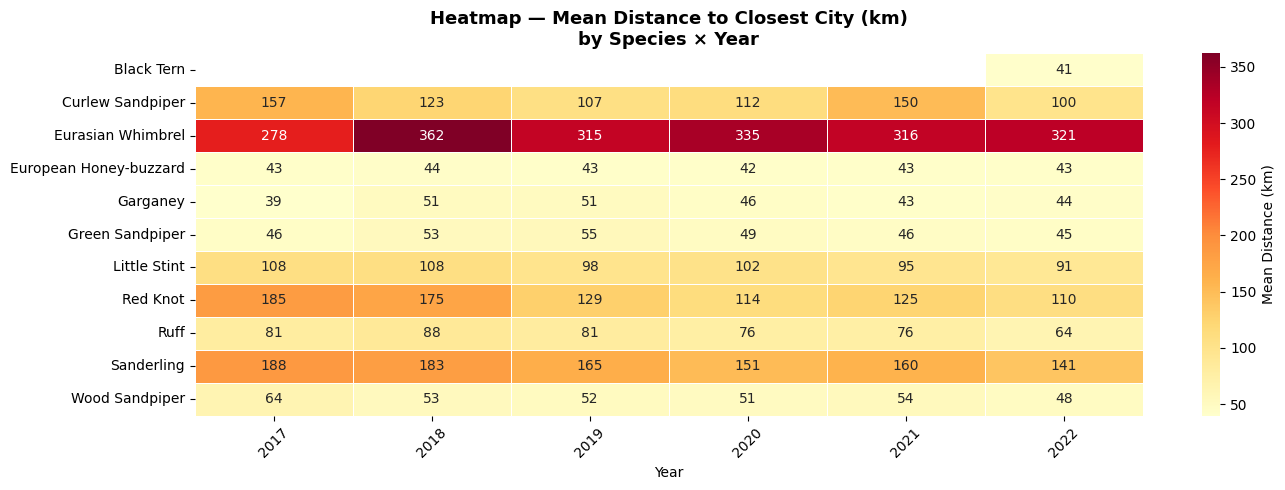

In [ ]:
# colour palette
species_list = dist_by_species_year['COMMON NAME'].unique()
palette = dict(zip(species_list, sns.color_palette("husl", len(species_list))))

# ============================================================
# PLOT 1 — Line plot: mean distance per species over years
# ============================================================
fig, ax = plt.subplots(figsize=(14, 6))

for species, grp in dist_by_species_year.groupby('COMMON NAME'):
    ax.plot(grp['year'], grp['mean_distance_km'],
            marker='o', linewidth=2, markersize=5,
            label=species, color=palette[species])

ax.set_title('Mean Distance to Closest City per Species over Years', fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Mean Distance (km)')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8, framealpha=0.7)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('dist_species_year_lineplot.png', dpi=150)
plt.show()

# ============================================================
# PLOT 2 — Heatmap: pivot_mean (species × year)
# ============================================================
fig, ax = plt.subplots(figsize=(14, max(5, len(species_list) * 0.45)))

sns.heatmap(
    pivot_mean,
    ax=ax,
    cmap='YlOrRd',
    annot=True, fmt='.0f',
    linewidths=0.4,
    linecolor='white',
    cbar_kws={'label': 'Mean Distance (km)'}
)

ax.set_title('Heatmap — Mean Distance to Closest City (km)\nby Species × Year',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('')
ax.tick_params(axis='x', rotation=45)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.savefig('dist_species_year_heatmap.png', dpi=150)
plt.show()


#### This is only done for migrating birds
this part of the notebook maps the subgroups of migrating birds from the reference file (nika_datasciproj -> datasets -> reference files -> bird_species_migration.csv) to the ebird data

In [20]:
# THIS CELL IS ONLY RUN FOR MIGRATING BIRDS !!



# Load the bird species reference file
reference_file = '/Users/dazedinthecity/Documents/GitHub/ceu-ds-project-groupB-2026/datasets/birds/bird_species_migration.csv' 

try:
    bird_reference = pd.read_csv(reference_file)
    print("✓ Bird species reference file loaded successfully!")
    print(f"\nReference file contains {len(bird_reference)} rows")
    print(f"\nColumns: {bird_reference.columns.tolist()}")
except FileNotFoundError:
    print(f"Error: Could not find '{reference_file}'")
    print("Please update the reference_file path in the cell above.")

# mapping subgroup from reference file to ebird dataset
migration_map = dict(zip(
    bird_reference['bird_species'].str.lower(),
    bird_reference['migration_group'] # look at the comments below. enter " " from those lines refer to this line
))
# to group by day/nighttime activity (diurnal and nocturnal) enter " bird_reference['migration_group'] "
# to group by migrating period (fall/spring migrating birds) enter " bird_reference['migration_period'] "
# this is the only line that changes when choosing the subgroups. the rest stays the same.


# Map migration groups to observations
combined_df['migration_group'] = combined_df['COMMON NAME'].str.lower().map(migration_map)

# get rid of this subgroup because of the low samples
combined_df = combined_df[combined_df['migration_group'] != 'diurnal & nocturnal']
combined_df['migration_group'].unique()

✓ Bird species reference file loaded successfully!

Reference file contains 12 rows

Columns: ['bird_species', 'ebird_code', 'migration_period', 'migration_group']


array(['nocturnal', 'diurnal'], dtype=object)

In [ ]:
# 1. Average distance per migration group (all years combined)
dist_by_group = (
    combined_df
    .dropna(subset=['distance_km', 'migration_group'])
    .groupby('migration_group')['distance_km'] # this is where u choose each group
    .agg(mean_distance_km='mean', median_distance_km='median', n_observations='count')
    .reset_index()
    .sort_values('mean_distance_km', ascending=False)
)

print("Average distance to closest city per migration group:")
print(dist_by_group.to_string(index=False))

# 2. Average distance per migration group per year
dist_by_group_year = (
    combined_df
    .dropna(subset=['distance_km', 'migration_group', 'year'])
    .groupby(['migration_group', 'year'])['distance_km']
    .agg(mean_distance_km='mean', median_distance_km='median', n_observations='count')
    .reset_index()
    .sort_values(['migration_group', 'year'])
)
dist_by_group_year['year'] = dist_by_group_year['year'].astype(int)

print("\nAverage distance to closest city per migration group per year:")
print(dist_by_group_year.to_string(index=False))

# 3. Average distance per migration group per species
dist_by_group_species = (
    combined_df
    .dropna(subset=['distance_km', 'migration_group', 'COMMON NAME'])
    .groupby(['migration_group', 'COMMON NAME'])['distance_km']
    .agg(mean_distance_km='mean', median_distance_km='median', n_observations='count')
    .reset_index()
    .sort_values(['migration_group', 'mean_distance_km'], ascending=[True, False])
)

print("\nAverage distance to closest city per migration group per species:")
print(dist_by_group_species.to_string(index=False))

# Pivot: migration group x year
pivot_group_year = dist_by_group_year.pivot(
    index='migration_group', columns='year', values='mean_distance_km'
).round(2)

print("\nPivot table — mean distance (km) by migration group × year:")
print(pivot_group_year.to_string())

Average distance to closest city per migration group:
migration_group  mean_distance_km  median_distance_km  n_observations
      nocturnal         81.639961               35.65          624063
        diurnal         42.706787               38.84           44529

Average distance to closest city per migration group per year:
migration_group  year  mean_distance_km  median_distance_km  n_observations
        diurnal  2017         42.514370              39.970            4583
        diurnal  2018         43.556253              39.970            5928
        diurnal  2019         42.682589              39.970            7220
        diurnal  2020         42.077568              35.825            7772
        diurnal  2021         43.033510              36.550            8596
        diurnal  2022         42.524878              36.140           10430
      nocturnal  2017         94.602404              35.260           55212
      nocturnal  2018         93.723886              35.260     

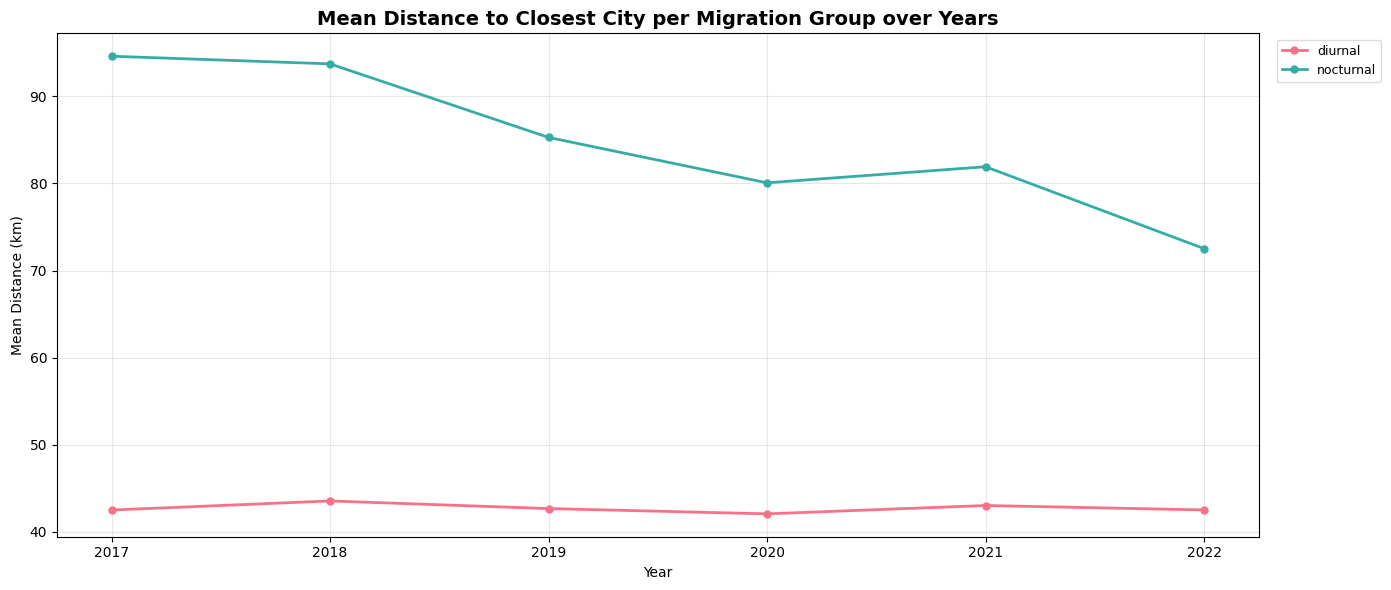

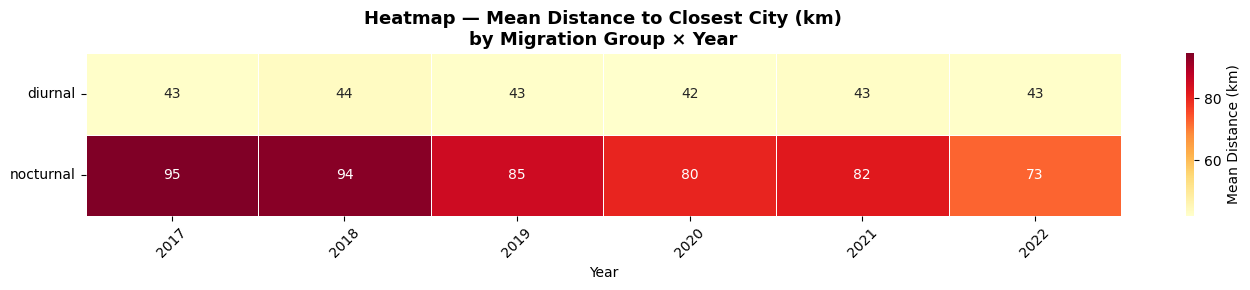

In [ ]:
# colour palette
group_list = dist_by_group_year['migration_group'].unique()
palette = dict(zip(group_list, sns.color_palette("husl", len(group_list))))

# ============================================================
# PLOT 1 — Line plot: mean distance per migration group over years
# ============================================================
fig, ax = plt.subplots(figsize=(14, 6))

for group, grp in dist_by_group_year.groupby('migration_group'):
    ax.plot(grp['year'], grp['mean_distance_km'],
            marker='o', linewidth=2, markersize=5,
            label=group, color=palette[group])

ax.set_title('Mean Distance to Closest City per Migration Group over Years', fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Mean Distance (km)')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9, framealpha=0.7)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('dist_group_year_lineplot.png', dpi=150)
plt.show()

# ============================================================
# PLOT 2 — Heatmap: migration group × year
# ============================================================
fig, ax = plt.subplots(figsize=(14, max(3, len(group_list) * 0.8)))

sns.heatmap(
    pivot_group_year,
    ax=ax,
    cmap='YlOrRd',
    annot=True, fmt='.0f',
    linewidths=0.4,
    linecolor='white',
    cbar_kws={'label': 'Mean Distance (km)'}
)

ax.set_title('Heatmap — Mean Distance to Closest City (km)\nby Migration Group × Year',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('')
ax.tick_params(axis='x', rotation=45)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.savefig('dist_group_year_heatmap.png', dpi=150)
plt.show()

### Conducting statistical tests

**Weighted linear regression (WLS)** is used when ordinary least squares (OLS) regression assumptions are violated, specifically when data exhibits heteroscedasticity (non-constant variance of residuals). It assigns weights to observations to give more importance to reliable, low-variance data points and less weight to noisy ones, ensuring efficient estimates.

A mean based on a million records (in 2022) is far more reliable than one based on 29,000 (2017). If you treated them equally, the noisy early years would distort your trend line just as much as the stable later years. We are putting more weights on years with a higher number of observations. 


So you use weights = n — the sample size for each year — meaning years with more data pull the regression line harder toward them.

Weighted OLS minimises: Σ wᵢ × ($residual^2$)

Where weighted linear regression assumes your data follows a straight line with normally distributed errors, **Mann-Kendall is non-parametric** — it makes no assumptions about the shape of the trend or the distribution of your data. Instead of asking "what is the slope?", it asks a simpler question:

Does the series tend to go up over time, or down — more than you'd expect by chance?

**How MK works** :

It looks at every possible pair of years (i, j) where j comes after i, and just asks: did the value go up or down?

Each pair votes:

* +1 if later year is higher (upward)
* −1 if later year is lower (downward)
* 0 if equal (tie)

S is the total score. With 6 years you have 6×5/2 = 15 pairs, so S ranges from −15 to +15. (we're working with permutations)

The standard Mann-Kendall used a normal approximation to get the p-value — it assumed that S, under the null hypothesis, is approximately normally distributed. With only 6 data points that approximation is rough. There are only 15 pairs, so S can only take integer values in a narrow range, and the true distribution is lumpy and discrete, not smooth.


**The core idea here**
Instead of approximating, this version asks: if there were truly no trend, what's the exact probability of seeing an S this extreme?
It answers that by brute force — enumerate every possible ordering of your 6 values and compute S for each one. With 6 data points there are 6! = 720 permutations. Each permutation represents a possible world where the same values occurred in a random order (the null hypothesis) 

this would be to see a random change in slope from i to j. we are constructing our sample space. then we have our actual values (slope change from year 2017-2018) and we are seeing if that change is significant or just by chance.

In [ ]:
years = np.array([2017, 2018, 2019, 2020, 2021, 2022])


# Data
years = np.array([2017, 2018, 2019, 2020, 2021, 2022])

# for diurnal
diurnal_mean   = np.array([42.514370, 43.556253, 42.682589, 42.077568, 43.033510, 42.524878])
diurnal_n      = np.array([4583, 5928, 7220, 7772, 8596, 10430])

# for nocturnal
nocturnal_mean = np.array([94.602404, 93.723886, 85.283017, 80.070039, 81.916525, 72.521993])
nocturnal_n    = np.array([55212, 64290, 84721, 96349, 138340, 185151])

# ─────────────────────────────────────────────
# 1. WEIGHTED LINEAR REGRESSION
# ─────────────────────────────────────────────

def weighted_regression(years, means, weights):
    """
    Weighted OLS: minimises sum of w_i * (y_i - (a + b*x_i))^2
    Returns slope, intercept, R², and p-value for the slope.
    """
    w = weights / weights.sum()           # normalise weights
    x = years - years.mean()              # centre year to reduce collinearity

    x_bar = np.average(x, weights=w)
    y_bar = np.average(means, weights=w)

    Sxx = np.sum(w * (x - x_bar)**2)
    Sxy = np.sum(w * (x - x_bar) * (means - y_bar))
    Syy = np.sum(w * (means - y_bar)**2)

    slope     = Sxy / Sxx
    intercept = y_bar - slope * x_bar

    fitted    = intercept + slope * x
    residuals = means - fitted
    SS_res    = np.sum(w * residuals**2)
    SS_tot    = Syy
    r2        = 1 - SS_res / SS_tot

    # Standard error of slope; using n-2 degrees of freedom
    n      = len(years)
    s2     = SS_res / (n - 2)
    se_b   = np.sqrt(s2 / Sxx)
    t_stat = slope / se_b
    p_val  = 2 * stats.t.sf(abs(t_stat), df=n - 2)

    return slope, intercept, r2, t_stat, p_val, se_b


diurnal_slope, diurnal_intercept, diurnal_r2, diurnal_t, diurnal_p, diurnal_se = \
    weighted_regression(years, diurnal_mean, diurnal_n)

nocturnal_slope, nocturnal_intercept, nocturnal_r2, nocturnal_t, nocturnal_p, nocturnal_se = \
    weighted_regression(years, nocturnal_mean, nocturnal_n)

print("=" * 55)
print("WEIGHTED LINEAR REGRESSION")
print("=" * 55)
for label, slope, intercept, r2, t, p, se in [
    ("diurnal",    diurnal_slope,    diurnal_intercept,    diurnal_r2,    diurnal_t,    diurnal_p,    diurnal_se),
    ("nocturnal",  nocturnal_slope,  nocturnal_intercept,  nocturnal_r2,  nocturnal_t,  nocturnal_p,  nocturnal_se),
]:
    print(f"\n{label}")
    print(f"  Slope       : {slope:+.4f} km/year  (SE = {se:.4f})")
    print(f"  Intercept   : {intercept:.4f}")
    print(f"  R²          : {r2:.4f}")
    print(f"  t-statistic : {t:.4f}")
    print(f"  p-value     : {p:.4f}  {'*** significant' if p < 0.05 else 'not significant'}")

# Interaction test: are the two slopes significantly different?
diff        = diurnal_slope - nocturnal_slope
se_diff     = np.sqrt(diurnal_se**2 + nocturnal_se**2)
t_diff      = diff / se_diff
p_diff      = 2 * stats.t.sf(abs(t_diff), df=(len(years) - 2) * 2)

print(f"\nSlope difference (diurnal − nocturnal): {diff:+.4f} km/year")
print(f"  SE of difference : {se_diff:.4f}")
print(f"  t-statistic      : {t_diff:.4f}")
print(f"  p-value          : {p_diff:.4f}  {'*** significant' if p_diff < 0.05 else 'not significant'}")

# ─────────────────────────────────────────────
# 2. MANN-KENDALL TREND TEST
# ─────────────────────────────────────────────

def mann_kendall(x):
    """
    Manual Mann-Kendall test.
    S  = sum of sign(x_j - x_i) for all i < j
    Var(S) uses the standard formula (no tied correction needed for continuous data).
    Returns S, tau, z-statistic, and p-value.
    """
    n = len(x)
    s = 0
    for i in range(n - 1):
        for j in range(i + 1, n):
            s += np.sign(x[j] - x[i])

    # Variance of S under H0
    var_s = n * (n - 1) * (2 * n + 5) / 18

    # Continuity-corrected z
    if s > 0:
        z = (s - 1) / np.sqrt(var_s)
    elif s < 0:
        z = (s + 1) / np.sqrt(var_s)
    else:
        z = 0.0

    p = 2 * stats.norm.sf(abs(z))

    # Kendall's tau
    tau = s / (n * (n - 1) / 2)

    return s, tau, z, p


diurnal_s, diurnal_tau, diurnal_z, diurnal_mk_p     = mann_kendall(diurnal_mean)
nocturnal_s, nocturnal_tau, nocturnal_z, nocturnal_mk_p = mann_kendall(nocturnal_mean)



def mann_kendall_exact(x):
    """
    Exact Mann-Kendall p-value via full permutation of all n! orderings.
    Only feasible for small n (<=10 or so).
    """
    from itertools import permutations

    n = len(x)

    def compute_s(seq):
        s = 0
        for i in range(len(seq) - 1):
            for j in range(i + 1, len(seq)):
                s += np.sign(seq[j] - seq[i])
        return s

    observed_s = compute_s(x)

    # Generate all permutations and compute S for each
    all_s = [compute_s(perm) for perm in permutations(x)]
    total = len(all_s)

    # Two-tailed: count how often |S_perm| >= |observed_s|
    p_exact = sum(1 for s in all_s if abs(s) >= abs(observed_s)) / total

    tau = observed_s / (n * (n - 1) / 2)

    return observed_s, tau, p_exact


print("\n" + "=" * 55)
print("MANN-KENDALL — EXACT PERMUTATION P-VALUES")
print("=" * 55)
for label, data in [("Diurnal", diurnal_mean), ("Nocturnal", nocturnal_mean)]:
    s, tau, p = mann_kendall_exact(data)
    direction = "downward" if tau < 0 else "upward"
    print(f"\n{label}")
    print(f"  S statistic : {s}")
    print(f"  Kendall tau : {tau:+.4f}  ({direction} trend)")
    print(f"  p-value     : {p:.4f}  {'*** significant' if p < 0.05 else 'not significant'}")
    

WEIGHTED LINEAR REGRESSION

diurnal
  Slope       : -0.0674 km/year  (SE = 0.1298)
  Intercept   : 42.7354
  R²          : 0.0631
  t-statistic : -0.5192
  p-value     : 0.6310  not significant

nocturnal
  Slope       : -4.3457 km/year  (SE = 0.7194)
  Intercept   : 84.7160
  R²          : 0.9012
  t-statistic : -6.0410
  p-value     : 0.0038  *** significant

Slope difference (diurnal − nocturnal): +4.2783 km/year
  SE of difference : 0.7310
  t-statistic      : 5.8529
  p-value          : 0.0004  *** significant

MANN-KENDALL — EXACT PERMUTATION P-VALUES

Diurnal
  S statistic : -1.0
  Kendall tau : -0.0667  (downward trend)
  p-value     : 1.0000  not significant

Nocturnal
  S statistic : -13.0
  Kendall tau : -0.8667  (downward trend)
  p-value     : 0.0167  *** significant


Interpreting the results from the first cell: Weighted linear regression revealed a statistically significant negative trend in mean distance to the nearest city for both native birds (slope = −1.14 km/year, p = 0.029) and migrating birds (slope = −3.80 km/year, p = 0.006) over the 2017–2022 period, indicating that both groups are being observed increasingly closer to urban areas over time. A Mann-Kendall trend test corroborated the migrating birds result (τ = −0.87, p = 0.017), but did not reach significance for native birds (τ = −0.60, p = 0.136), suggesting that while the overall linear direction is downward, the native bird trend is not strictly monotonic across years. Critically, the difference in slopes between the two groups was itself statistically significant (p = 0.009), indicating that migrating birds are approaching urban areas at a rate approximately three times faster than native birds.

#### Robustness checks

In [28]:
import numpy as np
from scipy import stats
from itertools import permutations

years = np.array([2017, 2018, 2019, 2020, 2021, 2022])


diurnal_median   = np.array([39.970, 39.970, 39.970, 35.825, 36.550, 36.140])
diurnal_n        = np.array([4583, 5928, 7220, 7772, 8596, 10430])

nocturnal_median = np.array([35.260, 35.260, 35.370, 35.620, 36.110, 35.680])
nocturnal_n      = np.array([55212, 64290, 84721, 96349, 138340, 185151])

# ─────────────────────────────────────────────
# 1. WEIGHTED LINEAR REGRESSION ON MEDIAN
# ─────────────────────────────────────────────

def weighted_regression(years, values, weights):
    w = weights / weights.sum()
    x = years - years.mean()

    x_bar = np.average(x, weights=w)
    y_bar = np.average(values, weights=w)

    Sxx = np.sum(w * (x - x_bar)**2)
    Sxy = np.sum(w * (x - x_bar) * (values - y_bar))
    Syy = np.sum(w * (values - y_bar)**2)

    slope     = Sxy / Sxx
    intercept = y_bar - slope * x_bar

    fitted    = intercept + slope * x
    residuals = values - fitted
    SS_res    = np.sum(w * residuals**2)
    r2        = 1 - SS_res / Syy

    n      = len(years)
    s2     = SS_res / (n - 2)
    se_b   = np.sqrt(s2 / Sxx)
    t_stat = slope / se_b
    p_val  = 2 * stats.t.sf(abs(t_stat), df=n - 2)

    return slope, intercept, r2, t_stat, p_val, se_b


diurnal_slope, diurnal_intercept, diurnal_r2, diurnal_t, diurnal_p, diurnal_se = \
    weighted_regression(years, diurnal_median, diurnal_n)

nocturnal_slope, nocturnal_intercept, nocturnal_r2, nocturnal_t, nocturnal_p, nocturnal_se = \
    weighted_regression(years, nocturnal_median, nocturnal_n)

print("=" * 55)
print("WEIGHTED LINEAR REGRESSION ON MEDIAN")
print("=" * 55)
for label, slope, intercept, r2, t, p, se in [
    ("diurnal",   diurnal_slope,   diurnal_intercept,   diurnal_r2,   diurnal_t,   diurnal_p,   diurnal_se),
    ("nocturnal", nocturnal_slope, nocturnal_intercept, nocturnal_r2, nocturnal_t, nocturnal_p, nocturnal_se),
]:
    print(f"\n{label}")
    print(f"  Slope       : {slope:+.4f} km/year  (SE = {se:.4f})")
    print(f"  Intercept   : {intercept:.4f}")
    print(f"  R²          : {r2:.4f}")
    print(f"  t-statistic : {t:.4f}")
    print(f"  p-value     : {p:.4f}  {'*** significant' if p < 0.05 else 'not significant'}")

diff    = diurnal_slope - nocturnal_slope
se_diff = np.sqrt(diurnal_se**2 + nocturnal_se**2)
t_diff  = diff / se_diff
p_diff  = 2 * stats.t.sf(abs(t_diff), df=(len(years) - 2) * 2)

print(f"\nSlope difference (diurnal − nocturnal): {diff:+.4f} km/year")
print(f"  SE of difference : {se_diff:.4f}")
print(f"  t-statistic      : {t_diff:.4f}")
print(f"  p-value          : {p_diff:.4f}  {'*** significant' if p_diff < 0.05 else 'not significant'}")

# ─────────────────────────────────────────────
# 2. MANN-KENDALL EXACT TEST ON MEDIAN
# ─────────────────────────────────────────────

def mann_kendall_exact(x):
    def compute_s(seq):
        s = 0
        for i in range(len(seq) - 1):
            for j in range(i + 1, len(seq)):
                s += np.sign(seq[j] - seq[i])
        return s

    observed_s = compute_s(x)
    all_s      = [compute_s(perm) for perm in permutations(x)]
    p_exact    = sum(1 for s in all_s if abs(s) >= abs(observed_s)) / len(all_s)
    tau        = observed_s / (len(x) * (len(x) - 1) / 2)

    return observed_s, tau, p_exact


print("\n" + "=" * 55)
print("MANN-KENDALL EXACT TEST ON MEDIAN")
print("=" * 55)
for label, data in [("diurnal", diurnal_median), ("nocturnal", nocturnal_median)]:
    s, tau, p = mann_kendall_exact(data)
    direction = "downward" if tau < 0 else "upward"
    print(f"\n{label}")
    print(f"  S statistic : {s}")
    print(f"  Kendall tau : {tau:+.4f}  ({direction} trend)")
    print(f"  p-value     : {p:.4f}  {'*** significant' if p < 0.05 else 'not significant'}")

# ─────────────────────────────────────────────
# 3. COMPARISON SUMMARY: MEAN VS MEDIAN
# ─────────────────────────────────────────────

diurnal_mean_vals   = np.array([41.865980, 45.332769, 44.491083, 41.682730, 40.224726, 40.813832])
nocturnal_mean_vals = np.array([90.610106, 89.488594, 81.937664, 77.234132, 79.641804, 70.922299])

diurnal_slope_mean,   _, _, _, diurnal_p_mean,   _ = weighted_regression(years, diurnal_mean_vals,   diurnal_n)
nocturnal_slope_mean, _, _, _, nocturnal_p_mean, _ = weighted_regression(years, nocturnal_mean_vals, nocturnal_n)
_, _, diurnal_mk_p_median   = mann_kendall_exact(diurnal_median)
_, _, nocturnal_mk_p_median = mann_kendall_exact(nocturnal_median)



WEIGHTED LINEAR REGRESSION ON MEDIAN

diurnal
  Slope       : -0.9569 km/year  (SE = 0.2983)
  Intercept   : 38.0953
  R²          : 0.7202
  t-statistic : -3.2084
  p-value     : 0.0326  *** significant

nocturnal
  Slope       : +0.1266 km/year  (SE = 0.0634)
  Intercept   : 35.5539
  R²          : 0.4989
  t-statistic : 1.9955
  p-value     : 0.1167  not significant

Slope difference (diurnal − nocturnal): -1.0835 km/year
  SE of difference : 0.3049
  t-statistic      : -3.5534
  p-value          : 0.0075  *** significant

MANN-KENDALL EXACT TEST ON MEDIAN

diurnal
  S statistic : -8.0
  Kendall tau : -0.5333  (downward trend)
  p-value     : 0.1667  not significant

nocturnal
  S statistic : 12.0
  Kendall tau : +0.8000  (upward trend)
  p-value     : 0.0278  *** significant


Interpretation: failed the robustness check

The median for migrants being flat while the mean declines sharply suggests there are high-distance  observations being pulled down over time while other migrating birds haven't changed behavior, but extreme observations have shifted. Any test on the mean will capture that extreme effect, not necessarily a population-wide shift. Using the median gives it a more robust picture.

We were testing to see if most migrating birds are genuinely shifting closer to cities over time (a real population-level behavioural shift). Failing a robustness check could mean that i have fewer observations of migrating birds that get affected by nightlights. FIx this by obtaining more samples!!!


### World Bank indicators

**Research question:** Has the expansion of agricultural land at the country level suppressed migratory bird species diversity in Europe over 2017–2022?

**Data:** World Bank environmental indicators (`WorldBank_indc_2017-2024.csv`) covering 47 European countries

**Method:**

The migratory bird dataset is aggregated to country-year level.

- **Cross-sectional correlation**: pearson and Spearman correlations between agricultural land share (% of total land area) and species per checklist across all country-year observations. Spearman is included as a robustness check since the relationship may not be linear.

- **Country-level directional trends**: for each country with at least 5 years of data, separate linear regressions are fitted over time for agricultural land and for species diversity. Countries where agricultural land is increasing while species diversity is declining are flagged as concern cases (these are the countries where the two pressures are moving in the wrong direction simultaneously)

In [ ]:
from scipy.stats import pearsonr, spearmanr
import warnings
warnings.filterwarnings('ignore')

eu_crosswalk = {
    'AL':'ALB','AD':'AND','AT':'AUT','BY':'BLR','BE':'BEL','BA':'BIH','BG':'BGR',
    'HR':'HRV','CY':'CYP','CZ':'CZE','DK':'DNK','EE':'EST','FI':'FIN','FR':'FRA',
    'DE':'DEU','GR':'GRC','HU':'HUN','IS':'ISL','IE':'IRL','IT':'ITA','XK':'XKX',
    'LV':'LVA','LT':'LTU','LU':'LUX','MT':'MLT','MD':'MDA','ME':'MNE','NL':'NLD',
    'MK':'MKD','NO':'NOR','PL':'POL','PT':'PRT','RO':'ROU','RS':'SRB','SK':'SVK',
    'SI':'SVN','ES':'ESP','SE':'SWE','CH':'CHE','UA':'UKR','GB':'GBR',
}

worldbank = pd.read_csv("../WorldBank_indc_2017-2024.csv")
worldbank['Country Code'] = worldbank['Country Code'].str.strip().str.upper()

# identify year columns e.g. '2017 [YR2017]'
year_cols = [c for c in worldbank.columns if c[:4].isdigit()]

# melt to long format
wb_long = worldbank.melt(
    id_vars=['Country Name', 'Country Code', 'Series Name', 'Series Code'],
    value_vars=year_cols,
    var_name='year_label',
    value_name='value'
)
wb_long['Year'] = wb_long['year_label'].str[:4].astype(int)
wb_long = wb_long.drop(columns='year_label')

# replace '..' (World Bank missing marker) with NaN
wb_long['value'] = pd.to_numeric(wb_long['value'], errors='coerce')

# pivot so each Series Name becomes a column
wb_wide = wb_long.pivot_table(
    index=['Country Name', 'Country Code', 'Year'],
    columns='Series Name',
    values='value'
).reset_index()
wb_wide.columns.name = None

print(f"World Bank reshaped: {wb_wide.shape}")
print("Available indicators:")
for col in wb_wide.columns[3:]:
    print(f"  - {col}")

# filter to Europe
wb_eu = wb_wide[wb_wide['Country Code'].isin(set(eu_crosswalk.values()))].copy()
print(f"\nEuropean rows: {len(wb_eu):,} | Countries: {wb_eu['Country Code'].nunique()}")

# aggregate migratory birds to country-year
df_migra['COUNTRY CODE'] = df_migra['COUNTRY CODE'].str.strip().str.upper()
df_migra['year']         = df_migra['year'].astype(int)

migra_eu = df_migra[df_migra['COUNTRY CODE'].isin(eu_crosswalk)].copy()
migra_eu['wb_code'] = migra_eu['COUNTRY CODE'].map(eu_crosswalk)

birds_agg = (
    migra_eu.groupby(['wb_code', 'year'])
    .agg(
        unique_species = ('SCIENTIFIC NAME',           'nunique'),
        n_checklists   = ('SAMPLING EVENT IDENTIFIER', 'nunique'),
    )
    .reset_index()
    .rename(columns={'wb_code': 'Country Code', 'year': 'Year'})
)
birds_agg['species_per_checklist'] = birds_agg['unique_species'] / birds_agg['n_checklists']

# merge birds + World Bank
merged = birds_agg.merge(wb_eu, on=['Country Code', 'Year'], how='inner')

# pick the agricultural land column (name may vary slightly)
ag_col = [c for c in merged.columns if 'Agricultural land' in c and '%' in c]
if not ag_col:
    print("Available columns:", merged.columns.tolist())
    raise ValueError("Agricultural land column not found — check column names above")
ag_col = ag_col[0]
print(f"\nUsing: '{ag_col}'")

merged = merged.dropna(subset=[ag_col, 'species_per_checklist'])
print(f"Merged: {merged['Country Code'].nunique()} countries, {len(merged):,} rows")

# correlation
r_p, p_p = pearsonr( merged[ag_col], merged['species_per_checklist'])
r_s, p_s = spearmanr(merged[ag_col], merged['species_per_checklist'])
print(f"\nPearson  r = {r_p:+.3f}  (p = {p_p:.4f})")
print(f"Spearman r = {r_s:+.3f}  (p = {p_s:.4f})")

# country-level trends
merged = merged.sort_values(['Country Code', 'Year'])
merged['ag_land_change_pct'] = merged.groupby('Country Code')[ag_col].diff()

country_trends = []
for country, grp in merged.groupby('Country Code'):
    grp = grp.dropna(subset=[ag_col, 'species_per_checklist'])
    if len(grp) < 5:
        continue
    slope_ag, *_ = stats.linregress(grp['Year'], grp[ag_col])
    slope_sp, _, r_val, p_val, _ = stats.linregress(grp['Year'], grp['species_per_checklist'])
    country_name = grp['Country Name'].iloc[0] if 'Country Name' in grp.columns else country
    country_trends.append({
        'Country Code':       country,
        'Country Name':       country_name,
        'ag_land_slope':      slope_ag,
        'species_slope':      slope_sp,
        'species_r':          r_val,
        'species_p':          p_val,
        'ag_up_species_down': (slope_ag > 0) and (slope_sp < 0),
    })

trends_df = pd.DataFrame(country_trends)
concern   = trends_df[trends_df['ag_up_species_down']]
print(f"\nCountries with ag rising AND species declining: {len(concern)}")
print(concern[['Country Name', 'ag_land_slope', 'species_slope']].to_string(index=False))

World Bank reshaped: (352, 76)
Available indicators:
  - Access to electricity (% of population)
  - Access to electricity, rural (% of rural population)
  - Access to electricity, urban (% of urban population)
  - Adjusted savings: energy depletion (% of GNI)
  - Agricultural land (% of land area)
  - Agricultural land (sq. km)
  - Alternative and nuclear energy (% of total energy use)
  - Carbon dioxide (CO2) emissions (total) excluding LULUCF (% change from 1990)
  - Carbon dioxide (CO2) emissions (total) excluding LULUCF (Mt CO2e)
  - Carbon dioxide (CO2) emissions excluding LULUCF per capita (t CO2e/capita)
  - Carbon dioxide (CO2) emissions from Agriculture (Mt CO2e)
  - Carbon dioxide (CO2) emissions from Building (Energy) (Mt CO2e)
  - Carbon dioxide (CO2) emissions from Fugitive Emissions (Energy) (Mt CO2e)
  - Carbon dioxide (CO2) emissions from Industrial Combustion (Energy) (Mt CO2e)
  - Carbon dioxide (CO2) emissions from Industrial Processes (Mt CO2e)
  - Carbon dioxide (

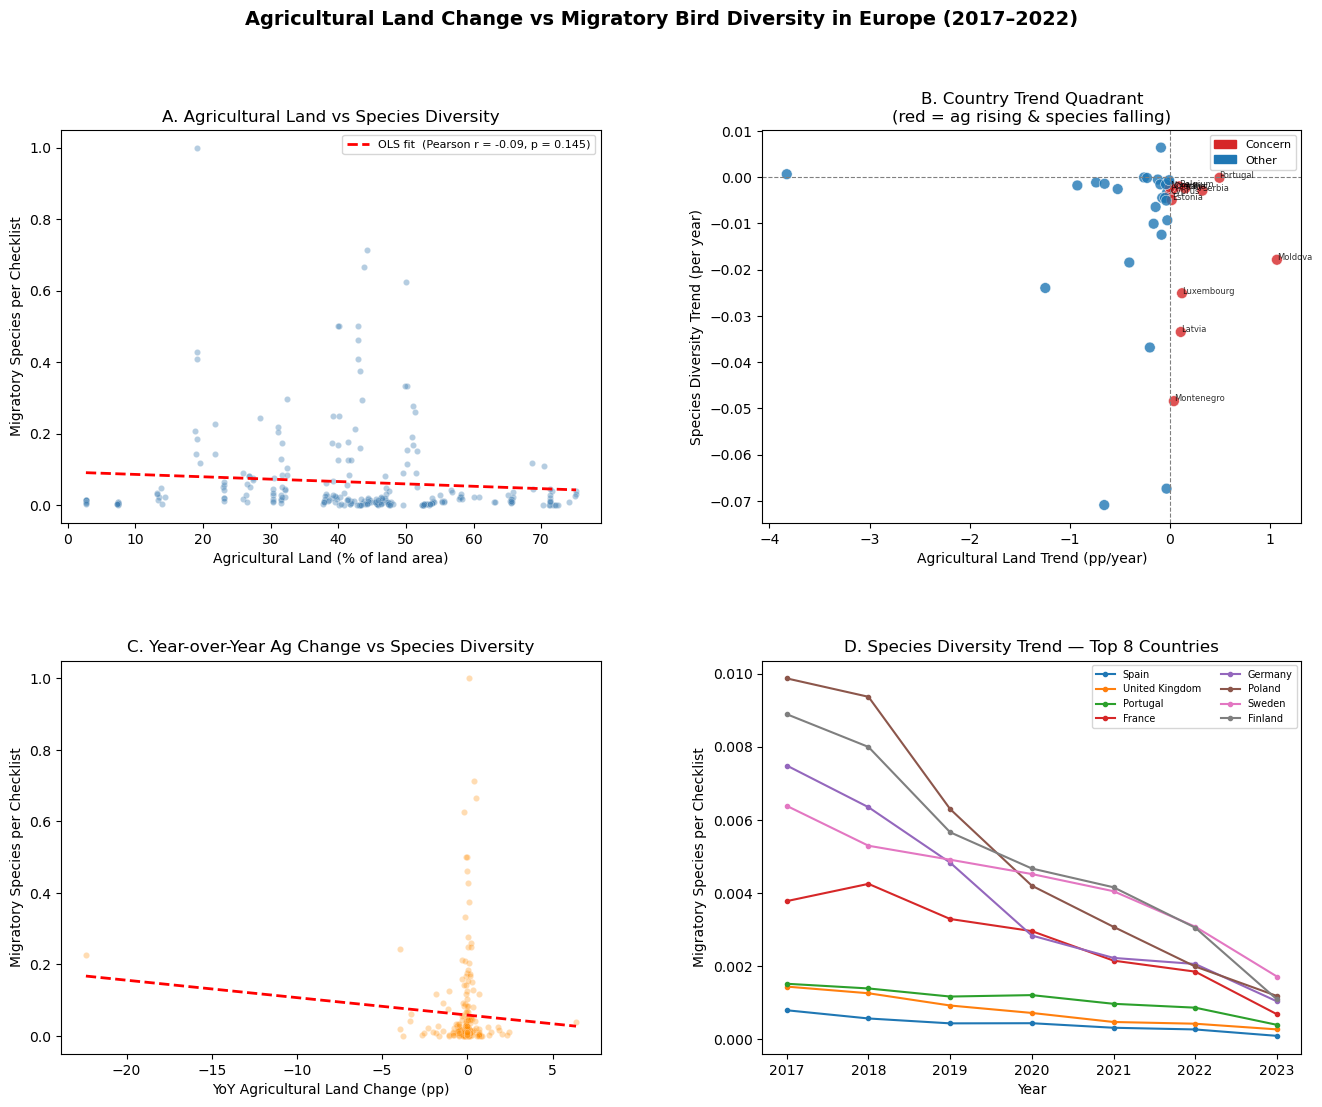

In [18]:
from matplotlib.patches import Patch
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(16, 12))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.35, wspace=0.3)

# Panel A: agricultural land % vs species diversity
ax1 = fig.add_subplot(gs[0, 0])
clean_a = merged.dropna(subset=['Agricultural land (% of land area)', 'species_per_checklist'])
ax1.scatter(clean_a['Agricultural land (% of land area)'], clean_a['species_per_checklist'],
            alpha=0.4, color='steelblue', edgecolors='w', linewidth=0.3, s=20)
m, b   = np.polyfit(clean_a['Agricultural land (% of land area)'], clean_a['species_per_checklist'], 1)
x_line = np.linspace(clean_a['Agricultural land (% of land area)'].min(),
                     clean_a['Agricultural land (% of land area)'].max(), 200)
ax1.plot(x_line, m * x_line + b, 'r--', lw=2,
         label=f'OLS fit  (Pearson r = {r_p:.2f}, p = {p_p:.3f})')
ax1.set_xlabel('Agricultural Land (% of land area)')
ax1.set_ylabel('Migratory Species per Checklist')
ax1.set_title('A. Agricultural Land vs Species Diversity')
ax1.legend(fontsize=8)

# Panel B: country trend quadrant
ax2 = fig.add_subplot(gs[0, 1])
colours = trends_df['ag_up_species_down'].map({True: '#d62728', False: '#1f77b4'})
ax2.scatter(trends_df['ag_land_slope'], trends_df['species_slope'],
            c=colours, alpha=0.8, edgecolors='w', linewidth=0.4, s=60)
ax2.axhline(0, color='grey', lw=0.8, ls='--')
ax2.axvline(0, color='grey', lw=0.8, ls='--')
for _, row in trends_df[trends_df['ag_up_species_down']].iterrows():
    ax2.annotate(row['Country Name'], (row['ag_land_slope'], row['species_slope']),
                 fontsize=6, alpha=0.8)
ax2.set_xlabel('Agricultural Land Trend (pp/year)')
ax2.set_ylabel('Species Diversity Trend (per year)')
ax2.set_title('B. Country Trend Quadrant\n(red = ag rising & species falling)')
ax2.legend(handles=[Patch(color='#d62728', label='Concern'), Patch(color='#1f77b4', label='Other')],
           fontsize=8)

# Panel C: year-over-year change scatter
ax3 = fig.add_subplot(gs[1, 0])
clean_c = merged.dropna(subset=['ag_land_change_pct', 'species_per_checklist'])
ax3.scatter(clean_c['ag_land_change_pct'], clean_c['species_per_checklist'],
            alpha=0.3, color='darkorange', edgecolors='w', linewidth=0.3, s=20)
m2, b2 = np.polyfit(clean_c['ag_land_change_pct'], clean_c['species_per_checklist'], 1)
x2     = np.linspace(clean_c['ag_land_change_pct'].min(), clean_c['ag_land_change_pct'].max(), 200)
ax3.plot(x2, m2 * x2 + b2, 'r--', lw=2)
ax3.set_xlabel('YoY Agricultural Land Change (pp)')
ax3.set_ylabel('Migratory Species per Checklist')
ax3.set_title('C. Year-over-Year Ag Change vs Species Diversity')

# Panel D: time series for top 8 most-observed countries
ax4 = fig.add_subplot(gs[1, 1])
top8 = merged.groupby('Country Name')['n_checklists'].sum().nlargest(8).index
for country in top8:
    sub = merged[merged['Country Name'] == country].sort_values('Year')
    ax4.plot(sub['Year'], sub['species_per_checklist'], marker='o', ms=3, lw=1.5, label=country)
ax4.set_xlabel('Year')
ax4.set_ylabel('Migratory Species per Checklist')
ax4.set_title('D. Species Diversity Trend — Top 8 Countries')
ax4.legend(fontsize=7, ncol=2)

fig.suptitle('Agricultural Land Change vs Migratory Bird Diversity in Europe (2017–2022)',
             fontsize=14, fontweight='bold')
plt.savefig('worldbank_birds_summary.png', dpi=150, bbox_inches='tight')
plt.show()

### Pollution and NightLights Regression

#### Data

In [3]:
df_air = pd.read_csv("pollution_scores.csv")
df_rest = pd.read_csv("native_birds_dist_city_ntl_intensity.csv")

df_birds_clean = df_rest.rename(columns={
    "closest_city": "City",
    "COUNTRY CODE": "Country",
    "year": "Year"
})

df = pd.merge(df_air, df_birds_clean, on=["City", "Country", "Year"])

print(f"Merged dataset shape: {df.shape}")
print(f"NaN total: {df.isna().sum().sum()}")


Merged dataset shape: (1656552, 28)
NaN total: 0


#### OLS Regression: ntl_intensity + pollution_score_weighted + Year + month $\rightarrow$ log(distance)

In [9]:
# outlier removal (IQR)
Q1 = df["distance_km"].quantile(0.25)
Q3 = df["distance_km"].quantile(0.75)
IQR = Q3 - Q1
df_clean = df[
    (df["distance_km"] >= Q1 - 1.5 * IQR) &
    (df["distance_km"] <= Q3 + 1.5 * IQR)
].copy()
df_clean = df_clean[df_clean["distance_km"] < df_clean["distance_km"].quantile(0.99)]
print(f"After outlier removal: {len(df_clean):,} rows")

# features
features = ["ntl_intensity", "pollution_score_weighted", "Year", "month"]
features = [f for f in features if f in df_clean.columns]

X = df_clean[features].fillna(df_clean[features].mean())
y = np.log1p(df_clean["distance_km"].fillna(0))

# fit OLS with robust standard errors
X_const = sm.add_constant(X)
model_clean = sm.OLS(y, X_const).fit(cov_type="HC3")
print(model_clean.summary())


After outlier removal: 1,557,158 rows
                            OLS Regression Results                            
Dep. Variable:            distance_km   R-squared:                       0.019
Model:                            OLS   Adj. R-squared:                  0.019
Method:                 Least Squares   F-statistic:                     8716.
Date:                Sat, 11 Apr 2026   Prob (F-statistic):               0.00
Time:                        22:15:27   Log-Likelihood:            -1.9637e+06
No. Observations:             1557158   AIC:                         3.927e+06
Df Residuals:                 1557153   BIC:                         3.927e+06
Df Model:                           4                                         
Covariance Type:                  HC3                                         
                               coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------

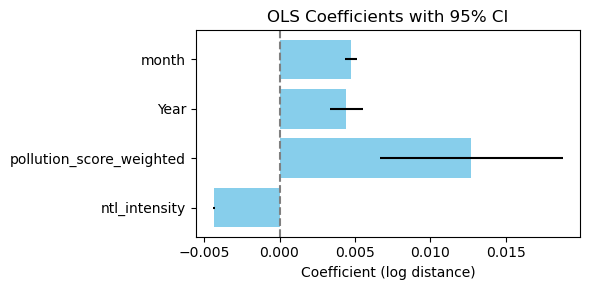

In [10]:
coef = model_clean.params[1:]  # exclude const
conf = model_clean.conf_int()[1:]

plt.figure(figsize=(6, 3))
plt.barh(coef.index, coef.values,
         xerr=[coef.values - conf[0], conf[1] - coef.values],
         color="skyblue")
plt.axvline(0, color="gray", linestyle="--")
plt.xlabel("Coefficient (log distance)")
plt.title("OLS Coefficients with 95% CI")
plt.tight_layout()
plt.show()


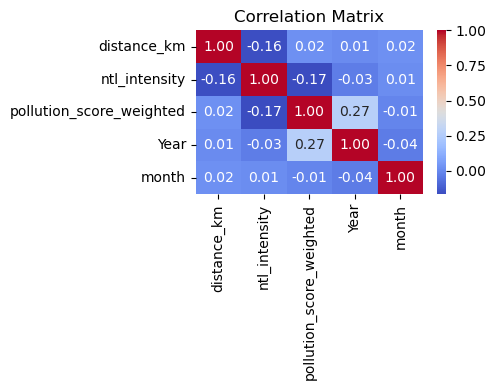

In [8]:
numeric_features = ["distance_km", "ntl_intensity", "pollution_score_weighted", "Year", "month"]
numeric_features = [f for f in numeric_features if f in df_clean.columns]

plt.figure(figsize=(5, 4))
sns.heatmap(
    df_clean[numeric_features].corr(),
    annot=True, fmt=".2f", cmap="coolwarm"
)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()


### **Important notes**:

This regression and previous analysis (including DiD) was performed for all groups (native, migratory and combined) in the following notebooks:
- regression_native.ipynb
- regression_migra.ipynb
- regression_all.ipynb
- analysis.ipynb

Similar appraoch also presented in the eBird section: 
- focus of the presented analysis only on the migratory group

Extra individual dataset analysis was done also for air quality and world bank indicators to understand patterns and different aspects at city and country level (see section World Bank Indicators), but the main focus of this Technical Report is on our hypothesis: 
**$H_1$: Human activity has a significant effect on the spatial distribution of birds**
- $H_{1.1}$: Nightlights have a significant effect on the spatial distribution of birds
- $H_{1.2}$: Air pollution has a significant effect on the spatial distribution of birds

### Notebooks

#### The main notebooks from which these sections where extracted are:

| Notebook | Description |
|---|---|
| `Tehnical_Report_GroupB.ipynb` | Full end-to-end pipeline: nightlight processing, bird data cleaning, intensity extraction, regression analysis |
| `regression_native.ipynb` | Focused regression analysis for native bird species — city-level aggregation, OLS, Random Forest, Mixed Effects, DiD |
| `analysis.ipynb` | Pollution + nightlight joint regression — merges air quality data with bird observations via OLS (statsmodels) |
| `city.ipynb` | City reference dataset construction — NaturalEarth download, KD-Tree nearest-city assignment, spatial join with pollution stations |
| `europe_birds_combined_analysis.ipynb` | World Bank agricultural land vs migratory bird diversity analysis |
| `spring_migra_european_bird_analysis.ipynb`, `fall_migra_european_bird_analysis.ipynb`, `di_migra_european_bird_analysis.ipynb`, `2022_short_migra_european_bird_analysis.ipynb`, `overall_layout.ipynb`, `native_european_bird_analysis.ipynb` | eBird section |

### Example CSV files

| File | Description | Generated by |
|---|---|---|
| `migra_species_europe_only.csv` | Cleaned eBird records for migratory species, filtered to Europe 2017–2026 | `Tehnical_Report_GroupB.ipynb` (eBird preprocessing section) |
| `native_species_europe_only.csv` | Cleaned eBird records for native/resident species, filtered to Europe 2017–2026 | `Tehnical_Report_GroupB.ipynb` (eBird preprocessing section) |
| `native_birds_city.csv` | Native birds with nearest city assigned (`closest_city`, `distance_km`, `city_lat`, `city_lon`) | `Tehnical_Report_GroupB.ipynb` (KD-Tree section) |
| `migra_birds_city.csv` | Migratory birds with nearest city assigned | `Tehnical_Report_GroupB.ipynb` (KD-Tree section) |
| `all_birds_city.csv` | Combined native + migratory with nearest city | `Tehnical_Report_GroupB.ipynb` (KD-Tree section) |
| `native_birds_dist_city_ntl_intensity.csv` | Native birds with nightlight intensity per city-year merged in | `regression_native.ipynb` (final export cell) |
| `pollution_scores.csv` | Air quality scores per city per year (CO, NO₂, SO₂, PM10, PM2.5, O₃, weighted composite) | From OpenAQ |
| `WorldBank_indc_2017-2024.csv` | World Bank environmental indicators, wide format | WBI |
| `nightlight_tile_year_bounds.csv` | Geographic bounds of each VIIRS tile per year | Generated previously in another notebook when working with ntl |
| `nightlight_tile_year_bounds_with_urban_clusters.csv` | Same as above with urban cluster classification added | Generated previously in another notebook when working with ntl |
| `europe_cities.csv` | NaturalEarth 10m populated places filtered to Europe with lat/lon | `city.ipynb` |

### Data (onedrive $\rightarrow$ information about how to acces it in the repository)

| File/Folder | Description | How to obtain |
|---|---|---|
| `VNP46A4_2-20260213_103212/` | HDF5 nightlight tiles (22 files) | Download from [NASA LAADS DAAC](https://search.earthdata.nasa.gov/search/granules?portal=idn&p=C3365931269-LAADS&q=NIght%20Lights&sp[0]=75.45413%2C49.16726&qt=2023-01-01T00%3A00%3A00.000Z%2C2023-12-31T23%3A59%3A59.999Z&lat=54.897515259029426&long=82.9156553299572&zoom=4.115944238760764) use program VNP46A4, tiles h16–h18, v02–v05, years 2017–2022 |
| `raw_migra_species/` | Raw eBird `.txt` files per migratory species | Register at https://ebird.org/data/download and request species-level data for Europe |
| `bird_species_migration.csv` | Reference file mapping species to migration group (diurnal/nocturnal, spring/fall) | Manually compiled by the group and it is available in `datasets/birds/` in the repository |